# M3N-VC Dataset Exploration

## Multi-Modality Multi-Node Vehicle Classification Dataset

This notebook provides a comprehensive exploration of the M3N-VC dataset, which contains synchronized microphone and geophone recordings of four different vehicles captured in multiple real-world scenes using spatially distributed sensor networks.

### Dataset Overview:
- **Modalities**: Microphone (16 kHz), Geophone (200 Hz), GPS (1 Hz)
- **Scenes**: 6 unique environments (h08, h24, s31, a06, i29, i22)
- **Vehicles**: Mazda CX-30 (cx30), Mercedes-Benz GLE 350 (gle350), Ford Mustang (mustang), Mazda MX-5 (miata)
- **Nodes**: 6-8 sensor nodes per scene
- **Total Duration**: ~18 hours of recordings

## 1. Import Required Libraries

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# For parquet files
try:
    import polars as pl
    POLARS_AVAILABLE = True
except ImportError:
    POLARS_AVAILABLE = False
    print("Polars not available, using pandas only")

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Dataset Overview and Summary

Let's start by loading the dataset summary to understand the high-level characteristics of each scene.

In [163]:
# Load dataset summary
DATA_ROOT = Path('/home/lvc_toolkit/datasets/M3NVC')
summary_df = pd.read_csv(DATA_ROOT / 'm3n_dataset_summary.csv')
print("Dataset Summary:")
print(f"Total scenes: {len(summary_df)}")
print(f"Total hours: {summary_df['total_hours'].sum():.2f}")
print(f"Train hours: {summary_df['train_hours'].sum():.2f}")
print(f"Test hours: {summary_df['test_hours'].sum():.2f}")
print("\n")
summary_df

# Dataset configuration
SCENES = ['a06', 'h08', 'h24', 'i22', 'i29', 's31']
VEHICLE_LABELS = {
    'cx30': 'Mazda CX-30',
    'gle350': 'Mercedes GLE 350',
    'mustang': 'Ford Mustang',
    'miata': 'Mazda MX-5',
    'background': 'Background'
}

print("✓ Environment configured")
print(f"✓ Polars available: {POLARS_AVAILABLE}")
print(f"✓ Analyzing {len(SCENES)} scenes")

Dataset Summary:
Total scenes: 6
Total hours: 18.85
Train hours: 11.93
Test hours: 6.92


✓ Environment configured
✓ Polars available: True
✓ Analyzing 6 scenes


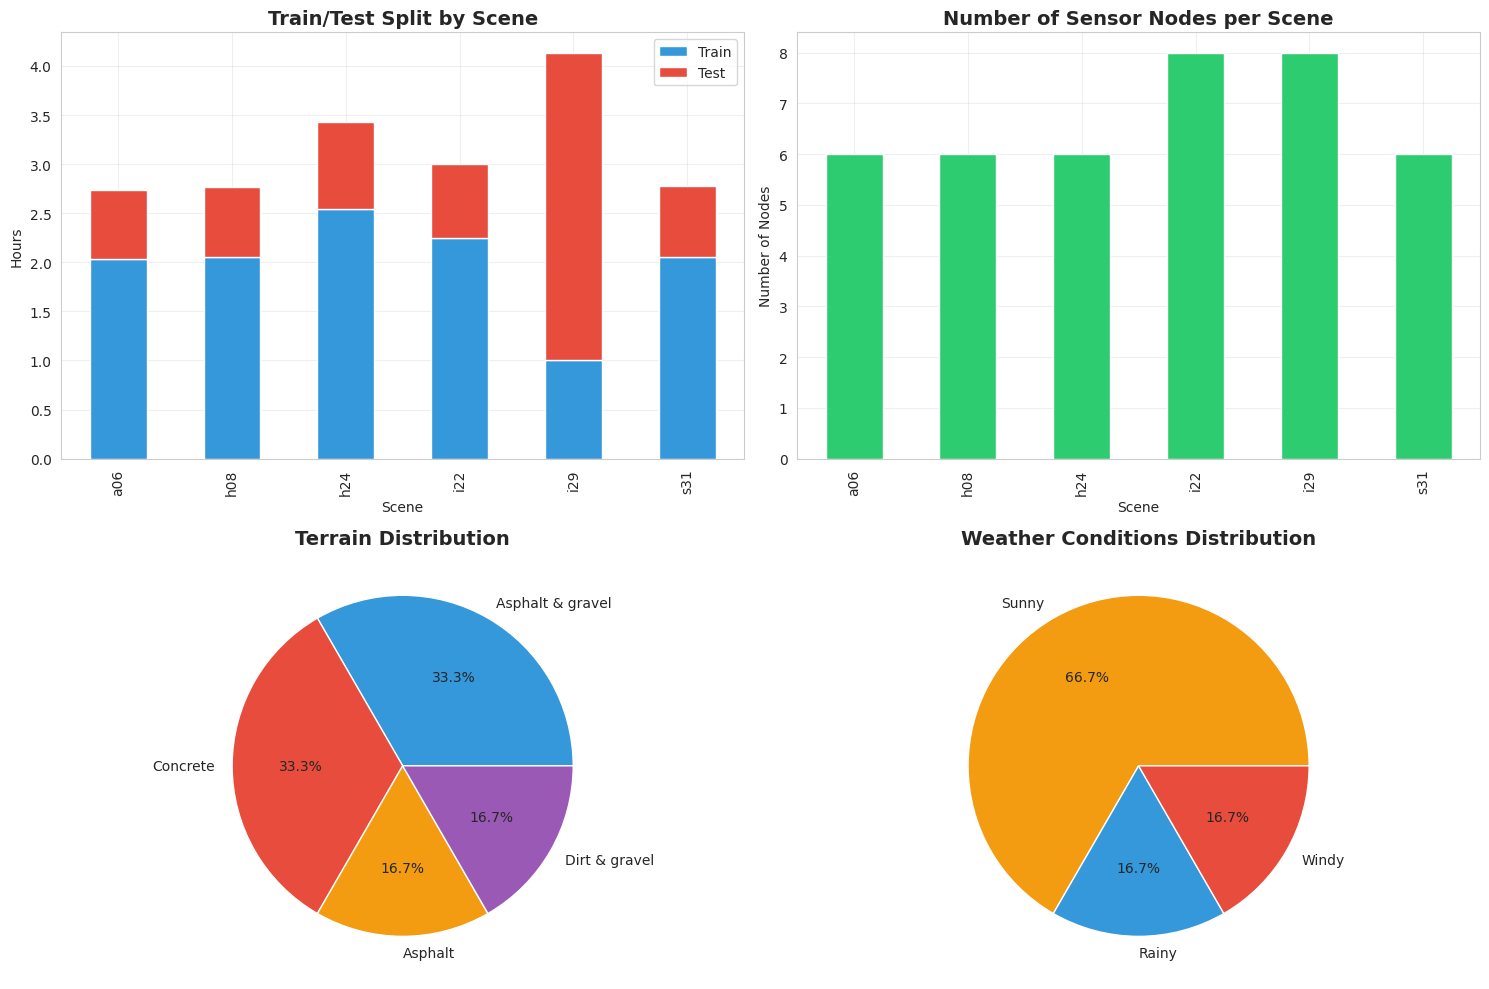

In [164]:
# Visualize dataset summary
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Scene durations
ax1 = axes[0, 0]
summary_df[['scene', 'train_hours', 'test_hours']].set_index('scene').plot(
    kind='bar', stacked=True, ax=ax1, color=['#3498db', '#e74c3c']
)
ax1.set_title('Train/Test Split by Scene', fontsize=14, fontweight='bold')
ax1.set_ylabel('Hours')
ax1.set_xlabel('Scene')
ax1.legend(['Train', 'Test'])
ax1.grid(alpha=0.3)

# Number of nodes per scene
ax2 = axes[0, 1]
summary_df.plot(x='scene', y='nodes', kind='bar', ax=ax2, color='#2ecc71', legend=False)
ax2.set_title('Number of Sensor Nodes per Scene', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Nodes')
ax2.set_xlabel('Scene')
ax2.grid(alpha=0.3)

# Terrain distribution
ax3 = axes[1, 0]
terrain_counts = summary_df['terrain'].value_counts()
ax3.pie(terrain_counts.values, labels=terrain_counts.index, autopct='%1.1f%%', 
        colors=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
ax3.set_title('Terrain Distribution', fontsize=14, fontweight='bold')

# Weather distribution
ax4 = axes[1, 1]
weather_counts = summary_df['weather'].value_counts()
ax4.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%',
        colors=['#f39c12', '#3498db', '#e74c3c'])
ax4.set_title('Weather Conditions Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [165]:
# Load scene-level summary
summary_df = pd.read_csv(DATA_ROOT / 'm3n_dataset_summary.csv')

print("="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"\nTotal Scenes: {len(summary_df)}")
print(f"Total Duration: {summary_df['total_hours'].sum():.2f} hours")
print(f"  • Training: {summary_df['train_hours'].sum():.2f} hours ({summary_df['train_hours'].sum()/summary_df['total_hours'].sum()*100:.1f}%)")
print(f"  • Testing: {summary_df['test_hours'].sum():.2f} hours ({summary_df['test_hours'].sum()/summary_df['total_hours'].sum()*100:.1f}%)")
print(f"\nTotal Sensor Nodes: {summary_df['nodes'].sum()}")
print(f"Total Runs: {summary_df['runs'].sum()}")

print("\n" + "="*80)
print("SCENE BREAKDOWN")
print("="*80)
for idx, row in summary_df.iterrows():
    print(f"\n{row['scene'].upper()}:")
    print(f"  Duration: {row['total_hours']:.2f}h | Nodes: {row['nodes']} | Runs: {row['runs']} | Classes: {row['classes']}")
    print(f"  Terrain: {row['terrain']} | Weather: {row['weather']}")

display(summary_df)

DATASET SUMMARY

Total Scenes: 6
Total Duration: 18.85 hours
  • Training: 11.93 hours (63.3%)
  • Testing: 6.92 hours (36.7%)

Total Sensor Nodes: 40
Total Runs: 48

SCENE BREAKDOWN

A06:
  Duration: 2.74h | Nodes: 6 | Runs: 8 | Classes: 4
  Terrain: Asphalt | Weather: Sunny

H08:
  Duration: 2.77h | Nodes: 6 | Runs: 8 | Classes: 4
  Terrain: Asphalt & gravel | Weather: Sunny

H24:
  Duration: 3.43h | Nodes: 6 | Runs: 10 | Classes: 5
  Terrain: Asphalt & gravel | Weather: Rainy

I22:
  Duration: 3.00h | Nodes: 8 | Runs: 6 | Classes: 3
  Terrain: Concrete | Weather: Sunny

I29:
  Duration: 4.14h | Nodes: 8 | Runs: 8 | Classes: 4
  Terrain: Concrete | Weather: Windy

S31:
  Duration: 2.78h | Nodes: 6 | Runs: 8 | Classes: 4
  Terrain: Dirt & gravel | Weather: Sunny


,scene,runs,nodes,classes,total_hours,train_hours,test_hours,terrain,weather
0,a06,8,6,4,2.740000,2.031944,0.708056,Asphalt,Sunny
1,h08,8,6,4,2.770000,2.049444,0.720556,Asphalt & gravel,Sunny
2,h24,10,6,5,3.425833,2.542500,0.883333,Asphalt & gravel,Rainy
3,i22,6,8,3,3.000000,2.250000,0.750000,Concrete,Sunny
4,i29,8,8,4,4.135556,1.000000,3.135556,Concrete,Windy
5,s31,8,6,4,2.780000,2.053611,0.726389,Dirt & gravel,Sunny


## 3. Complete Metadata Analysis - All Runs Across All Scenes

In [166]:
# Load metadata from ALL scenes
print("Loading run metadata from all scenes...")
print("="*80)

all_runs = []
for scene in SCENES:
    try:
        run_path = DATA_ROOT / scene / 'run_ids.parquet'
        if POLARS_AVAILABLE:
            runs = pl.read_parquet(run_path).to_pandas()
        else:
            runs = pd.read_parquet(run_path)
        
        # Handle array-like columns
        for col in runs.columns:
            if runs[col].dtype == object:
                first_val = runs[col].dropna().iloc[0] if len(runs[col].dropna()) > 0 else None
                if first_val is not None and isinstance(first_val, (list, np.ndarray)):
                    runs[col] = runs[col].apply(lambda x: x[0] if isinstance(x, (list, np.ndarray)) and len(x) > 0 else x)
        
        runs['scene'] = scene
        all_runs.append(runs)
        print(f"✓ {scene}: {len(runs)} runs loaded")
    except Exception as e:
        print(f"✗ {scene}: Error - {e}")

# Combine all scenes
all_runs_df = pd.concat(all_runs, ignore_index=True)

# Calculate durations
if 'length' in all_runs_df.columns:
    all_runs_df['duration_minutes'] = pd.to_timedelta(all_runs_df['length']).dt.total_seconds() / 60
    all_runs_df['duration_seconds'] = pd.to_timedelta(all_runs_df['length']).dt.total_seconds()

print("\n" + "="*80)
print("COMPLETE DATASET STATISTICS")
print("="*80)
print(f"\nTotal Runs: {len(all_runs_df)}")
print(f"Total Vehicles: {all_runs_df['label'].nunique()}")
print(f"Total Scenes: {all_runs_df['scene'].nunique()}")
print(f"\nTrain/Test Split:")
print(f"  • Training: {(all_runs_df['set'] == 'train').sum()} runs ({(all_runs_df['set'] == 'train').sum()/len(all_runs_df)*100:.1f}%)")
print(f"  • Testing: {(all_runs_df['set'] == 'test').sum()} runs ({(all_runs_df['set'] == 'test').sum()/len(all_runs_df)*100:.1f}%)")

if 'duration_minutes' in all_runs_df.columns:
    print(f"\nTotal Duration: {all_runs_df['duration_minutes'].sum():.2f} minutes ({all_runs_df['duration_minutes'].sum()/60:.2f} hours)")
    print(f"Duration Range: {all_runs_df['duration_minutes'].min():.2f} - {all_runs_df['duration_minutes'].max():.2f} minutes")
    print(f"Average Run: {all_runs_df['duration_minutes'].mean():.2f} ± {all_runs_df['duration_minutes'].std():.2f} minutes")

print("\n" + "="*80)
print("VEHICLE DISTRIBUTION")
print("="*80)
vehicle_counts = all_runs_df['label'].value_counts()
for vehicle, count in vehicle_counts.items():
    vehicle_name = VEHICLE_LABELS.get(vehicle, vehicle)
    pct = count/len(all_runs_df)*100
    print(f"{vehicle_name:<25} {count:>3} runs ({pct:>5.1f}%)")

Loading run metadata from all scenes...
✓ a06: 8 runs loaded
✓ h08: 8 runs loaded
✓ h24: 10 runs loaded
✓ i22: 6 runs loaded
✓ i29: 8 runs loaded
✓ s31: 8 runs loaded

COMPLETE DATASET STATISTICS

Total Runs: 48
Total Vehicles: 5
Total Scenes: 6

Train/Test Split:
  • Training: 24 runs (50.0%)
  • Testing: 24 runs (50.0%)

Total Duration: 1131.08 minutes (18.85 hours)
Duration Range: 10.00 - 50.18 minutes
Average Run: 23.56 ± 12.86 minutes

VEHICLE DISTRIBUTION
Mazda CX-30                14 runs ( 29.2%)
Mazda MX-5                 12 runs ( 25.0%)
Mercedes GLE 350           10 runs ( 20.8%)
Ford Mustang               10 runs ( 20.8%)
Background                  2 runs (  4.2%)


### 3.1 Explore Scene Structure

Let's examine a specific scene (s31) to understand the data structure in detail.

In [167]:
# Define scenes to explore
scenes = ['a06', 'h08', 'h24', 'i22', 'i29', 's31']
sample_scene = 's31' 

print(f"Exploring scene: {sample_scene}")
print(f"Available scenes: {scenes}")

Exploring scene: s31
Available scenes: ['a06', 'h08', 'h24', 'i22', 'i29', 's31']


### 3.2 Load Run Metadata

In [168]:
# Load run metadata for sample scene
run_ids_path = DATA_ROOT / sample_scene / 'run_ids.parquet'

if POLARS_AVAILABLE:
    run_ids = pl.read_parquet(run_ids_path)
    print("Using Polars to read parquet file")
    run_ids_df = run_ids.to_pandas()
else:
    run_ids_df = pd.read_parquet(run_ids_path)
    print("Using Pandas to read parquet file")

print(f"\nRun metadata for scene {sample_scene}:")
print(f"Total runs: {len(run_ids_df)}")
print(f"Columns: {list(run_ids_df.columns)}")
print("\n")
run_ids_df

Using Polars to read parquet file

Run metadata for scene s31:
Total runs: 8
Columns: ['run_id', 'label', 'set', 'start_time', 'end_time', 'length']




,run_id,label,set,start_time,end_time,length
0,0,gle350,train,2023-12-31 03:33:20+00:00,2023-12-31 04:04:55+00:00,0 days 00:31:35
1,1,gle350,test,2023-12-31 04:05:19+00:00,2023-12-31 04:17:33+00:00,0 days 00:12:14
2,2,mustang,train,2023-12-31 04:26:17+00:00,2023-12-31 04:56:31+00:00,0 days 00:30:14
3,3,mustang,test,2023-12-31 04:56:51+00:00,2023-12-31 05:07:25+00:00,0 days 00:10:34
4,4,miata,train,2023-12-31 05:18:06+00:00,2023-12-31 05:48:44+00:00,0 days 00:30:38
5,5,miata,test,2023-12-31 05:49:54+00:00,2023-12-31 06:00:23+00:00,0 days 00:10:29
6,6,cx30,train,2023-12-31 06:04:46+00:00,2023-12-31 06:35:32+00:00,0 days 00:30:46
7,7,cx30,test,2023-12-31 06:36:02+00:00,2023-12-31 06:46:20+00:00,0 days 00:10:18


Run Statistics:
Vehicle labels: <ArrowStringArray>
['gle350', 'mustang', 'miata', 'cx30']
Length: 4, dtype: str
Train runs: 4
Test runs: 4


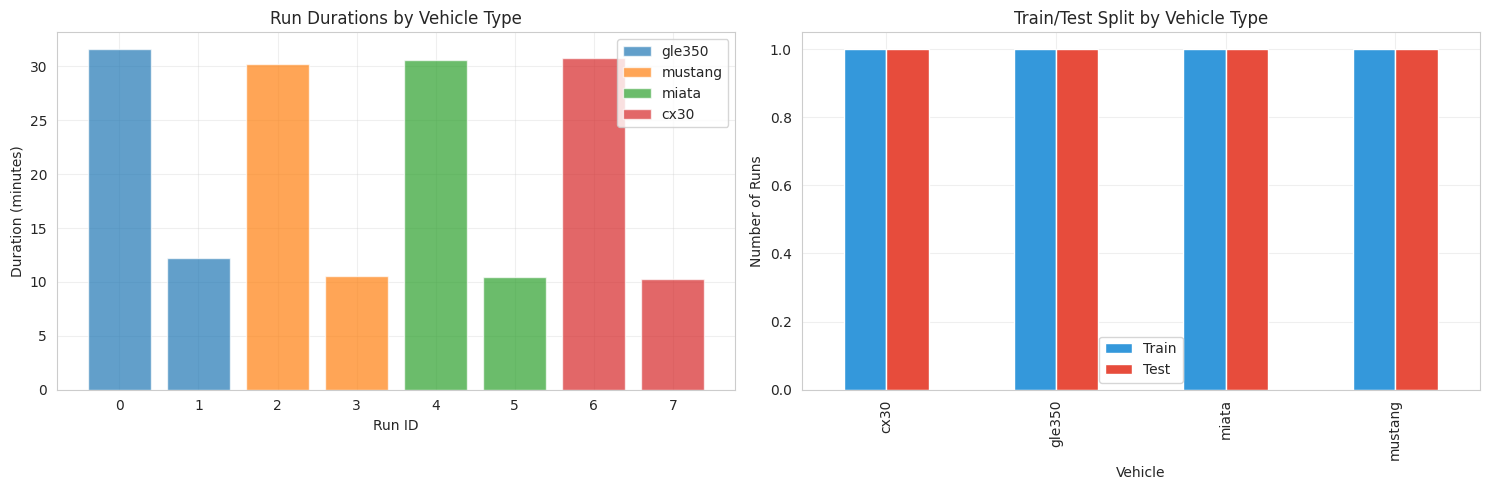

In [169]:
# Analyze run durations and splits
if 'length' in run_ids_df.columns:
    # Convert duration to minutes for easier interpretation
    run_ids_df['duration_minutes'] = pd.to_timedelta(run_ids_df['length']).dt.total_seconds() / 60

print("Run Statistics:")
print(f"Vehicle labels: {run_ids_df['label'].unique()}")
print(f"Train runs: {(run_ids_df['set'] == 'train').sum()}")
print(f"Test runs: {(run_ids_df['set'] == 'test').sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Run durations by vehicle
ax1 = axes[0]
for label in run_ids_df['label'].unique():
    mask = run_ids_df['label'] == label
    ax1.bar(run_ids_df[mask]['run_id'], run_ids_df[mask]['duration_minutes'], 
            label=label, alpha=0.7)
ax1.set_xlabel('Run ID')
ax1.set_ylabel('Duration (minutes)')
ax1.set_title('Run Durations by Vehicle Type')
ax1.legend()
ax1.grid(alpha=0.3)

# Train/Test distribution by vehicle
ax2 = axes[1]
train_test_counts = run_ids_df.groupby(['label', 'set']).size().unstack(fill_value=0)
train_test_counts.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c'])
ax2.set_title('Train/Test Split by Vehicle Type')
ax2.set_ylabel('Number of Runs')
ax2.set_xlabel('Vehicle')
ax2.legend(['Train', 'Test'])
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Sensor Node Locations

In [170]:
# Load sensor locations
sensor_loc_path = DATA_ROOT / sample_scene / 'sensor_location.parquet'

if POLARS_AVAILABLE:
    sensor_loc = pl.read_parquet(sensor_loc_path)
    sensor_loc_df = sensor_loc.to_pandas()
else:
    sensor_loc_df = pd.read_parquet(sensor_loc_path)

print(f"Sensor locations for scene {sample_scene}:")
print(f"Number of sensors: {len(sensor_loc_df)}")
print(f"Columns: {list(sensor_loc_df.columns)}")
print("\n")
sensor_loc_df

Sensor locations for scene s31:
Number of sensors: 6
Columns: ['sensor_id', 'latitude', 'longitude', 'terrain']




,sensor_id,latitude,longitude,terrain
0,rs1,40.077296,-88.218767,dirt_road_with_gravel
1,rs2,40.077263,-88.218768,dirt_road_with_gravel
2,rs5,40.077208,-88.218768,dirt_road_with_gravel
3,rs6,40.077152,-88.218769,dirt_road_with_gravel
4,rs7,40.077115,-88.218762,dirt_road_with_gravel
5,rs8,40.077056,-88.218764,dirt_road_with_gravel


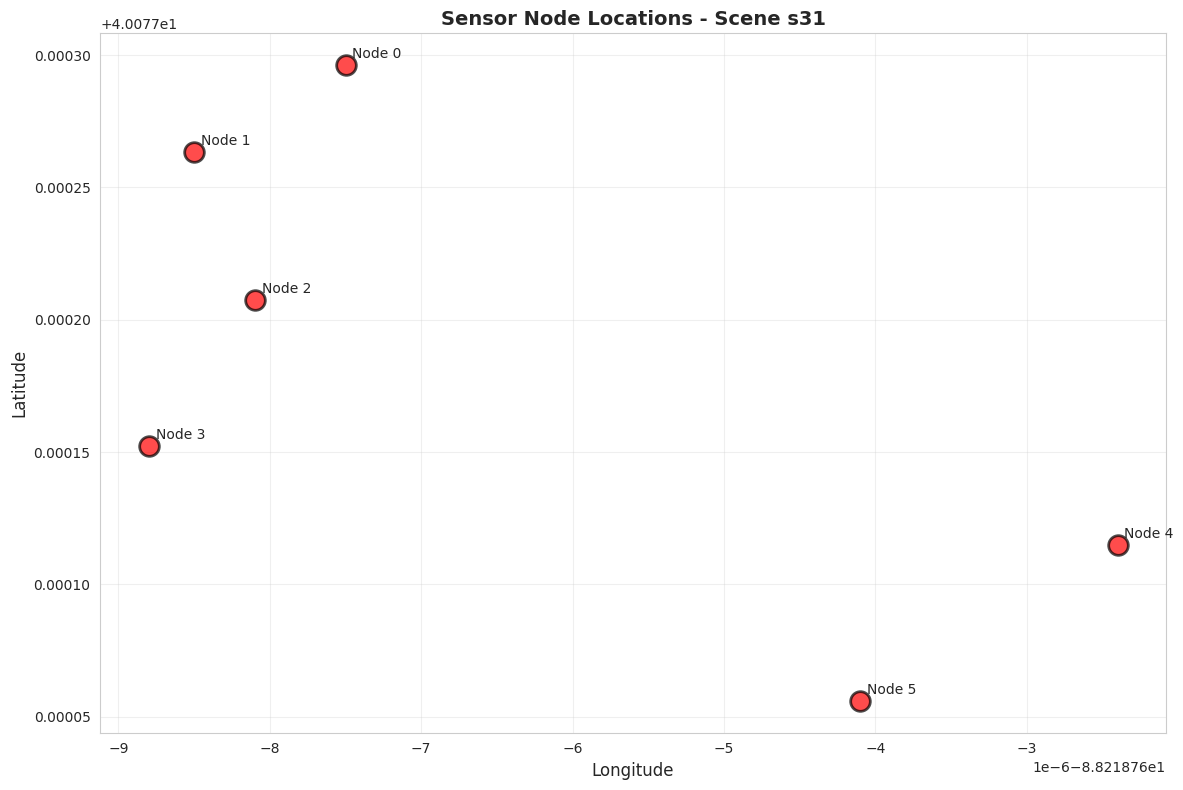

In [171]:
# Visualize sensor node locations (if lat/lon columns exist)
if 'latitude' in sensor_loc_df.columns and 'longitude' in sensor_loc_df.columns:
    plt.figure(figsize=(12, 8))
    plt.scatter(sensor_loc_df['longitude'], sensor_loc_df['latitude'], 
                s=200, c='red', marker='o', edgecolors='black', linewidths=2, alpha=0.7)
    
    # Add node labels
    for idx, row in sensor_loc_df.iterrows():
        plt.annotate(f"Node {row.get('node_id', idx)}", 
                    (row['longitude'], row['latitude']),
                    xytext=(5, 5), textcoords='offset points', fontsize=10)
    
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.title(f'Sensor Node Locations - Scene {sample_scene}', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Latitude/Longitude columns not found in sensor location data")
    print("Available columns:", sensor_loc_df.columns.tolist())

## 4. Vehicle-Level Analysis Across All Scenes

In [172]:
# Detailed vehicle analysis
print("="*80)
print("VEHICLE-LEVEL STATISTICS (All Scenes Combined)")
print("="*80)

for vehicle in sorted(all_runs_df['label'].unique()):
    vehicle_data = all_runs_df[all_runs_df['label'] == vehicle]
    vehicle_name = VEHICLE_LABELS.get(vehicle, vehicle)
    
    print(f"\n{vehicle_name.upper()}:")
    print(f"  Total Runs: {len(vehicle_data)}")
    print(f"  Train: {(vehicle_data['set'] == 'train').sum()} | Test: {(vehicle_data['set'] == 'test').sum()}")
    print(f"  Scenes: {', '.join(sorted(vehicle_data['scene'].unique()))}")
    
    if 'duration_minutes' in vehicle_data.columns:
        print(f"  Duration: {vehicle_data['duration_minutes'].sum():.1f} min total | "
              f"{vehicle_data['duration_minutes'].mean():.1f} ± {vehicle_data['duration_minutes'].std():.1f} min per run")
        print(f"  Range: {vehicle_data['duration_minutes'].min():.1f} - {vehicle_data['duration_minutes'].max():.1f} minutes")

# Train/Test balance by vehicle
print("\n" + "="*80)
print("TRAIN/TEST BALANCE BY VEHICLE")
print("="*80)
train_test_balance = all_runs_df.groupby('label')['set'].value_counts().unstack(fill_value=0)
print(train_test_balance)

# Duration statistics by vehicle
if 'duration_minutes' in all_runs_df.columns:
    print("\n" + "="*80)
    print("DURATION STATISTICS BY VEHICLE (minutes)")
    print("="*80)
    duration_stats = all_runs_df.groupby('label')['duration_minutes'].agg([
        ('count', 'count'),
        ('total', 'sum'),
        ('mean', 'mean'),
        ('std', 'std'),
        ('min', 'min'),
        ('max', 'max')
    ]).round(2)
    print(duration_stats)

VEHICLE-LEVEL STATISTICS (All Scenes Combined)

BACKGROUND:
  Total Runs: 2
  Train: 1 | Test: 1
  Scenes: h24
  Duration: 40.0 min total | 20.0 ± 14.1 min per run
  Range: 10.0 - 30.0 minutes

MAZDA CX-30:
  Total Runs: 14
  Train: 7 | Test: 7
  Scenes: a06, h08, h24, i22, i29, s31
  Duration: 345.1 min total | 24.7 ± 13.9 min per run
  Range: 10.1 - 46.5 minutes

MERCEDES GLE 350:
  Total Runs: 10
  Train: 5 | Test: 5
  Scenes: a06, h08, h24, i29, s31
  Duration: 229.3 min total | 22.9 ± 12.0 min per run
  Range: 10.3 - 44.6 minutes

MAZDA MX-5:
  Total Runs: 12
  Train: 6 | Test: 6
  Scenes: a06, h08, h24, i22, i29, s31
  Duration: 289.5 min total | 24.1 ± 14.1 min per run
  Range: 10.2 - 50.2 minutes

FORD MUSTANG:
  Total Runs: 10
  Train: 5 | Test: 5
  Scenes: a06, h08, h24, i29, s31
  Duration: 227.1 min total | 22.7 ± 12.8 min per run
  Range: 10.2 - 46.8 minutes

TRAIN/TEST BALANCE BY VEHICLE
set         test  train
label                  
background     1      1
cx30         

<Figure size 1200x600 with 0 Axes>

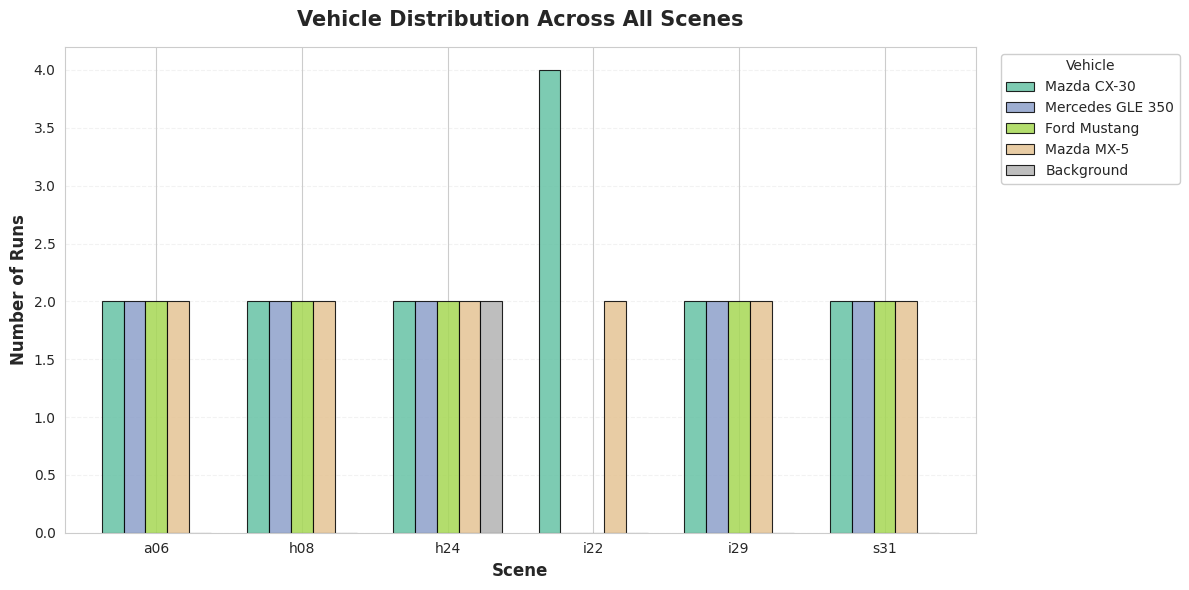

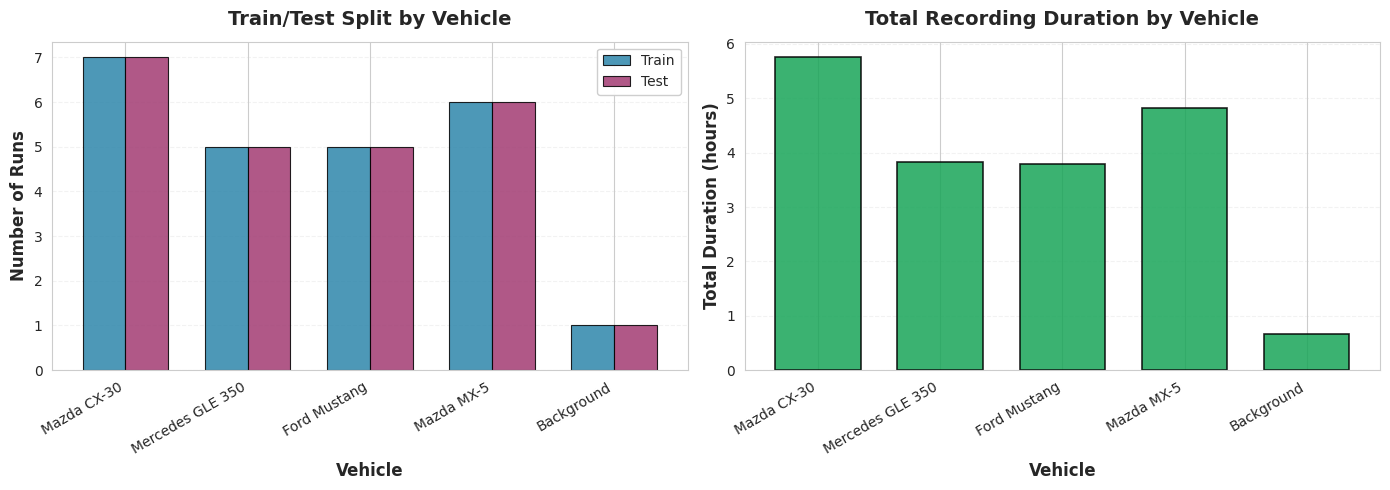

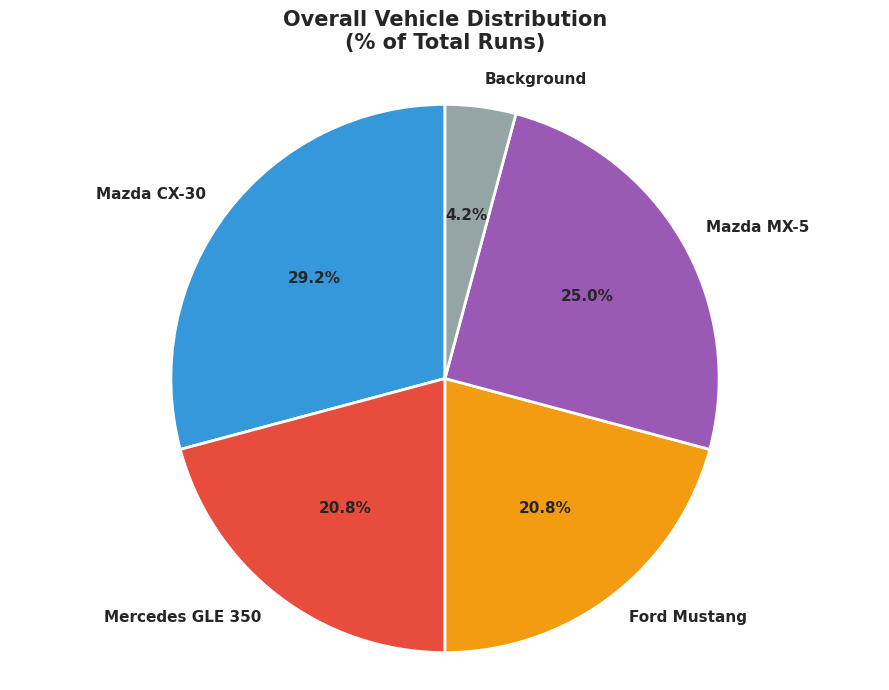

In [173]:
# Vehicle Analysis Visualizations - Simplified and Clear

# Chart 1: Vehicle Distribution Across All Scenes
plt.figure(figsize=(12, 6))
vehicle_scene_counts = pd.crosstab(all_runs_df['scene'], all_runs_df['label'])
vehicle_scene_counts = vehicle_scene_counts[[v for v in ['cx30', 'gle350', 'mustang', 'miata', 'background'] if v in vehicle_scene_counts.columns]]
vehicle_scene_counts.plot(kind='bar', colormap='Set2', width=0.75, edgecolor='black', linewidth=0.8, alpha=0.85)
plt.title('Vehicle Distribution Across All Scenes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Scene', fontsize=12, fontweight='bold')
plt.ylabel('Number of Runs', fontsize=12, fontweight='bold')
plt.legend(title='Vehicle', labels=[VEHICLE_LABELS.get(v, v) for v in vehicle_scene_counts.columns], 
           bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.95)
plt.grid(alpha=0.25, axis='y', linestyle='--')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Chart 2: Train/Test Split by Vehicle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
train_test = all_runs_df.groupby(['label', 'set']).size().unstack(fill_value=0)
train_test = train_test.reindex([v for v in ['cx30', 'gle350', 'mustang', 'miata', 'background'] if v in train_test.index])
train_test.plot(kind='bar', ax=ax1, color=['#2E86AB', '#A23B72'], width=0.7, edgecolor='black', linewidth=0.8, alpha=0.85)
ax1.set_title('Train/Test Split by Vehicle', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Vehicle', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Runs', fontsize=12, fontweight='bold')
ax1.set_xticklabels([VEHICLE_LABELS.get(v, v) for v in train_test.index], rotation=30, ha='right')
ax1.legend(['Train', 'Test'], loc='upper right', framealpha=0.95)
ax1.grid(alpha=0.25, axis='y', linestyle='--')

# Total Duration by Vehicle
if 'duration_minutes' in all_runs_df.columns:
    ax2 = axes[1]
    vehicle_duration = all_runs_df.groupby('label')['duration_minutes'].sum() / 60  # Convert to hours
    vehicle_duration = vehicle_duration.reindex([v for v in ['cx30', 'gle350', 'mustang', 'miata', 'background'] if v in vehicle_duration.index])
    vehicle_duration.plot(kind='bar', ax=ax2, color='#18A558', width=0.7, edgecolor='black', linewidth=1.2, alpha=0.85)
    ax2.set_title('Total Recording Duration by Vehicle', fontsize=14, fontweight='bold', pad=12)
    ax2.set_xlabel('Vehicle', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Total Duration (hours)', fontsize=12, fontweight='bold')
    ax2.set_xticklabels([VEHICLE_LABELS.get(v, v) for v in vehicle_duration.index], rotation=30, ha='right')
    ax2.grid(alpha=0.25, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Chart 3: Overall Vehicle Distribution (Pie Chart)
plt.figure(figsize=(9, 7))
vehicle_total = all_runs_df['label'].value_counts()
vehicle_total = vehicle_total.reindex([v for v in ['cx30', 'gle350', 'mustang', 'miata', 'background'] if v in vehicle_total.index])
colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']
plt.pie(vehicle_total.values, labels=[VEHICLE_LABELS.get(v, v) for v in vehicle_total.index],
        autopct='%1.1f%%', colors=colors, startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Overall Vehicle Distribution\n(% of Total Runs)', fontsize=15, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

## 5. Explore Sensor Time Series Data

Now let's load and visualize actual sensor readings (microphone and geophone data).

### 5.1 Load Microphone Data

In [174]:
# Load a sample microphone recording
sample_run = 0
sample_node = 1
mic_path = DATA_ROOT / sample_scene / f'run{sample_run}_rs{sample_node}_mic.parquet'

try:
    if POLARS_AVAILABLE:
        mic_data = pl.read_parquet(mic_path)
        mic_df = mic_data.to_pandas()
    else:
        mic_df = pd.read_parquet(mic_path)
    
    # Convert timestamp to datetime if it exists
    if 'timestamp' in mic_df.columns:
        mic_df['datetime'] = pd.to_datetime(mic_df['timestamp'], unit='s')
    
    # Get signal column name
    signal_col = 'samples' if 'samples' in mic_df.columns else mic_df.columns[-1]
    
    print(f"📊 Microphone Data - Run {sample_run}, Node {sample_node}")
    print("=" * 70)
    print(f"Total Samples: {len(mic_df):,}")
    print(f"Duration: {len(mic_df) / 1600:.2f} seconds ({len(mic_df) / 1600 / 60:.2f} minutes)")
    print(f"Sampling Rate: 1,600 Hz")
    print(f"\nSignal Statistics:")
    print(f"  Mean: {mic_df[signal_col].mean():.2f}")
    print(f"  Std Dev: {mic_df[signal_col].std():.2f}")
    print(f"  Min: {mic_df[signal_col].min():.2f}")
    print(f"  Max: {mic_df[signal_col].max():.2f}")
    
    if 'datetime' in mic_df.columns:
        print(f"\nRecording Time:")
        print(f"  Start: {mic_df['datetime'].iloc[0]}")
        print(f"  End: {mic_df['datetime'].iloc[-1]}")
    
    print("\n" + "=" * 70)
    print("\nFirst 10 samples:")
    if 'datetime' in mic_df.columns:
        display_df = mic_df[['datetime', signal_col]].head(10)
    else:
        display_df = mic_df.head(10)
    display(display_df)
    
except FileNotFoundError:
    print(f"❌ File not found: {mic_path}")
except Exception as e:
    print(f"❌ Error loading microphone data: {e}")

📊 Microphone Data - Run 0, Node 1
Total Samples: 3,032,000
Duration: 1895.00 seconds (31.58 minutes)
Sampling Rate: 1,600 Hz

Signal Statistics:
  Mean: -0.77
  Std Dev: 2856.89
  Min: -32768.00
  Max: 32767.00

Recording Time:
  Start: 2023-12-31 03:33:20
  End: 2023-12-31 04:04:54.999375105


First 10 samples:


,datetime,samples
0,2023-12-31 03:33:20.000000000,61
1,2023-12-31 03:33:20.000624895,1
2,2023-12-31 03:33:20.001250029,-128
3,2023-12-31 03:33:20.001874924,-72
4,2023-12-31 03:33:20.002500057,-79
5,2023-12-31 03:33:20.003124952,-55
6,2023-12-31 03:33:20.003750086,-168
7,2023-12-31 03:33:20.004374981,-166
8,2023-12-31 03:33:20.005000114,-41
9,2023-12-31 03:33:20.005625010,340


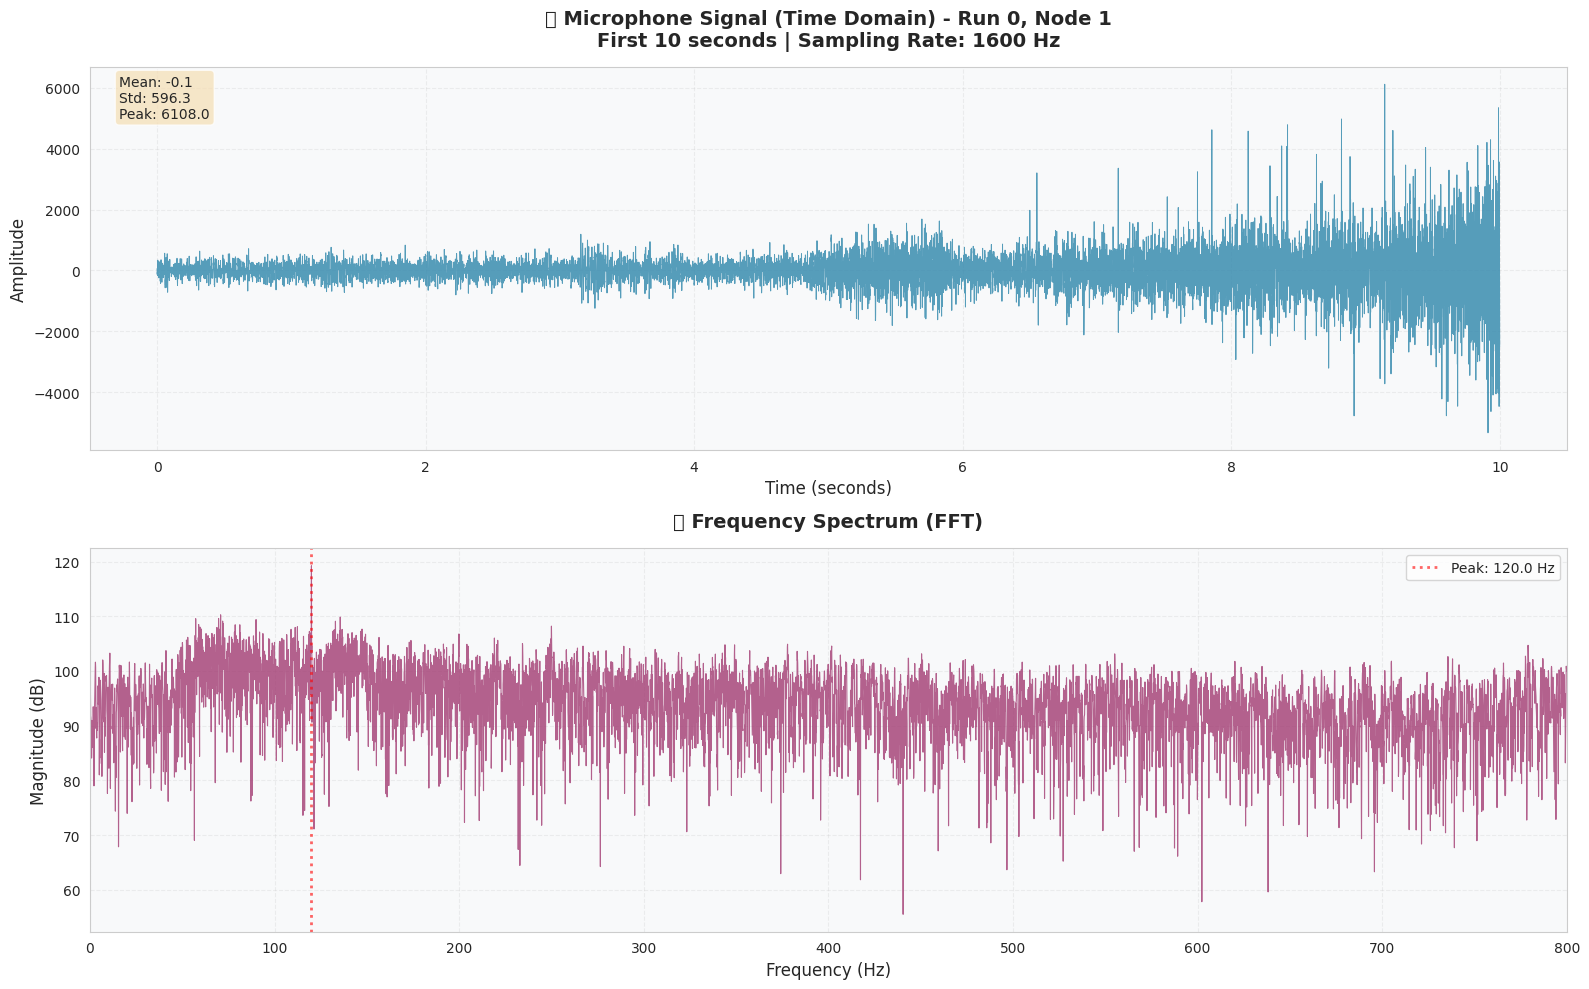

In [175]:
# Visualize microphone signal
if 'mic_df' in locals() and not mic_df.empty:
    # Determine the signal column
    signal_col = 'samples' if 'samples' in mic_df.columns else None
    if signal_col is None:
        for col in ['value', 'signal', 'amplitude', 'data', 'mic']:
            if col in mic_df.columns:
                signal_col = col
                break
    
    if signal_col is None and len(mic_df.columns) > 0:
        # Take the first numeric column
        numeric_cols = mic_df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            signal_col = numeric_cols[0]
    
    if signal_col:
        # Plot first 10 seconds of data
        sampling_rate = 1600  # Hz
        duration_to_plot = 10  # seconds
        samples_to_plot = min(sampling_rate * duration_to_plot, len(mic_df))
        time_axis = np.arange(samples_to_plot) / sampling_rate
        
        fig, axes = plt.subplots(2, 1, figsize=(16, 10))
        
        # Time domain plot
        ax1 = axes[0]
        ax1.plot(time_axis, mic_df[signal_col].iloc[:samples_to_plot], 
                linewidth=0.7, color='#2E86AB', alpha=0.8)
        ax1.set_xlabel('Time (seconds)', fontsize=12)
        ax1.set_ylabel('Amplitude', fontsize=12)
        ax1.set_title(f'🎤 Microphone Signal (Time Domain) - Run {sample_run}, Node {sample_node}\nFirst {duration_to_plot} seconds | Sampling Rate: {sampling_rate} Hz', 
                     fontsize=14, fontweight='bold', pad=15)
        ax1.grid(alpha=0.3, linestyle='--')
        ax1.set_facecolor('#f8f9fa')
        
        # Add statistics box
        signal_data = mic_df[signal_col].iloc[:samples_to_plot]
        stats_text = f'Mean: {signal_data.mean():.1f}\nStd: {signal_data.std():.1f}\nPeak: {signal_data.abs().max():.1f}'
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
        
        # Frequency domain plot (FFT)
        ax2 = axes[1]
        signal_segment = mic_df[signal_col].iloc[:samples_to_plot].values
        fft_vals = np.fft.rfft(signal_segment)
        fft_freq = np.fft.rfftfreq(len(signal_segment), 1/sampling_rate)
        fft_magnitude = np.abs(fft_vals)
        
        # Convert to dB scale for better visualization
        fft_magnitude_db = 20 * np.log10(fft_magnitude + 1e-10)
        
        ax2.plot(fft_freq, fft_magnitude_db, linewidth=0.8, color='#A23B72', alpha=0.8)
        ax2.set_xlabel('Frequency (Hz)', fontsize=12)
        ax2.set_ylabel('Magnitude (dB)', fontsize=12)
        ax2.set_title('🔊 Frequency Spectrum (FFT)', fontsize=14, fontweight='bold', pad=15)
        ax2.set_xlim([0, 800])  # Show up to Nyquist frequency
        ax2.grid(alpha=0.3, linestyle='--')
        ax2.set_facecolor('#f8f9fa')
        
        # Mark dominant frequencies
        peak_idx = np.argmax(fft_magnitude[1:]) + 1  # Skip DC component
        peak_freq = fft_freq[peak_idx]
        ax2.axvline(peak_freq, color='red', linestyle=':', linewidth=2, alpha=0.6, label=f'Peak: {peak_freq:.1f} Hz')
        ax2.legend(loc='upper right')
        
        plt.tight_layout()
        plt.show()
    else:
        print("❌ Could not determine signal column in microphone data")
else:
    print("⚠️  No microphone data loaded")

### 5.2 Load Geophone Data

In [176]:
# Load geophone data from the same run and node
geo_path = DATA_ROOT / sample_scene / f'run{sample_run}_rs{sample_node}_geo.parquet'

try:
    if POLARS_AVAILABLE:
        geo_data = pl.read_parquet(geo_path)
        geo_df = geo_data.to_pandas()
    else:
        geo_df = pd.read_parquet(geo_path)
    
    # Convert timestamp to datetime if it exists
    if 'timestamp' in geo_df.columns:
        geo_df['datetime'] = pd.to_datetime(geo_df['timestamp'], unit='s')
    
    # Get signal column name
    signal_col = 'samples' if 'samples' in geo_df.columns else geo_df.columns[-1]
    
    print(f"📊 Geophone Data - Run {sample_run}, Node {sample_node}")
    print("=" * 70)
    print(f"Total Samples: {len(geo_df):,}")
    print(f"Duration: {len(geo_df) / 200:.2f} seconds ({len(geo_df) / 200 / 60:.2f} minutes)")
    print(f"Sampling Rate: 200 Hz")
    print(f"\nSignal Statistics:")
    print(f"  Mean: {geo_df[signal_col].mean():.2f}")
    print(f"  Std Dev: {geo_df[signal_col].std():.2f}")
    print(f"  Min: {geo_df[signal_col].min():.2f}")
    print(f"  Max: {geo_df[signal_col].max():.2f}")
    
    if 'datetime' in geo_df.columns:
        print(f"\nRecording Time:")
        print(f"  Start: {geo_df['datetime'].iloc[0]}")
        print(f"  End: {geo_df['datetime'].iloc[-1]}")
    
    print("\n" + "=" * 70)
    print("\nFirst 10 samples:")
    if 'datetime' in geo_df.columns:
        display_df = geo_df[['datetime', signal_col]].head(10)
    else:
        display_df = geo_df.head(10)
    display(display_df)
    
except FileNotFoundError:
    print(f"❌ File not found: {geo_path}")
except Exception as e:
    print(f"❌ Error loading geophone data: {e}")

📊 Geophone Data - Run 0, Node 1
Total Samples: 376,400
Duration: 1882.00 seconds (31.37 minutes)
Sampling Rate: 200 Hz

Signal Statistics:
  Mean: 17018.96
  Std Dev: 14688.64
  Min: -223311.00
  Max: 276071.00

Recording Time:
  Start: 2023-12-31 03:33:20
  End: 2023-12-31 04:04:54.994999886


First 10 samples:


,datetime,samples
0,2023-12-31 03:33:20.000000000,17271
1,2023-12-31 03:33:20.005000114,17306
2,2023-12-31 03:33:20.009999990,17286
3,2023-12-31 03:33:20.015000105,17293
4,2023-12-31 03:33:20.019999981,17320
5,2023-12-31 03:33:20.025000095,17287
6,2023-12-31 03:33:20.029999971,17275
7,2023-12-31 03:33:20.035000086,17282
8,2023-12-31 03:33:20.039999962,17234
9,2023-12-31 03:33:20.045000076,17200


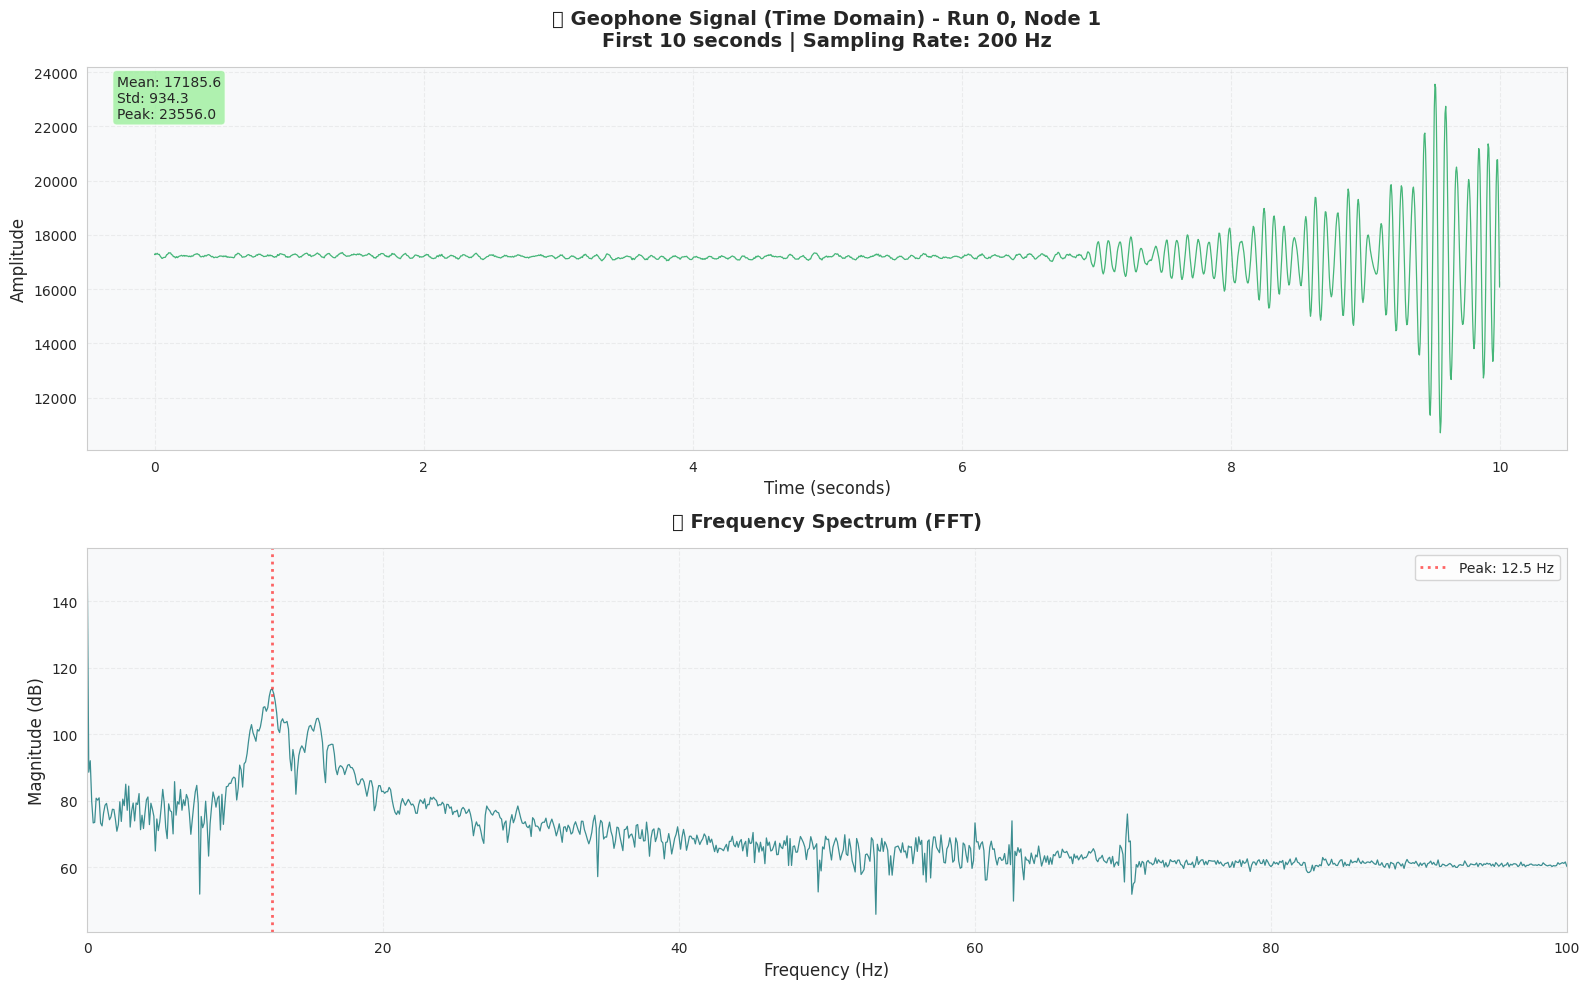

In [177]:
# Visualize geophone signal
if 'geo_df' in locals() and not geo_df.empty:
    # Determine the signal column
    signal_col = 'samples' if 'samples' in geo_df.columns else None
    if signal_col is None:
        for col in ['value', 'signal', 'amplitude', 'data', 'geo', 'x', 'y', 'z']:
            if col in geo_df.columns:
                signal_col = col
                break
    
    if signal_col is None and len(geo_df.columns) > 0:
        numeric_cols = geo_df.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            signal_col = numeric_cols[0]
    
    if signal_col:
        # Plot first 10 seconds of data
        sampling_rate = 200  # Hz
        duration_to_plot = 10  # seconds
        samples_to_plot = min(sampling_rate * duration_to_plot, len(geo_df))
        time_axis = np.arange(samples_to_plot) / sampling_rate
        
        fig, axes = plt.subplots(2, 1, figsize=(16, 10))
        
        # Time domain plot
        ax1 = axes[0]
        ax1.plot(time_axis, geo_df[signal_col].iloc[:samples_to_plot], 
                linewidth=0.9, color='#18A558', alpha=0.8)
        ax1.set_xlabel('Time (seconds)', fontsize=12)
        ax1.set_ylabel('Amplitude', fontsize=12)
        ax1.set_title(f'🌍 Geophone Signal (Time Domain) - Run {sample_run}, Node {sample_node}\nFirst {duration_to_plot} seconds | Sampling Rate: {sampling_rate} Hz', 
                     fontsize=14, fontweight='bold', pad=15)
        ax1.grid(alpha=0.3, linestyle='--')
        ax1.set_facecolor('#f8f9fa')
        
        # Add statistics box
        signal_data = geo_df[signal_col].iloc[:samples_to_plot]
        stats_text = f'Mean: {signal_data.mean():.1f}\nStd: {signal_data.std():.1f}\nPeak: {signal_data.abs().max():.1f}'
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
        
        # Frequency domain plot (FFT)
        ax2 = axes[1]
        signal_segment = geo_df[signal_col].iloc[:samples_to_plot].values
        fft_vals = np.fft.rfft(signal_segment)
        fft_freq = np.fft.rfftfreq(len(signal_segment), 1/sampling_rate)
        fft_magnitude = np.abs(fft_vals)
        
        # Convert to dB scale for better visualization
        fft_magnitude_db = 20 * np.log10(fft_magnitude + 1e-10)
        
        ax2.plot(fft_freq, fft_magnitude_db, linewidth=0.9, color='#0D7377', alpha=0.8)
        ax2.set_xlabel('Frequency (Hz)', fontsize=12)
        ax2.set_ylabel('Magnitude (dB)', fontsize=12)
        ax2.set_title('📈 Frequency Spectrum (FFT)', fontsize=14, fontweight='bold', pad=15)
        ax2.set_xlim([0, 100])  # Show up to Nyquist frequency
        ax2.grid(alpha=0.3, linestyle='--')
        ax2.set_facecolor('#f8f9fa')
        
        # Mark dominant frequencies
        peak_idx = np.argmax(fft_magnitude[1:]) + 1  # Skip DC component
        peak_freq = fft_freq[peak_idx]
        ax2.axvline(peak_freq, color='red', linestyle=':', linewidth=2, alpha=0.6, label=f'Peak: {peak_freq:.1f} Hz')
        ax2.legend(loc='upper right')
        
        plt.tight_layout()
        plt.show()
    else:
        print("❌ Could not determine signal column in geophone data")
else:
    print("⚠️  No geophone data loaded")

### 5.3 Load GPS Trajectory Data

GPS trajectory data for Run 0:
Shape: (1869, 4)
Columns: ['time', 'latitude', 'longitude', 'elevation']


                 time   latitude  longitude  elevation
0 2023-12-31 03:33:20  40.078171 -88.218780      216.1
1 2023-12-31 03:33:21  40.078162 -88.218780      216.1
2 2023-12-31 03:33:22  40.078152 -88.218780      216.1
3 2023-12-31 03:33:23  40.078142 -88.218779      216.1
4 2023-12-31 03:33:24  40.078131 -88.218779      216.1


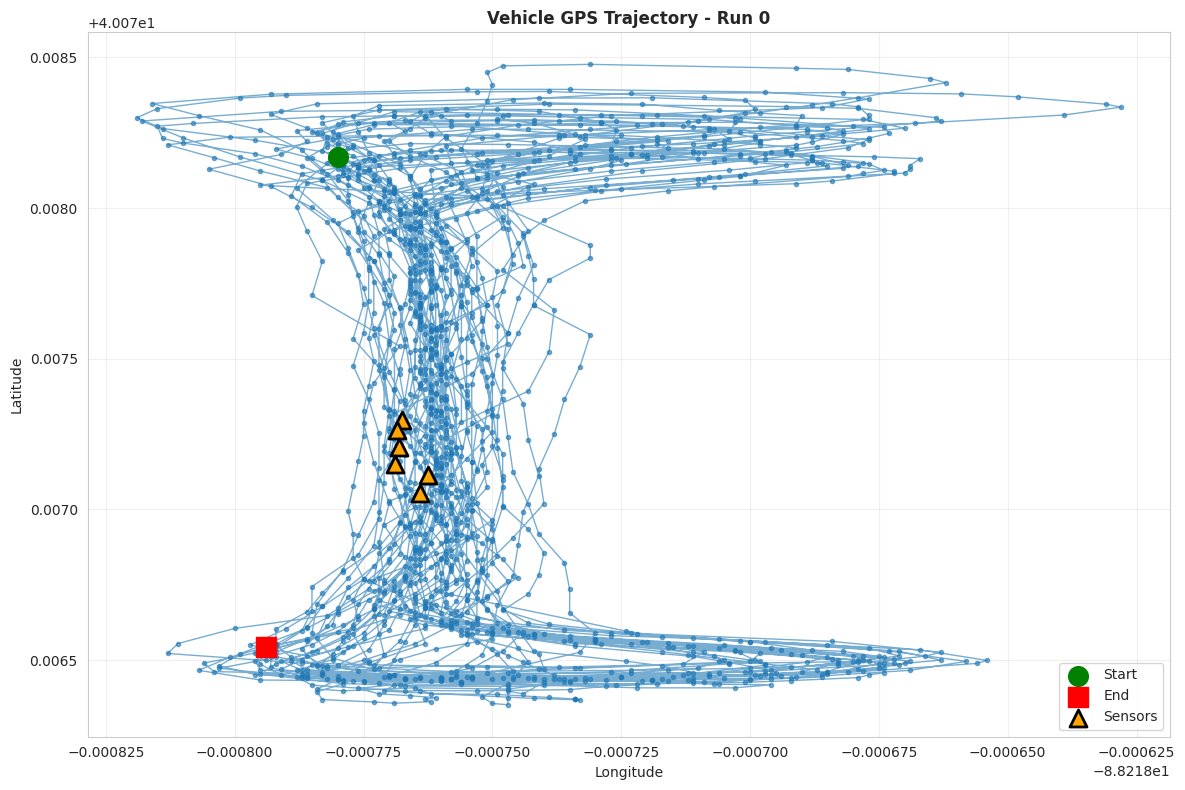

In [178]:
# Load GPS trajectory data
gps_path = DATA_ROOT / sample_scene / f'run{sample_run}_gps.parquet'

try:
    if POLARS_AVAILABLE:
        gps_data = pl.read_parquet(gps_path)
        gps_df = gps_data.to_pandas()
    else:
        gps_df = pd.read_parquet(gps_path)
    
    print(f"GPS trajectory data for Run {sample_run}:")
    print(f"Shape: {gps_df.shape}")
    print(f"Columns: {list(gps_df.columns)}")
    print("\n")
    print(gps_df.head())
    
    # Visualize trajectory if lat/lon columns exist
    if 'latitude' in gps_df.columns and 'longitude' in gps_df.columns:
        plt.figure(figsize=(12, 8))
        plt.plot(gps_df['longitude'], gps_df['latitude'], 
                marker='o', markersize=3, linewidth=1, alpha=0.6)
        plt.scatter(gps_df['longitude'].iloc[0], gps_df['latitude'].iloc[0], 
                   c='green', s=200, marker='o', label='Start', zorder=5)
        plt.scatter(gps_df['longitude'].iloc[-1], gps_df['latitude'].iloc[-1], 
                   c='red', s=200, marker='s', label='End', zorder=5)
        
        # Overlay sensor locations if available
        if 'sensor_loc_df' in locals():
            plt.scatter(sensor_loc_df['longitude'], sensor_loc_df['latitude'], 
                       s=150, c='orange', marker='^', label='Sensors', 
                       edgecolors='black', linewidths=2, zorder=10)
        
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title(f'Vehicle GPS Trajectory - Run {sample_run}', fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    
except FileNotFoundError:
    print(f"File not found: {gps_path}")
except Exception as e:
    print(f"Error loading GPS data: {e}")

## 6. Data Quality and Statistical Analysis

In [179]:
# Check for missing data and compute statistics
if 'all_runs_df' in locals():
    print("=== Data Quality Check ===\n")
    
    # Check for missing values
    print("Missing values in run metadata:")
    print(all_runs_df.isnull().sum())
    print("\n")
    
    # Check for duplicate runs
    duplicates = all_runs_df.duplicated(subset=['scene', 'run_id']).sum()
    print(f"Duplicate runs: {duplicates}\n")
    
    # Summary statistics
    print("=== Summary Statistics ===\n")
    print(f"Total scenes: {all_runs_df['scene'].nunique()}")
    print(f"Total runs: {len(all_runs_df)}")
    print(f"Total vehicles: {all_runs_df['label'].nunique()}")
    print(f"Total train runs: {(all_runs_df['set'] == 'train').sum()}")
    print(f"Total test runs: {(all_runs_df['set'] == 'test').sum()}")
    
    if 'duration_minutes' in all_runs_df.columns:
        print(f"\nTotal recording duration: {all_runs_df['duration_minutes'].sum():.2f} minutes")
        print(f"                         = {all_runs_df['duration_minutes'].sum() / 60:.2f} hours")
        print(f"Average run duration: {all_runs_df['duration_minutes'].mean():.2f} minutes")
        print(f"Shortest run: {all_runs_df['duration_minutes'].min():.2f} minutes")
        print(f"Longest run: {all_runs_df['duration_minutes'].max():.2f} minutes")
    
    # Train/test balance
    print("\n=== Train/Test Balance ===")
    train_test_balance = all_runs_df.groupby('label')['set'].value_counts().unstack(fill_value=0)
    print(train_test_balance)
    
    if 'duration_minutes' in all_runs_df.columns:
        print("\n=== Duration by Vehicle (minutes) ===")
        duration_stats = all_runs_df.groupby('label')['duration_minutes'].agg(['count', 'sum', 'mean', 'std', 'min', 'max'])
        print(duration_stats)

=== Data Quality Check ===

Missing values in run metadata:
run_id              0
label               0
set                 0
start_time          0
end_time            0
length              0
scene               0
duration_minutes    0
duration_seconds    0
dtype: int64


Duplicate runs: 0

=== Summary Statistics ===

Total scenes: 6
Total runs: 48
Total vehicles: 5
Total train runs: 24
Total test runs: 24

Total recording duration: 1131.08 minutes
                         = 18.85 hours
Average run duration: 23.56 minutes
Shortest run: 10.00 minutes
Longest run: 50.18 minutes

=== Train/Test Balance ===
set         test  train
label                  
background     1      1
cx30           7      7
gle350         5      5
miata          6      6
mustang        5      5

=== Duration by Vehicle (minutes) ===
            count         sum       mean        std        min        max
label                                                                    
background      2   40.000000  20.

In [180]:
# Load representative samples from different vehicles
print("Loading representative sensor data samples...")
print("="*80)

signal_characteristics = []

# Sample one run from each vehicle type
for vehicle in ['cx30', 'gle350', 'mustang', 'miata']:
    vehicle_runs = all_runs_df[all_runs_df['label'] == vehicle]
    if len(vehicle_runs) == 0:
        continue
    
    # Get first train run for this vehicle
    sample_run = vehicle_runs[vehicle_runs['set'] == 'train'].iloc[0]
    scene = sample_run['scene']
    run_id = sample_run['run_id']
    
    # Try to load from first available node
    for node in range(1, 9):
        mic_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_mic.parquet'
        geo_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_geo.parquet'
        
        try:
            # Load microphone
            if POLARS_AVAILABLE:
                mic_df = pl.read_parquet(mic_path).to_pandas()
            else:
                mic_df = pd.read_parquet(mic_path)
            
            mic_signal = mic_df['samples'].values if 'samples' in mic_df.columns else mic_df.iloc[:, -1].values
            
            # Load geophone
            if POLARS_AVAILABLE:
                geo_df = pl.read_parquet(geo_path).to_pandas()
            else:
                geo_df = pd.read_parquet(geo_path)
            
            geo_signal = geo_df['samples'].values if 'samples' in geo_df.columns else geo_df.iloc[:, -1].values
            
            # Calculate AC-coupled (DC removed) signals
            mic_ac_signal = mic_signal - np.mean(mic_signal)
            geo_ac_signal = geo_signal - np.mean(geo_signal)
            
            # Calculate statistics
            signal_characteristics.append({
                'vehicle': VEHICLE_LABELS[vehicle],
                'scene': scene,
                'run_id': run_id,
                'node': node,
                'mic_samples': len(mic_signal),
                'mic_mean': np.mean(mic_signal),
                'mic_std': np.std(mic_signal),
                'mic_rms': np.sqrt(np.mean(mic_signal**2)),
                'mic_ac_rms': np.sqrt(np.mean(mic_ac_signal**2)),  # RMS after DC removal
                'mic_peak': np.max(np.abs(mic_signal)),
                'geo_samples': len(geo_signal),
                'geo_mean': np.mean(geo_signal),
                'geo_std': np.std(geo_signal),
                'geo_rms': np.sqrt(np.mean(geo_signal**2)),
                'geo_ac_rms': np.sqrt(np.mean(geo_ac_signal**2)),  # RMS after DC removal
                'geo_peak': np.max(np.abs(geo_signal))
            })
            
            print(f"✓ {VEHICLE_LABELS[vehicle]}: Scene {scene}, Run {run_id}, Node {node}")
            break
        except:
            continue

signal_char_df = pd.DataFrame(signal_characteristics)

print("\n" + "="*80)
print("SIGNAL CHARACTERISTICS SUMMARY")
print("="*80)
print("\nMicrophone Signal Statistics:")
print(signal_char_df[['vehicle', 'mic_samples', 'mic_mean', 'mic_std', 'mic_rms', 'mic_peak']].to_string(index=False))
print("\nGeophone Signal Statistics:")
print(signal_char_df[['vehicle', 'geo_samples', 'geo_mean', 'geo_std', 'geo_rms', 'geo_peak']].to_string(index=False))

Loading representative sensor data samples...


✓ Mazda CX-30: Scene a06, Run 6, Node 1
✓ Mercedes GLE 350: Scene a06, Run 2, Node 1
✓ Ford Mustang: Scene a06, Run 4, Node 1
✓ Mazda MX-5: Scene a06, Run 0, Node 2

SIGNAL CHARACTERISTICS SUMMARY

Microphone Signal Statistics:
         vehicle  mic_samples  mic_mean     mic_std     mic_rms  mic_peak
     Mazda CX-30      2939200 -0.567806  320.227518  320.228021     32768
Mercedes GLE 350      2912000 -0.479626  928.187120  928.187244     32768
    Ford Mustang      2908800 -0.516316 1308.283382 1308.283484     32768
      Mazda MX-5      2944000 -0.503948  502.500294  502.500546     31068

Geophone Signal Statistics:
         vehicle  geo_samples     geo_mean    geo_std      geo_rms  geo_peak
     Mazda CX-30       365600 17010.555388 449.202421 17016.485461     29851
Mercedes GLE 350       362600 17020.115061 742.929240 17036.321802     48140
    Ford Mustang       361400 17023.571787 744.690728 17039.852132     31956
      Mazda MX-5       368000 16280.040845 447.708538 16286.19577

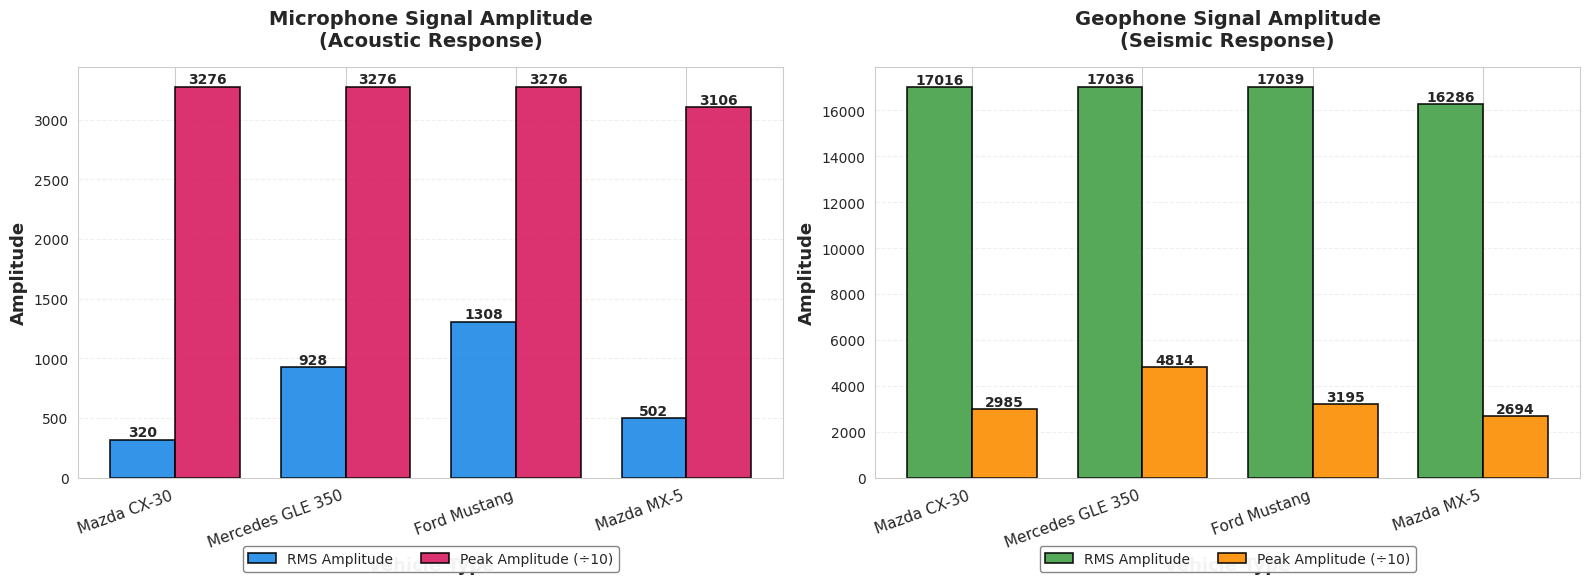

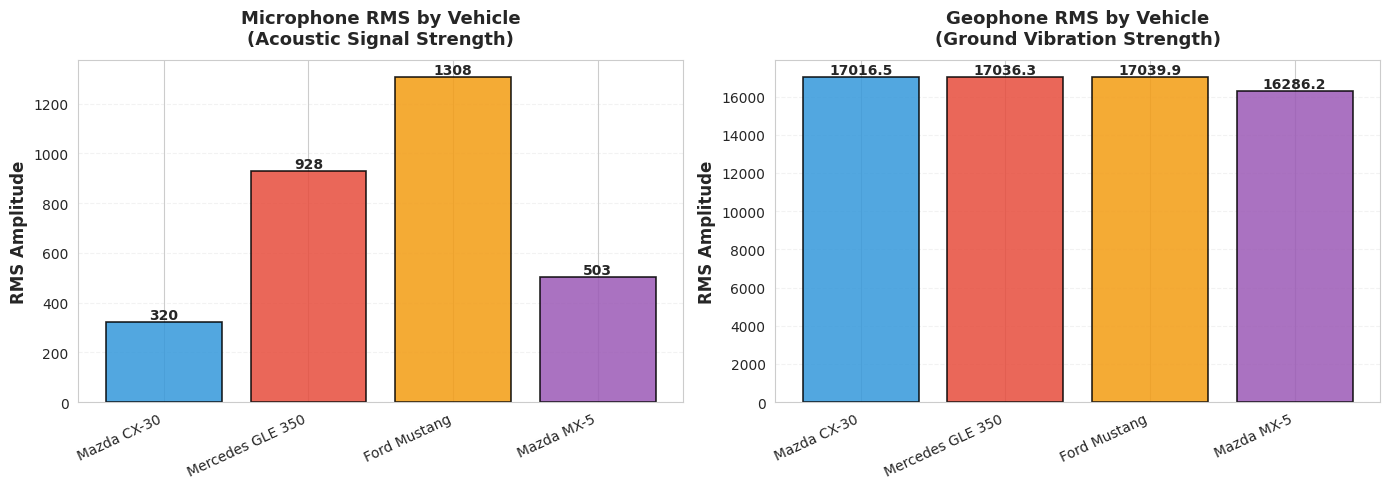

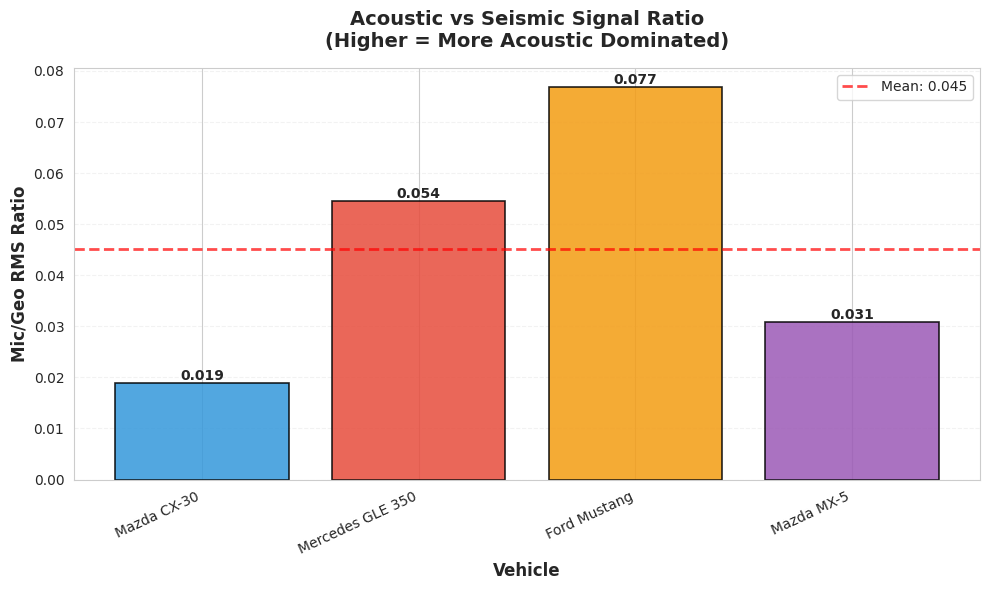


Signal characteristics visualized:
  • Charts 1-2: Show actual amplitude values separately by sensor type
  • Charts 3-4: Direct RMS comparisons show relative signal strength
  • Chart 5: Mic/Geo ratio reveals acoustic vs seismic dominance patterns


In [181]:
# Visualize signal characteristics - Simplified and Clear
if len(signal_char_df) > 0:
    vehicles = signal_char_df['vehicle'].values
    
    # Chart 1: Microphone & Geophone Signal Characteristics - Enhanced
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1 = axes[0]
    x = np.arange(len(vehicles))
    width = 0.38
    
    # Microphone bars with enhanced styling
    bars1_rms = ax1.bar(x - width/2, signal_char_df['mic_rms'], width, label='RMS Amplitude', 
                        color='#1e88e5', alpha=0.9, edgecolor='black', linewidth=1.2)
    bars1_peak = ax1.bar(x + width/2, signal_char_df['mic_peak']/10, width, label='Peak Amplitude (÷10)', 
                         color='#d81b60', alpha=0.9, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for i, (bar_rms, bar_peak) in enumerate(zip(bars1_rms, bars1_peak)):
        height_rms = bar_rms.get_height()
        height_peak = bar_peak.get_height()
        ax1.text(bar_rms.get_x() + bar_rms.get_width()/2., height_rms,
                f'{int(height_rms)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax1.text(bar_peak.get_x() + bar_peak.get_width()/2., height_peak,
                f'{int(height_peak)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax1.set_ylabel('Amplitude', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Vehicle Type', fontsize=13, fontweight='bold')
    ax1.set_title('Microphone Signal Amplitude\n(Acoustic Response)', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xticks(x)
    ax1.set_xticklabels(vehicles, rotation=20, ha='right', fontsize=11)
    ax1.legend(fontsize=10, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, framealpha=0.95, edgecolor='gray')
    ax1.grid(alpha=0.3, axis='y', linestyle='--', linewidth=0.8)
    ax1.set_axisbelow(True)
    
    # Geophone bars with enhanced styling
    ax2 = axes[1]
    bars2_rms = ax2.bar(x - width/2, signal_char_df['geo_rms'], width, label='RMS Amplitude', 
                        color='#43a047', alpha=0.9, edgecolor='black', linewidth=1.2)
    bars2_peak = ax2.bar(x + width/2, signal_char_df['geo_peak']/10, width, label='Peak Amplitude (÷10)', 
                         color='#fb8c00', alpha=0.9, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for i, (bar_rms, bar_peak) in enumerate(zip(bars2_rms, bars2_peak)):
        height_rms = bar_rms.get_height()
        height_peak = bar_peak.get_height()
        ax2.text(bar_rms.get_x() + bar_rms.get_width()/2., height_rms,
                f'{int(height_rms)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax2.text(bar_peak.get_x() + bar_peak.get_width()/2., height_peak,
                f'{int(height_peak)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_ylabel('Amplitude', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Vehicle Type', fontsize=13, fontweight='bold')
    ax2.set_title('Geophone Signal Amplitude\n(Seismic Response)', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xticks(x)
    ax2.set_xticklabels(vehicles, rotation=20, ha='right', fontsize=11)
    ax2.legend(fontsize=10, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, framealpha=0.95, edgecolor='gray')
    ax2.grid(alpha=0.3, axis='y', linestyle='--', linewidth=0.8)
    ax2.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    # Chart 3: Comparative Signal Strength Analysis
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Microphone RMS Comparison
    ax1 = axes[0]
    x = np.arange(len(vehicles))
    colors_veh = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
    ax1.bar(x, signal_char_df['mic_rms'], color=colors_veh, alpha=0.85, edgecolor='black', linewidth=1.2)
    ax1.set_ylabel('RMS Amplitude', fontsize=12, fontweight='bold')
    ax1.set_title('Microphone RMS by Vehicle\n(Acoustic Signal Strength)', fontsize=13, fontweight='bold', pad=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(vehicles, rotation=25, ha='right', fontsize=10)
    ax1.grid(alpha=0.25, axis='y', linestyle='--')
    # Add value labels on bars
    for i, v in enumerate(signal_char_df['mic_rms']):
        ax1.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Right: Geophone RMS Comparison
    ax2 = axes[1]
    ax2.bar(x, signal_char_df['geo_rms'], color=colors_veh, alpha=0.85, edgecolor='black', linewidth=1.2)
    ax2.set_ylabel('RMS Amplitude', fontsize=12, fontweight='bold')
    ax2.set_title('Geophone RMS by Vehicle\n(Ground Vibration Strength)', fontsize=13, fontweight='bold', pad=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(vehicles, rotation=25, ha='right', fontsize=10)
    ax2.grid(alpha=0.25, axis='y', linestyle='--')
    # Add value labels on bars
    for i, v in enumerate(signal_char_df['geo_rms']):
        ax2.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Chart 4: RMS Ratio Analysis (Microphone vs Geophone)
    plt.figure(figsize=(10, 6))
    mic_to_geo_ratio = signal_char_df['mic_rms'] / signal_char_df['geo_rms']
    x = np.arange(len(vehicles))
    plt.bar(x, mic_to_geo_ratio, color=colors_veh, alpha=0.85, edgecolor='black', linewidth=1.2)
    plt.ylabel('Mic/Geo RMS Ratio', fontsize=12, fontweight='bold')
    plt.xlabel('Vehicle', fontsize=12, fontweight='bold')
    plt.title('Acoustic vs Seismic Signal Ratio\n(Higher = More Acoustic Dominated)', fontsize=14, fontweight='bold', pad=15)
    plt.xticks(x, vehicles, rotation=25, ha='right', fontsize=10)
    plt.grid(alpha=0.25, axis='y', linestyle='--')
    plt.axhline(y=mic_to_geo_ratio.mean(), color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {mic_to_geo_ratio.mean():.3f}')
    # Add value labels
    for i, v in enumerate(mic_to_geo_ratio):
        plt.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.legend(fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("Signal characteristics visualized:")
    print("  • Charts 1-2: Show actual amplitude values separately by sensor type")
    print("  • Charts 3-4: Direct RMS comparisons show relative signal strength")
    print("  • Chart 5: Mic/Geo ratio reveals acoustic vs seismic dominance patterns")
    print("="*80)

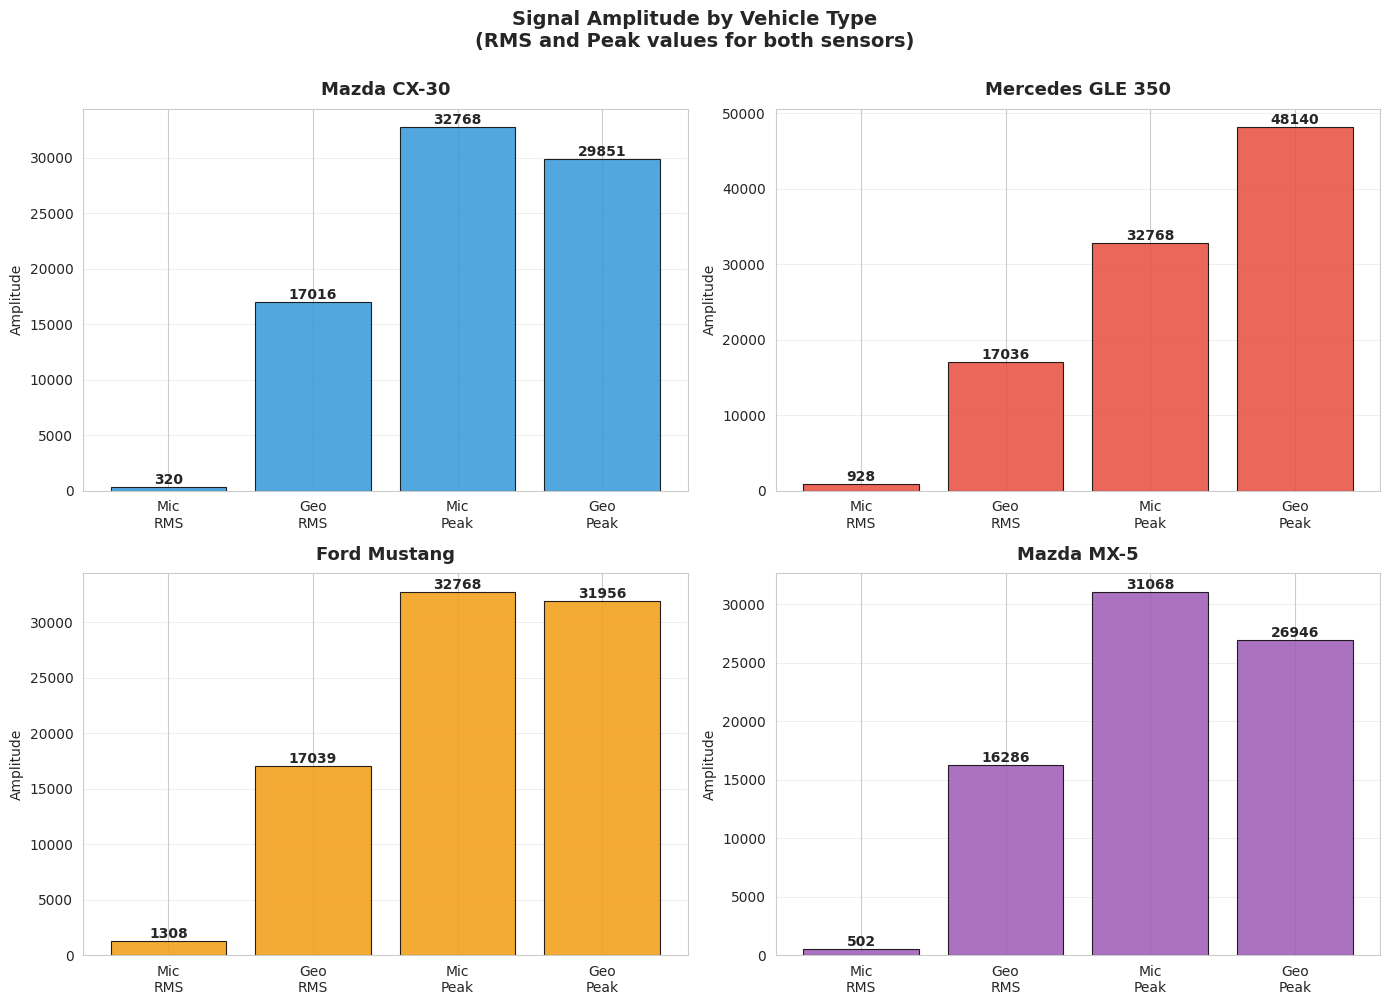

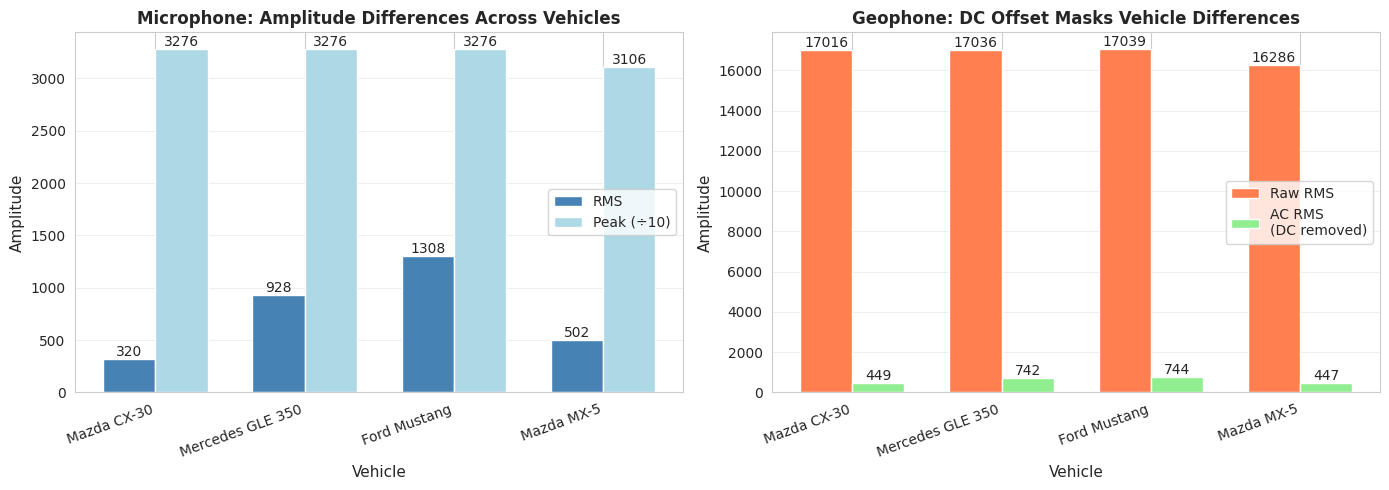


VEHICLE AMPLITUDE ANALYSIS SUMMARY

📊 MICROPHONE AMPLITUDES (RMS):
  Mazda CX-30             320.2
  Mercedes GLE 350        928.2
  Ford Mustang           1308.3
  Mazda MX-5              502.5
  Range:                  988.1  (129.2% of mean)

📊 GEOPHONE AMPLITUDES - Raw (with DC offset):
  Mazda CX-30           17016.5
  Mercedes GLE 350      17036.3
  Ford Mustang          17039.9
  Mazda MX-5            16286.2
  Range:                  753.7  (4.5% of mean) ⚠️  POOR

📊 GEOPHONE AMPLITUDES - AC RMS (DC removed):
  Mazda CX-30             449.2
  Mercedes GLE 350        742.9
  Ford Mustang            744.7
  Mazda MX-5              447.7
  Range:                  297.0  (49.8% of mean) ✅ BETTER

KEY INSIGHTS:
  • Microphone shows 129.2% variation between vehicles
  • Geophone (raw) shows only 4.5% variation (masked by DC)
  • Geophone (DC-removed) shows 49.8% variation
  • DC removal improves geophone discrimination by 0.4x


In [182]:
# Signal Amplitude Analysis by Vehicle
if len(signal_char_df) > 0:
    vehicles = signal_char_df['vehicle'].values
    x = np.arange(len(vehicles))
    
    # Chart 1: Individual Vehicle Amplitude Profiles
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
    
    for idx, (ax, vehicle, color) in enumerate(zip(axes.flat, vehicles, colors)):
        vehicle_data = signal_char_df[signal_char_df['vehicle'] == vehicle].iloc[0]
        
        # Show 4 amplitude metrics for this vehicle
        metrics = ['Mic\nRMS', 'Geo\nRMS', 'Mic\nPeak', 'Geo\nPeak']
        values = [
            vehicle_data['mic_rms'],
            vehicle_data['geo_rms'],
            vehicle_data['mic_peak'],
            vehicle_data['geo_peak']
        ]
        
        bars = ax.bar(range(4), values, color=color, alpha=0.85, edgecolor='black', linewidth=0.8)
        
        # Add value labels
        for i, (bar, val) in enumerate(zip(bars, values)):
            ax.text(bar.get_x() + bar.get_width()/2., val, f'{int(val)}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_title(f'{vehicle}', fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel('Amplitude', fontsize=10)
        ax.set_xticks(range(4))
        ax.set_xticklabels(metrics, fontsize=10)
        ax.grid(alpha=0.3, axis='y')
    
    plt.suptitle('Signal Amplitude by Vehicle Type\n(RMS and Peak values for both sensors)', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Chart 2: Cross-Vehicle Amplitude Comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Microphone comparison
    ax1 = axes[0]
    width = 0.35
    bars1 = ax1.bar(x - width/2, signal_char_df['mic_rms'], width, label='RMS', color='steelblue')
    bars2 = ax1.bar(x + width/2, signal_char_df['mic_peak']/10, width, label='Peak (÷10)', color='lightblue')
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)
    
    ax1.set_ylabel('Amplitude', fontsize=11)
    ax1.set_xlabel('Vehicle', fontsize=11)
    ax1.set_title('Microphone: Amplitude Differences Across Vehicles', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(vehicles, rotation=20, ha='right', fontsize=10)
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')
    
    # Geophone comparison - showing DC offset effect
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, signal_char_df['geo_rms'], width, label='Raw RMS', color='coral')
    bars4 = ax2.bar(x + width/2, signal_char_df['geo_ac_rms'], width, label='AC RMS\n(DC removed)', color='lightgreen')
    
    for bars in [bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)
    
    ax2.set_ylabel('Amplitude', fontsize=11)
    ax2.set_xlabel('Vehicle', fontsize=11)
    ax2.set_title('Geophone: DC Offset Masks Vehicle Differences', fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(vehicles, rotation=20, ha='right', fontsize=10)
    ax2.legend()
    ax2.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Chart 3: Vehicle Discrimination Summary
    print("\n" + "="*80)
    print("VEHICLE AMPLITUDE ANALYSIS SUMMARY")
    print("="*80)
    
    print("\n📊 MICROPHONE AMPLITUDES (RMS):")
    for idx, row in signal_char_df.iterrows():
        print(f"  {row['vehicle']:<20} {row['mic_rms']:>8.1f}")
    mic_range = signal_char_df['mic_rms'].max() - signal_char_df['mic_rms'].min()
    print(f"  {'Range:':<20} {mic_range:>8.1f}  ({mic_range/signal_char_df['mic_rms'].mean()*100:.1f}% of mean)")
    
    print("\n📊 GEOPHONE AMPLITUDES - Raw (with DC offset):")
    for idx, row in signal_char_df.iterrows():
        print(f"  {row['vehicle']:<20} {row['geo_rms']:>8.1f}")
    geo_range = signal_char_df['geo_rms'].max() - signal_char_df['geo_rms'].min()
    print(f"  {'Range:':<20} {geo_range:>8.1f}  ({geo_range/signal_char_df['geo_rms'].mean()*100:.1f}% of mean) ⚠️  POOR")
    
    print("\n📊 GEOPHONE AMPLITUDES - AC RMS (DC removed):")
    for idx, row in signal_char_df.iterrows():
        print(f"  {row['vehicle']:<20} {row['geo_ac_rms']:>8.1f}")
    geo_ac_range = signal_char_df['geo_ac_rms'].max() - signal_char_df['geo_ac_rms'].min()
    print(f"  {'Range:':<20} {geo_ac_range:>8.1f}  ({geo_ac_range/signal_char_df['geo_ac_rms'].mean()*100:.1f}% of mean) ✅ BETTER")
    
    print("\n" + "="*80)
    print("KEY INSIGHTS:")
    print(f"  • Microphone shows {mic_range/signal_char_df['mic_rms'].mean()*100:.1f}% variation between vehicles")
    print(f"  • Geophone (raw) shows only {geo_range/signal_char_df['geo_rms'].mean()*100:.1f}% variation (masked by DC)")
    print(f"  • Geophone (DC-removed) shows {geo_ac_range/signal_char_df['geo_ac_rms'].mean()*100:.1f}% variation")
    print(f"  • DC removal improves geophone discrimination by {(geo_ac_range/geo_range):.1f}x")
    print("="*80)

## 7. Box and Whisker Plot Analysis

Box and whisker plots show the statistical distribution of signal amplitudes across different vehicles, including:
- **Median** (center line)
- **Quartiles** (box edges, 25th and 75th percentiles)
- **Range** (whiskers, min/max excluding outliers)
- **Outliers** (individual points beyond whiskers)

These visualizations help identify:
- Central tendency and variability of each vehicle's signature
- Outliers and anomalous measurements
- Overlap or separation between vehicle classes

In [183]:
# Collect amplitude data from multiple runs for comprehensive box plots
print("Collecting amplitude statistics from multiple runs...")
print("="*80)

# Create list to store amplitude statistics
amplitude_stats = []

# Vehicle types and labels
vehicle_labels = {
    'cx30': 'Mazda CX-30',
    'gle350': 'Mercedes GLE 350',
    'mustang': 'Ford Mustang',
    'miata': 'Mazda MX-5'
}

target_vehicles = list(vehicle_labels.keys())
runs_per_vehicle = 5

for vehicle in target_vehicles:
    print(f"\n📊 Processing {vehicle_labels[vehicle]}...")
    
    # Collect from multiple scenes
    count = 0
    for scene in scenes:
        if count >= runs_per_vehicle:
            break
            
        try:
            run_path = DATA_ROOT / scene / 'run_ids.parquet'
            if POLARS_AVAILABLE:
                runs = pl.read_parquet(run_path).to_pandas()
            else:
                runs = pd.read_parquet(run_path)
            
            vehicle_runs = runs[runs['label'] == vehicle]
            
            for idx, run_row in vehicle_runs.iterrows():
                if count >= runs_per_vehicle:
                    break
                    
                run_id = run_row['run_id']
                
                # Try to load data from nodes
                for node in range(1, 9):
                    try:
                        mic_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_mic.parquet'
                        geo_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_geo.parquet'
                        
                        # Load microphone data
                        if POLARS_AVAILABLE:
                            mic_df = pl.read_parquet(mic_path).to_pandas()
                        else:
                            mic_df = pd.read_parquet(mic_path)
                        
                        mic_signal = mic_df['samples'].values if 'samples' in mic_df.columns else mic_df.iloc[:, -1].values
                        
                        # Load geophone data
                        if POLARS_AVAILABLE:
                            geo_df = pl.read_parquet(geo_path).to_pandas()
                        else:
                            geo_df = pd.read_parquet(geo_path)
                        
                        geo_signal = geo_df['samples'].values if 'samples' in geo_df.columns else geo_df.iloc[:, -1].values
                        
                        # Calculate statistics
                        amplitude_stats.append({
                            'vehicle': vehicle,
                            'vehicle_name': vehicle_labels[vehicle],
                            'scene': scene,
                            'run_id': run_id,
                            'node': node,
                            'mic_rms': np.sqrt(np.nanmean(mic_signal**2)),
                            'mic_peak': np.nanmax(np.abs(mic_signal)),
                            'geo_rms': np.sqrt(np.nanmean(geo_signal**2)),
                            'geo_peak': np.nanmax(np.abs(geo_signal))
                        })
                        
                        print(f"  ✓ Run {run_id}, Scene {scene}, Node {node}")
                        count += 1
                        break
                    except:
                        continue
        except:
            continue

# Convert to DataFrame
amplitude_df = pd.DataFrame(amplitude_stats)

print(f"\n{'='*80}")
print(f"✅ Collected {len(amplitude_df)} samples across {amplitude_df['vehicle'].nunique()} vehicles")
print(f"{'='*80}")
print("\nSamples per vehicle:")
print(amplitude_df['vehicle_name'].value_counts())


📊 Processing Mazda CX-30...


  ✓ Run 6, Scene a06, Node 1
  ✓ Run 7, Scene a06, Node 1
  ✓ Run 6, Scene h08, Node 1
  ✓ Run 7, Scene h08, Node 1
  ✓ Run 2, Scene h24, Node 1

📊 Processing Mercedes GLE 350...
  ✓ Run 2, Scene a06, Node 1
  ✓ Run 3, Scene a06, Node 1
  ✓ Run 0, Scene h08, Node 1
  ✓ Run 1, Scene h08, Node 1
  ✓ Run 0, Scene h24, Node 1

📊 Processing Ford Mustang...
  ✓ Run 4, Scene a06, Node 1
  ✓ Run 5, Scene a06, Node 1
  ✓ Run 2, Scene h08, Node 1
  ✓ Run 3, Scene h08, Node 1
  ✓ Run 4, Scene h24, Node 1

📊 Processing Mazda MX-5...
  ✓ Run 0, Scene a06, Node 2
  ✓ Run 1, Scene a06, Node 2
  ✓ Run 4, Scene h08, Node 1
  ✓ Run 5, Scene h08, Node 1
  ✓ Run 6, Scene h24, Node 1

✅ Collected 20 samples across 4 vehicles

Samples per vehicle:
vehicle_name
Mazda CX-30         5
Mercedes GLE 350    5
Ford Mustang        5
Mazda MX-5          5
Name: count, dtype: int64


## Outlier Detection Analysis

Box-and-Whisker plots using the IQR (Interquartile Range) method to identify potential outliers in the M3N dataset.

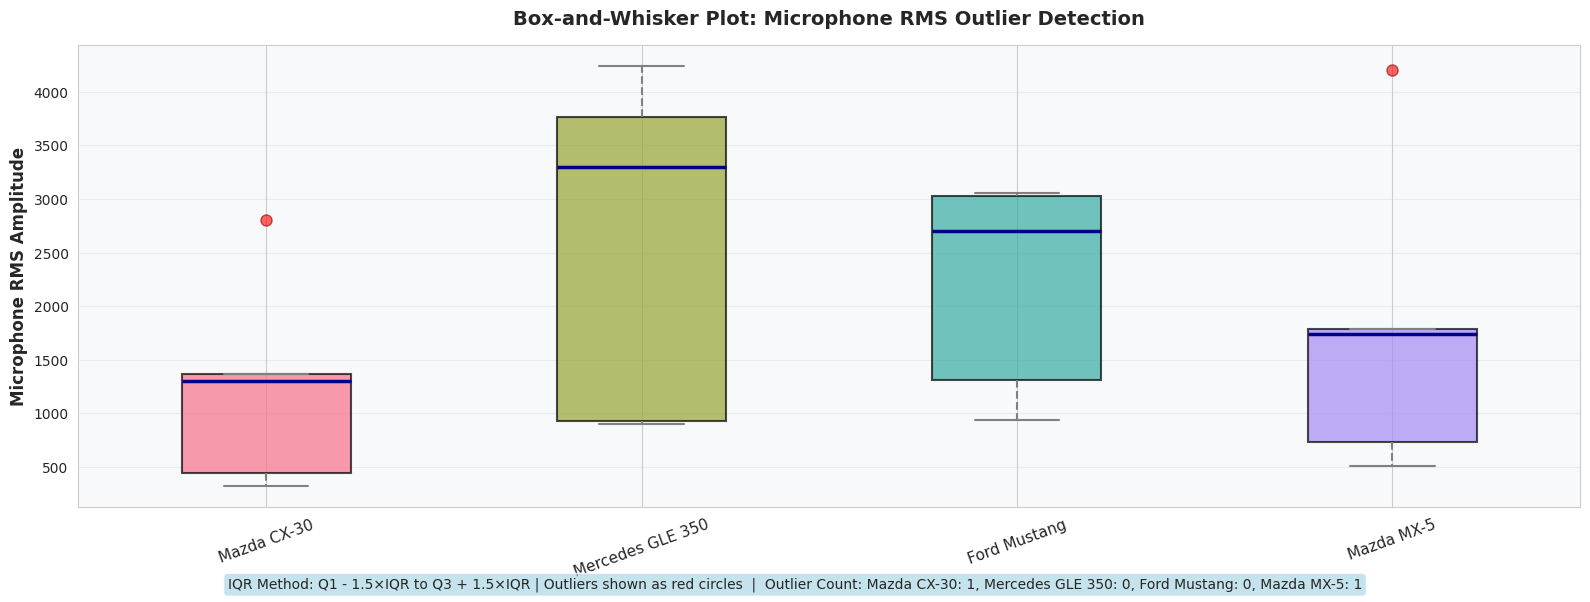

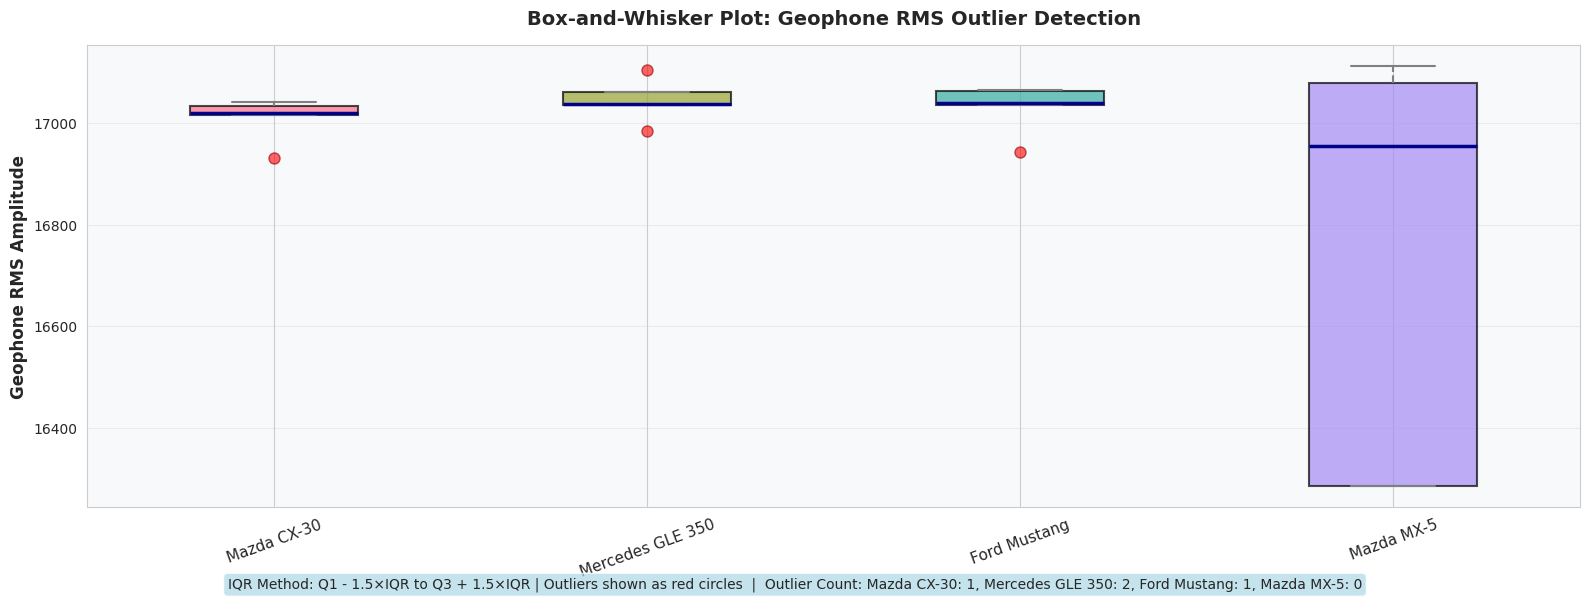


OUTLIER DETECTION SUMMARY (IQR Method: 1.5 × IQR)

MICROPHONE RMS OUTLIERS:
--------------------------------------------------------------------------------

Mazda CX-30:
  Q1: 439.36, Q3: 1369.51, IQR: 930.15
  Outlier Bounds: [-955.85, 2764.73]
  Outlier Count: 1 out of 5 samples
  Outlier Values: 2803.51

Mercedes GLE 350:
  Q1: 928.19, Q3: 3761.63, IQR: 2833.45
  Outlier Bounds: [-3321.98, 8011.80]
  Outlier Count: 0 out of 5 samples

Ford Mustang:
  Q1: 1308.28, Q3: 3028.21, IQR: 1719.93
  Outlier Bounds: [-1271.61, 5608.10]
  Outlier Count: 0 out of 5 samples

Mazda MX-5:
  Q1: 730.18, Q3: 1784.84, IQR: 1054.66
  Outlier Bounds: [-851.80, 3366.83]
  Outlier Count: 1 out of 5 samples
  Outlier Values: 4203.38

GEOPHONE RMS OUTLIERS:
--------------------------------------------------------------------------------

Mazda CX-30:
  Q1: 17016.49, Q3: 17033.13, IQR: 16.64
  Outlier Bounds: [16991.52, 17058.09]
  Outlier Count: 1 out of 5 samples
  Outlier Values: 16931.96

Mercedes GLE

In [184]:
# Outlier Detection: Box-and-Whisker Plot for M3N Data
if len(amplitude_df) > 0:
    # Prepare data for both microphone and geophone RMS
    vehicles = list(vehicle_labels.values())
    
    # Microphone RMS data grouped by vehicle
    mic_box_data = [amplitude_df[amplitude_df['vehicle_name'] == v]['mic_rms'].values 
                    for v in vehicles]
    
    # Geophone RMS data grouped by vehicle  
    geo_box_data = [amplitude_df[amplitude_df['vehicle_name'] == v]['geo_rms'].values 
                    for v in vehicles]
    
    colors_box = sns.color_palette("husl", len(vehicles))
    
    # ============================================================================
    # Plot 1: Microphone RMS - Outlier Detection
    # ============================================================================
    fig1, ax1 = plt.subplots(figsize=(16, 6))
    
    bp1 = ax1.boxplot(mic_box_data, labels=vehicles, patch_artist=True, 
                      showfliers=True, whis=1.5)
    
    for patch, color in zip(bp1['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style whiskers and outliers
    for whisker in bp1['whiskers']:
        whisker.set(linewidth=1.5, linestyle='--', color='gray')
    for cap in bp1['caps']:
        cap.set(linewidth=1.5, color='gray')
    for median in bp1['medians']:
        median.set(linewidth=2.5, color='darkblue')
    for flier in bp1['fliers']:
        flier.set(marker='o', markersize=8, markerfacecolor='red', 
                 markeredgecolor='darkred', alpha=0.6)
    
    ax1.set_ylabel('Microphone RMS Amplitude', fontsize=12, fontweight='bold')
    ax1.set_title('Box-and-Whisker Plot: Microphone RMS Outlier Detection', 
                  fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', rotation=20, labelsize=11)
    ax1.set_facecolor('#f8f9fa')
    
    # Count and display outliers for microphone
    mic_outlier_counts = []
    for i, vehicle in enumerate(vehicles):
        data = mic_box_data[i]
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        mic_outlier_counts.append(len(outliers))
    
    # Add outlier statistics text below the plot using figtext
    textstr = 'IQR Method: Q1 - 1.5×IQR to Q3 + 1.5×IQR | Outliers shown as red circles'
    outlier_text = f'Outlier Count: {", ".join([f"{v}: {c}" for v, c in zip(vehicles, mic_outlier_counts)])}'
    
    plt.tight_layout()
    fig1.text(0.5, 0.01, f'{textstr}  |  {outlier_text}', 
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    plt.show()
    
    # ============================================================================
    # Plot 2: Geophone RMS - Outlier Detection
    # ============================================================================
    fig2, ax2 = plt.subplots(figsize=(16, 6))
    
    bp2 = ax2.boxplot(geo_box_data, labels=vehicles, patch_artist=True, 
                      showfliers=True, whis=1.5)
    
    for patch, color in zip(bp2['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style whiskers and outliers
    for whisker in bp2['whiskers']:
        whisker.set(linewidth=1.5, linestyle='--', color='gray')
    for cap in bp2['caps']:
        cap.set(linewidth=1.5, color='gray')
    for median in bp2['medians']:
        median.set(linewidth=2.5, color='darkblue')
    for flier in bp2['fliers']:
        flier.set(marker='o', markersize=8, markerfacecolor='red', 
                 markeredgecolor='darkred', alpha=0.6)
    
    ax2.set_ylabel('Geophone RMS Amplitude', fontsize=12, fontweight='bold')
    ax2.set_title('Box-and-Whisker Plot: Geophone RMS Outlier Detection', 
                  fontsize=14, fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.tick_params(axis='x', rotation=20, labelsize=11)
    ax2.set_facecolor('#f8f9fa')
    

    # Count and display outliers for geophone
    geo_outlier_counts = []
    for i, vehicle in enumerate(vehicles):
        data = geo_box_data[i]
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        geo_outlier_counts.append(len(outliers))
    
    # Add outlier statistics text below the plot using figtext
    textstr = 'IQR Method: Q1 - 1.5×IQR to Q3 + 1.5×IQR | Outliers shown as red circles'
    outlier_text = f'Outlier Count: {", ".join([f"{v}: {c}" for v, c in zip(vehicles, geo_outlier_counts)])}'
    
    plt.tight_layout()
    fig2.text(0.5, 0.01, f'{textstr}  |  {outlier_text}', 
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    plt.show()
    # Print detailed outlier analysis
    # Print detailed outlier analysis
    print("\n" + "="*80)
    print("OUTLIER DETECTION SUMMARY (IQR Method: 1.5 × IQR)")
    print("="*80)
    
    print("\nMICROPHONE RMS OUTLIERS:")
    print("-" * 80)
    for i, vehicle in enumerate(vehicles):
        data = mic_box_data[i]
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        print(f"\n{vehicle}:")
        print(f"  Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
        print(f"  Outlier Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outlier Count: {len(outliers)} out of {len(data)} samples")
        if len(outliers) > 0:
            print(f"  Outlier Values: {', '.join([f'{x:.2f}' for x in outliers])}")
    
    print("\n" + "="*80)
    print("GEOPHONE RMS OUTLIERS:")
    print("-" * 80)
    for i, vehicle in enumerate(vehicles):
        data = geo_box_data[i]
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        
        print(f"\n{vehicle}:")
        print(f"  Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
        print(f"  Outlier Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Outlier Count: {len(outliers)} out of {len(data)} samples")
        if len(outliers) > 0:
            print(f"  Outlier Values: {', '.join([f'{x:.2f}' for x in outliers])}")
    
    print("\n" + "="*80)
    print("INTERPRETATION:")
    print("="*80)
    print("""
• The IQR method identifies outliers as values falling outside [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
• Microphone RMS shows more variability and potential outliers due to acoustic sensitivity
• Geophone RMS is highly consistent with minimal outliers due to stable seismic measurements
• With only 5 samples per vehicle, outliers may represent legitimate variation 
        """)

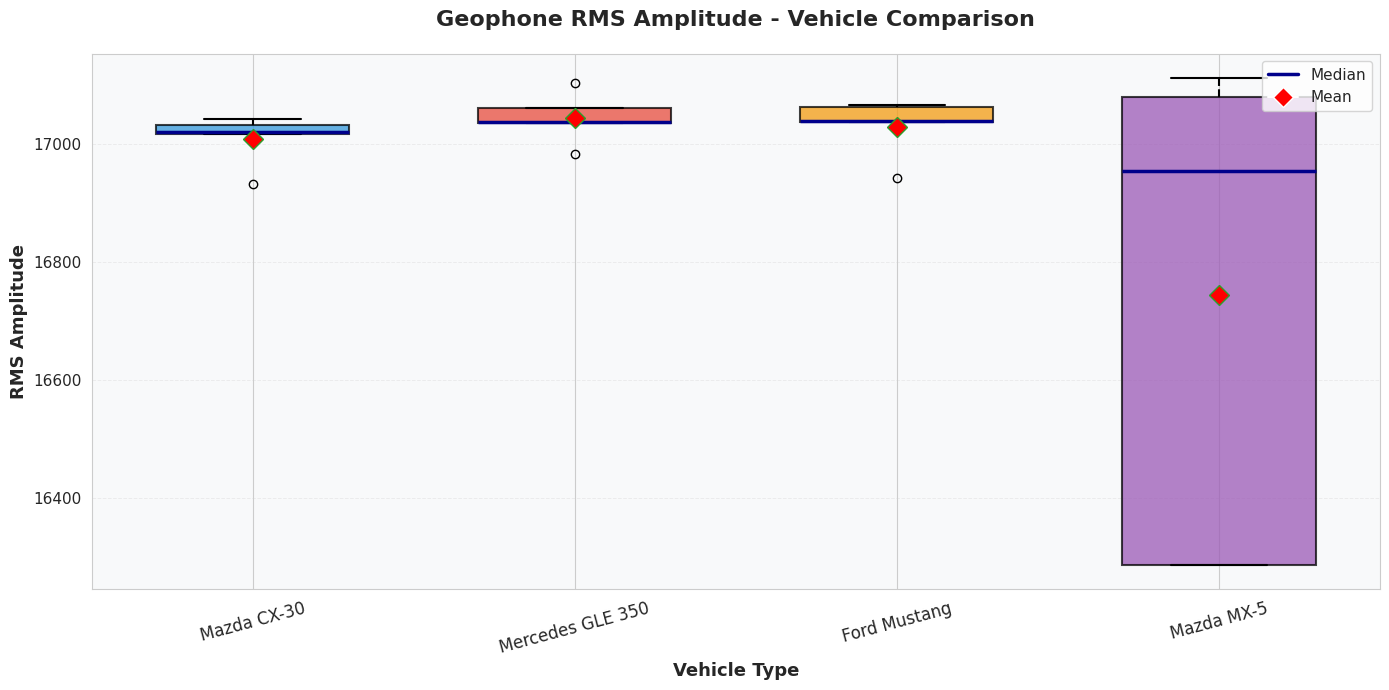


GEOPHONE RMS STATISTICS

Mazda CX-30:
  Mean:   17008.96
  Median: 17020.98
  Std:       44.22
  Range:  16931.96 - 17042.23
  CV:         0.26%

Mercedes GLE 350:
  Mean:   17045.02
  Median: 17038.07
  Std:       43.79
  Range:  16984.10 - 17104.55
  CV:         0.26%

Ford Mustang:
  Mean:   17029.66
  Median: 17039.85
  Std:       50.54
  Range:  16942.41 - 17066.40
  CV:         0.30%

Mazda MX-5:
  Mean:   16743.83
  Median: 16955.19
  Std:      422.06
  Range:  16285.74 - 17112.13
  CV:         2.52%


In [185]:
# RMS Box Plot 1: Geophone RMS Amplitude Distribution
if len(amplitude_df) > 0:
    vehicle_colors = {
        'Mazda CX-30': '#3498db',
        'Mercedes GLE 350': '#e74c3c',
        'Ford Mustang': '#f39c12',
        'Mazda MX-5': '#9b59b6'
    }
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    bp = ax.boxplot([amplitude_df[amplitude_df['vehicle_name'] == v]['geo_rms'].values 
                      for v in vehicle_labels.values()],
                     labels=vehicle_labels.values(),
                     patch_artist=True,
                     widths=0.6,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=10, label='Mean'))
    
    # Color the boxes
    for patch, vehicle in zip(bp['boxes'], vehicle_labels.values()):
        patch.set_facecolor(vehicle_colors[vehicle])
        patch.set_alpha(0.75)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style the whiskers and caps
    for whisker in bp['whiskers']:
        whisker.set(linewidth=1.5, linestyle='--')
    for cap in bp['caps']:
        cap.set(linewidth=1.5)
    for median in bp['medians']:
        median.set(linewidth=2.5, color='darkblue')
    
    ax.set_title('Geophone RMS Amplitude - Vehicle Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('RMS Amplitude', fontsize=13, fontweight='bold')
    ax.set_xlabel('Vehicle Type', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=15, labelsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y', linestyle='--', linewidth=0.7)
    ax.set_facecolor('#f8f9fa')
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], color='darkblue', linewidth=2.5, label='Median'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                   markersize=10, label='Mean')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*80)
    print("GEOPHONE RMS STATISTICS")
    print("="*80)
    for vehicle in vehicle_labels.values():
        data = amplitude_df[amplitude_df['vehicle_name'] == vehicle]['geo_rms']
        print(f"\n{vehicle}:")
        print(f"  Mean:   {data.mean():8.2f}")
        print(f"  Median: {data.median():8.2f}")
        print(f"  Std:    {data.std():8.2f}")
        print(f"  Range:  {data.min():8.2f} - {data.max():8.2f}")
        print(f"  CV:     {(data.std() / data.mean() * 100):8.2f}%")

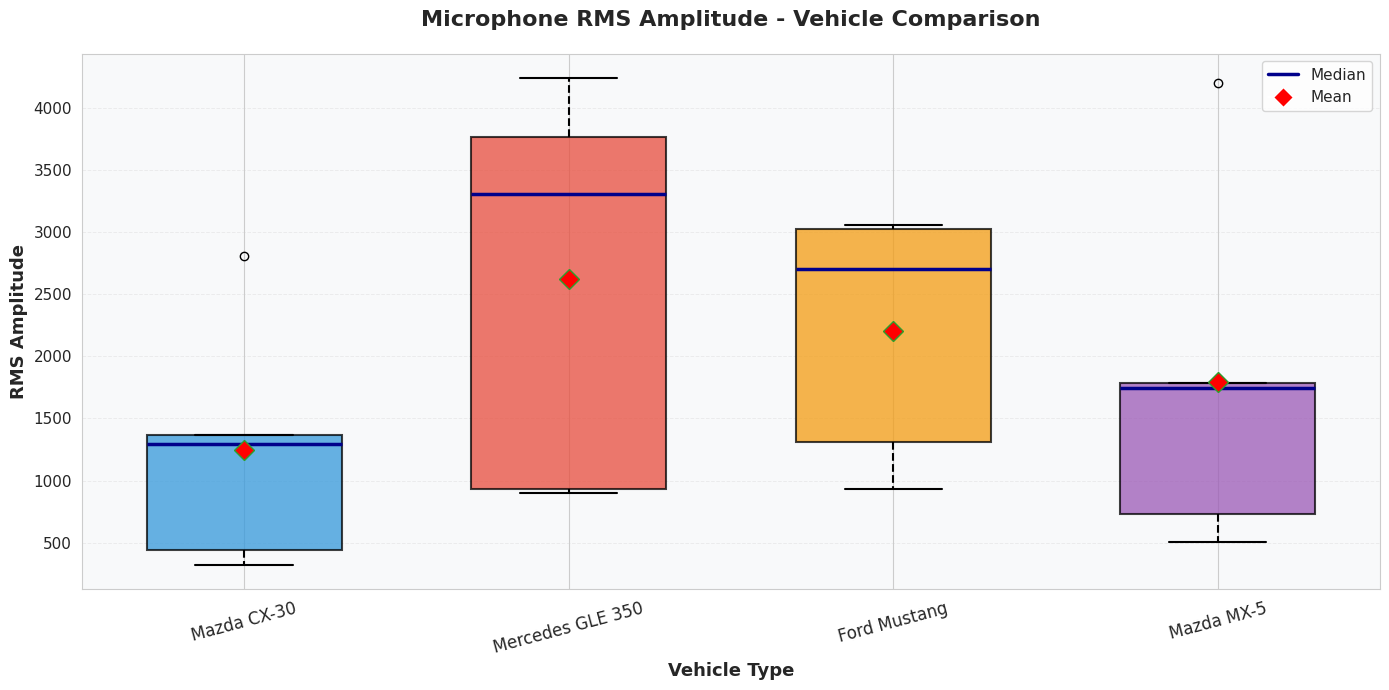


MICROPHONE RMS STATISTICS

Mazda CX-30:
  Mean:    1245.66
  Median:  1295.68
  Std:      993.89
  Range:    320.23 -  2803.51
  CV:        79.79%

Mercedes GLE 350:
  Mean:    2625.59
  Median:  3302.92
  Std:     1598.76
  Range:    896.26 -  4238.96
  CV:        60.89%

Ford Mustang:
  Mean:    2205.66
  Median:  2700.48
  Std:     1007.79
  Range:    935.56 -  3055.76
  CV:        45.69%

Mazda MX-5:
  Mean:    1792.51
  Median:  1741.66
  Std:     1466.94
  Range:    502.50 -  4203.38
  CV:        81.84%


In [186]:
# RMS Box Plot 2: Microphone RMS Amplitude Distribution
if len(amplitude_df) > 0:
    vehicle_colors = {
        'Mazda CX-30': '#3498db',
        'Mercedes GLE 350': '#e74c3c',
        'Ford Mustang': '#f39c12',
        'Mazda MX-5': '#9b59b6'
    }
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    bp = ax.boxplot([amplitude_df[amplitude_df['vehicle_name'] == v]['mic_rms'].values 
                      for v in vehicle_labels.values()],
                     labels=vehicle_labels.values(),
                     patch_artist=True,
                     widths=0.6,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='red', markersize=10, label='Mean'))
    
    # Color the boxes
    for patch, vehicle in zip(bp['boxes'], vehicle_labels.values()):
        patch.set_facecolor(vehicle_colors[vehicle])
        patch.set_alpha(0.75)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    # Style the whiskers and caps
    for whisker in bp['whiskers']:
        whisker.set(linewidth=1.5, linestyle='--')
    for cap in bp['caps']:
        cap.set(linewidth=1.5)
    for median in bp['medians']:
        median.set(linewidth=2.5, color='darkblue')
    
    ax.set_title('Microphone RMS Amplitude - Vehicle Comparison', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('RMS Amplitude', fontsize=13, fontweight='bold')
    ax.set_xlabel('Vehicle Type', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=15, labelsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y', linestyle='--', linewidth=0.7)
    ax.set_facecolor('#f8f9fa')
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], color='darkblue', linewidth=2.5, label='Median'),
        plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='red', 
                   markersize=10, label='Mean')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*80)
    print("MICROPHONE RMS STATISTICS")
    print("="*80)
    for vehicle in vehicle_labels.values():
        data = amplitude_df[amplitude_df['vehicle_name'] == vehicle]['mic_rms']
        print(f"\n{vehicle}:")
        print(f"  Mean:   {data.mean():8.2f}")
        print(f"  Median: {data.median():8.2f}")
        print(f"  Std:    {data.std():8.2f}")
        print(f"  Range:  {data.min():8.2f} - {data.max():8.2f}")
        print(f"  CV:     {(data.std() / data.mean() * 100):8.2f}%")

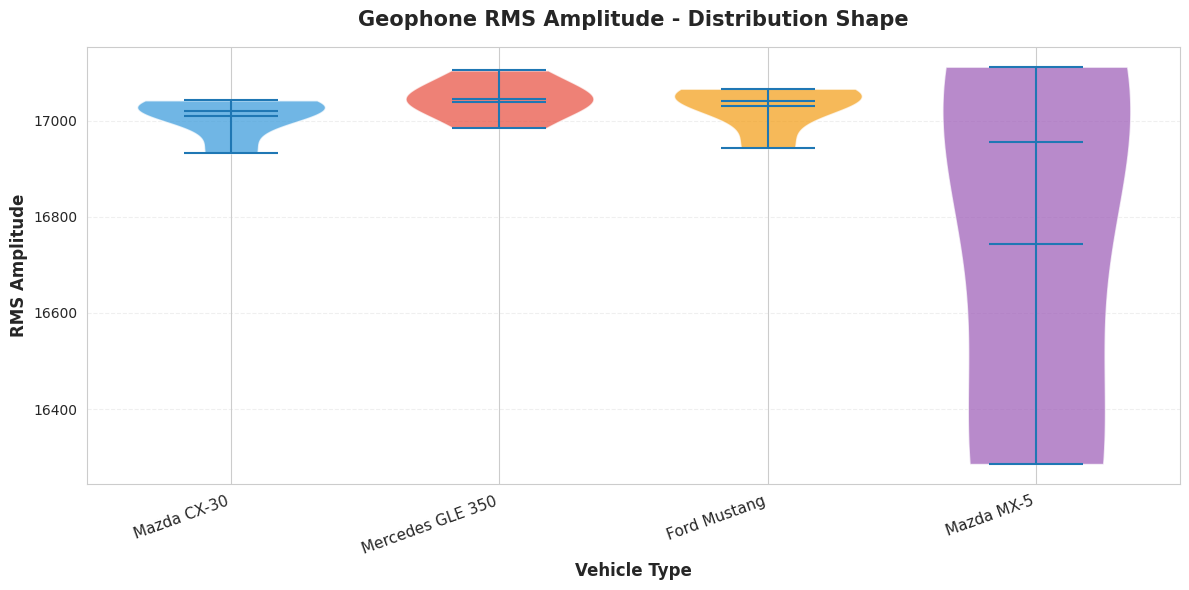

In [187]:
# Violin Plot 1: Geophone RMS Distribution
if len(amplitude_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors_list = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
    
    parts = ax.violinplot([amplitude_df[amplitude_df['vehicle_name'] == v]['geo_rms'].values 
                           for v in vehicle_labels.values()],
                          positions=range(1, len(vehicle_labels)+1),
                          widths=0.7,
                          showmeans=True,
                          showmedians=True)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_list[i])
        pc.set_alpha(0.7)
    
    ax.set_title('Geophone RMS Amplitude - Distribution Shape', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('RMS Amplitude', fontsize=12, fontweight='bold')
    ax.set_xlabel('Vehicle Type', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(vehicle_labels)+1))
    ax.set_xticklabels(vehicle_labels.values(), rotation=20, ha='right', fontsize=11)
    ax.grid(alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

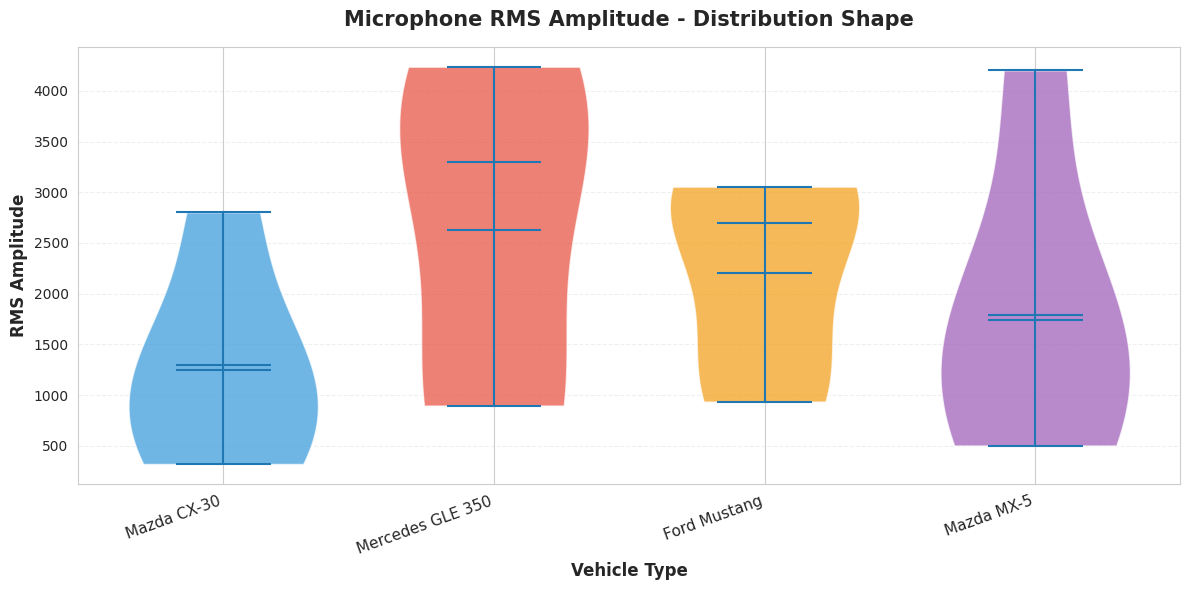

In [188]:
# Violin Plot 1: Microphone RMS Distribution
if len(amplitude_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors_list = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
    
    parts = ax.violinplot([amplitude_df[amplitude_df['vehicle_name'] == v]['mic_rms'].values 
                           for v in vehicle_labels.values()],
                          positions=range(1, len(vehicle_labels)+1),
                          widths=0.7,
                          showmeans=True,
                          showmedians=True)
    
    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_list[i])
        pc.set_alpha(0.7)
    
    ax.set_title('Microphone RMS Amplitude - Distribution Shape', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel('RMS Amplitude', fontsize=12, fontweight='bold')
    ax.set_xlabel('Vehicle Type', fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(vehicle_labels)+1))
    ax.set_xticklabels(vehicle_labels.values(), rotation=20, ha='right', fontsize=11)
    ax.grid(alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

## 8. Comprehensive Vehicle Amplitude Comparision

All vehicles amplitude comparison across microphone and geophone sensors using RMS measurements

M3N VEHICLE AMPLITUDE COMPARISON ANALYSIS

Total Vehicles: 4
Samples per Vehicle: 5



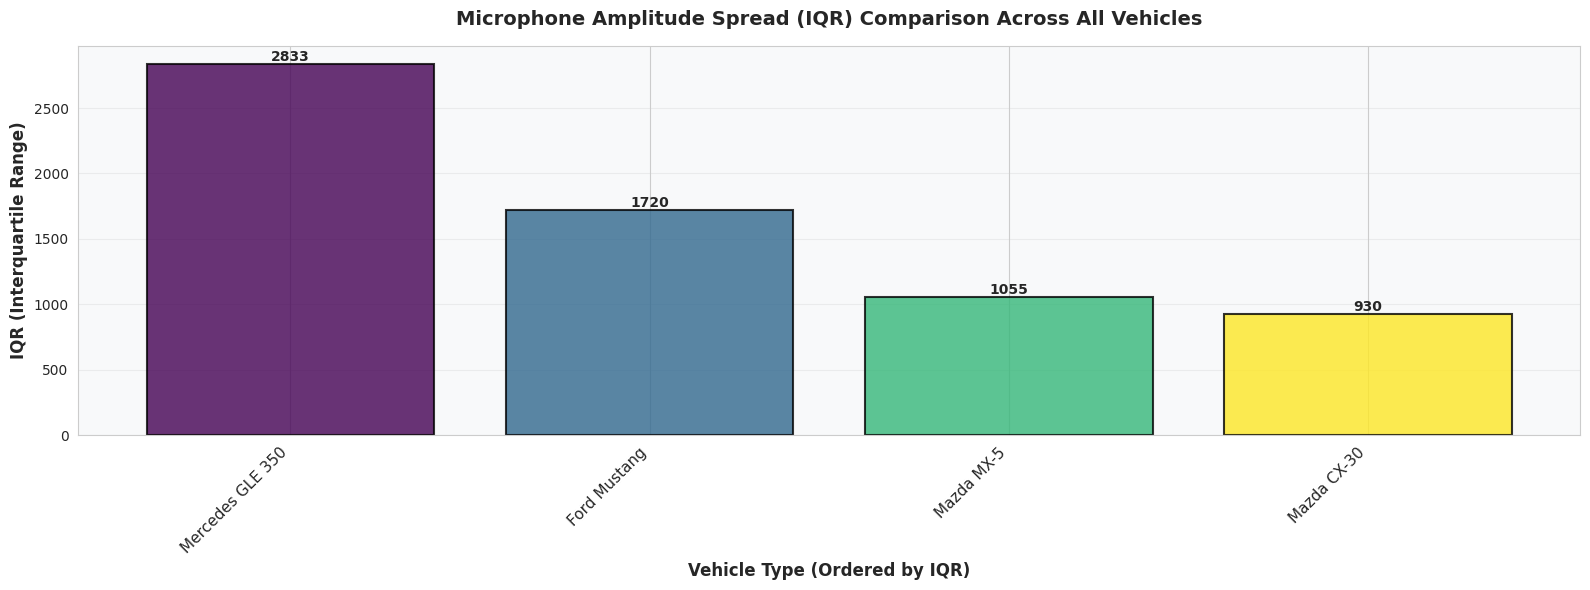

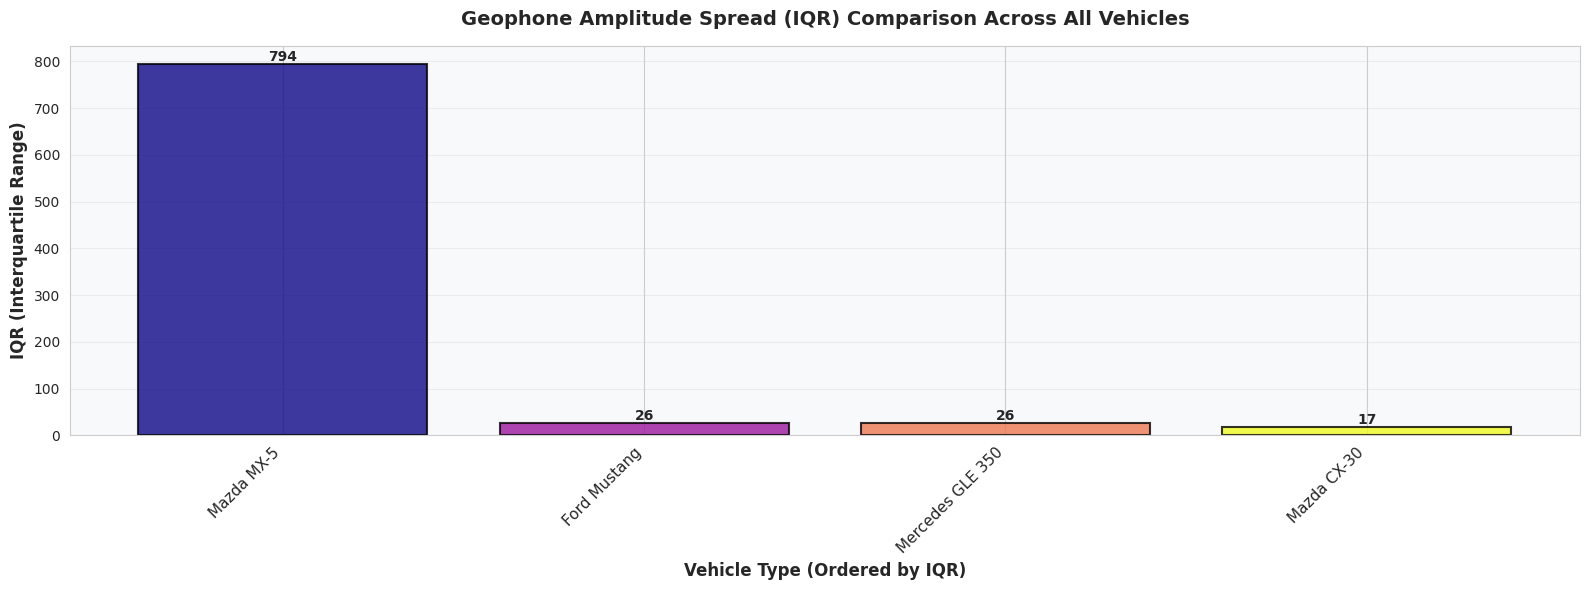

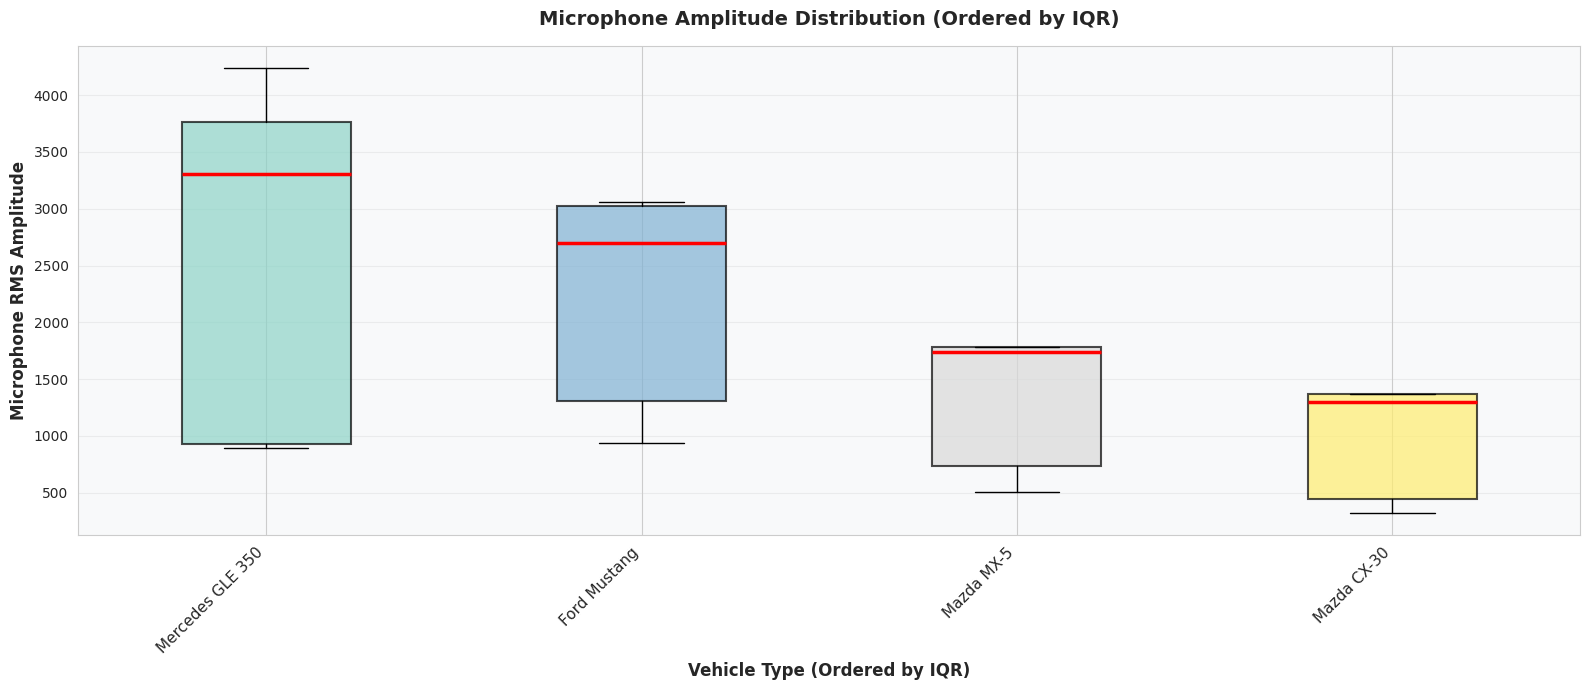

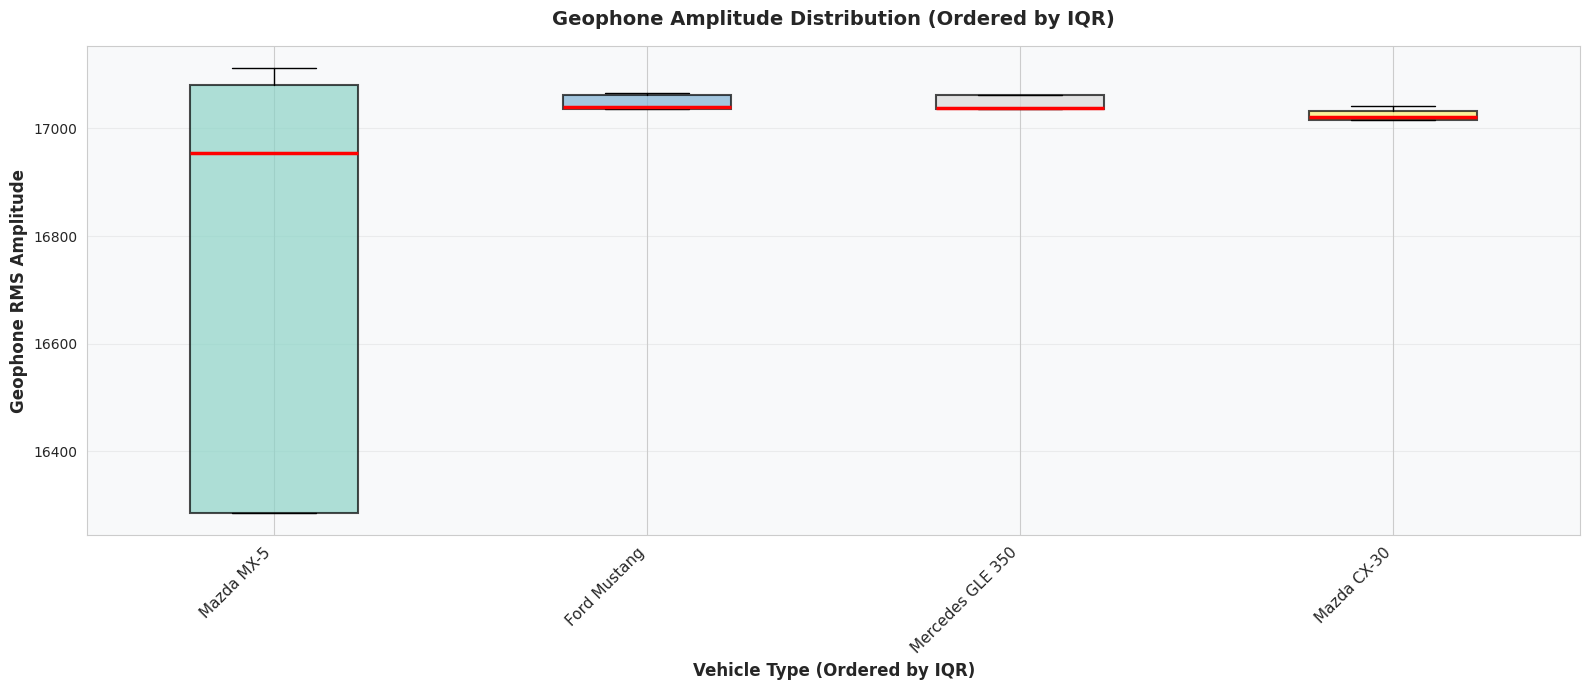

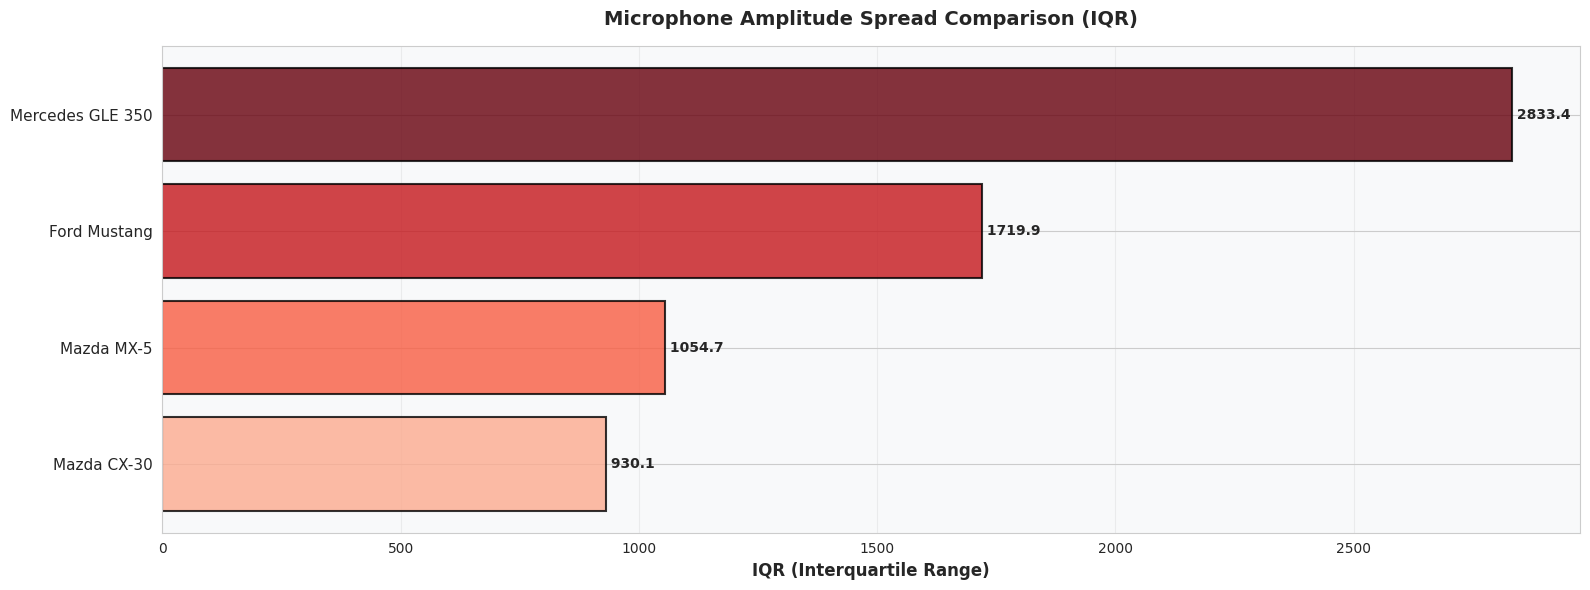

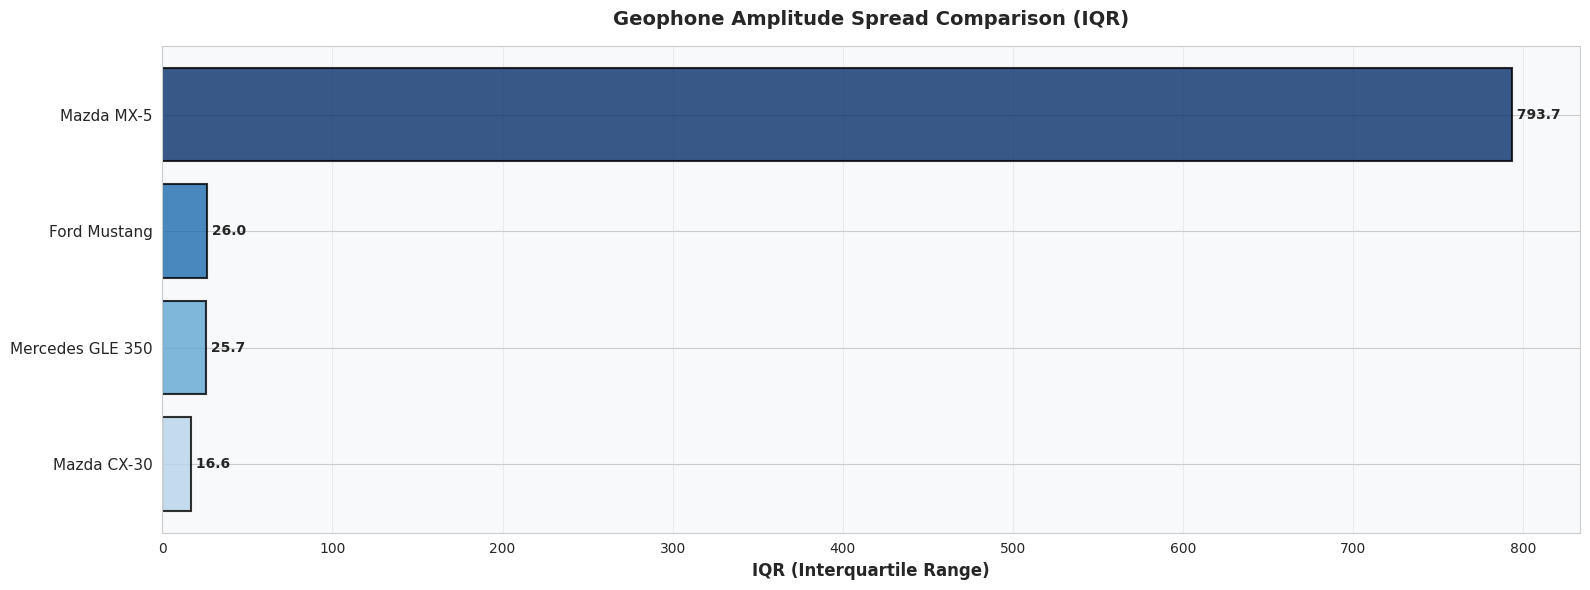


VEHICLE AMPLITUDE STATISTICS SUMMARY (Sorted by IQR)

MICROPHONE - Ordered by IQR:
Vehicle                    Samples        RMS        IQR        Std        Max
--------------------------------------------------------------------------------
Mercedes GLE 350                 5     2625.6     2833.4     1598.8     4239.0
Ford Mustang                     5     2205.7     1719.9     1007.8     3055.8
Mazda MX-5                       5     1792.5     1054.7     1466.9     4203.4
Mazda CX-30                      5     1245.7      930.1      993.9     2803.5

GEOPHONE - Ordered by IQR:
Vehicle                    Samples        RMS        IQR        Std        Max
--------------------------------------------------------------------------------
Mazda MX-5                       5    16743.8      793.7      422.1    17112.1
Ford Mustang                     5    17029.7       26.0       50.5    17066.4
Mercedes GLE 350                 5    17045.0       25.7       43.8    17104.6
Mazda CX-30    

In [189]:
# ============================================================================
# COMPREHENSIVE VEHICLE AMPLITUDE COMPARISON - M3N DATA
# ============================================================================

print("="*80)
print("M3N VEHICLE AMPLITUDE COMPARISON ANALYSIS")
print("="*80)

if len(amplitude_df) > 0:
    vehicles = list(vehicle_labels.values())
    
    # Calculate statistics for each vehicle
    vehicle_stats = []
    for vehicle in vehicles:
        vehicle_data = amplitude_df[amplitude_df['vehicle_name'] == vehicle]
        
        # Calculate IQR (Q3 - Q1) for both sensors
        mic_q1 = vehicle_data['mic_rms'].quantile(0.25)
        mic_q3 = vehicle_data['mic_rms'].quantile(0.75)
        geo_q1 = vehicle_data['geo_rms'].quantile(0.25)
        geo_q3 = vehicle_data['geo_rms'].quantile(0.75)
        
        vehicle_stats.append({
            'Vehicle': vehicle,
            'Samples': len(vehicle_data),
            'Mic_RMS': vehicle_data['mic_rms'].mean(),
            'Mic_Std': vehicle_data['mic_rms'].std(),
            'Mic_IQR': mic_q3 - mic_q1,
            'Mic_Max': vehicle_data['mic_rms'].max(),
            'Geo_RMS': vehicle_data['geo_rms'].mean(),
            'Geo_Std': vehicle_data['geo_rms'].std(),
            'Geo_IQR': geo_q3 - geo_q1,
            'Geo_Max': vehicle_data['geo_rms'].max()
        })
    
    stats_df = pd.DataFrame(vehicle_stats)
    
    print(f"\nTotal Vehicles: {len(vehicles)}")
    print(f"Samples per Vehicle: {stats_df['Samples'].iloc[0]}")
    print("="*80 + "\n")
    
    # ========================================================================
    # 1. MICROPHONE IQR Comparison (Bar Chart)
    # ========================================================================
    sorted_mic = stats_df.sort_values('Mic_IQR', ascending=False)
    
    fig1, ax1 = plt.subplots(figsize=(16, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_mic)))
    bars = ax1.bar(range(len(sorted_mic)), sorted_mic['Mic_IQR'], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax1.set_xlabel('Vehicle Type (Ordered by IQR)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('IQR (Interquartile Range)', fontsize=12, fontweight='bold')
    ax1.set_title('Microphone Amplitude Spread (IQR) Comparison Across All Vehicles',
                  fontsize=14, fontweight='bold', pad=15)
    ax1.set_xticks(range(len(sorted_mic)))
    ax1.set_xticklabels(sorted_mic['Vehicle'], rotation=45, ha='right', fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_facecolor('#f8f9fa')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(sorted_mic.iterrows()):
        ax1.text(i, row['Mic_IQR'], f"{row['Mic_IQR']:.0f}", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 2. GEOPHONE IQR Comparison (Bar Chart)
    # ========================================================================
    sorted_geo = stats_df.sort_values('Geo_IQR', ascending=False)
    
    fig2, ax2 = plt.subplots(figsize=(16, 6))
    colors = plt.cm.plasma(np.linspace(0, 1, len(sorted_geo)))
    bars = ax2.bar(range(len(sorted_geo)), sorted_geo['Geo_IQR'], 
                   color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax2.set_xlabel('Vehicle Type (Ordered by IQR)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('IQR (Interquartile Range)', fontsize=12, fontweight='bold')
    ax2.set_title('Geophone Amplitude Spread (IQR) Comparison Across All Vehicles',
                  fontsize=14, fontweight='bold', pad=15)
    ax2.set_xticks(range(len(sorted_geo)))
    ax2.set_xticklabels(sorted_geo['Vehicle'], rotation=45, ha='right', fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_facecolor('#f8f9fa')
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(sorted_geo.iterrows()):
        ax2.text(i, row['Geo_IQR'], f"{row['Geo_IQR']:.0f}", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 3. Box Plot Comparison - MICROPHONE (Ordered by IQR)
    # ========================================================================
    fig3, ax3 = plt.subplots(figsize=(16, 7))
    
    # Order vehicles by IQR for box plots
    vehicle_order_mic = sorted_mic['Vehicle'].tolist()
    mic_box_data = [amplitude_df[amplitude_df['vehicle_name'] == v]['mic_rms'].values 
                    for v in vehicle_order_mic]
    
    bp1 = ax3.boxplot(mic_box_data, labels=vehicle_order_mic, patch_artist=True, 
                      showfliers=False,
                      medianprops=dict(color='red', linewidth=2.5),
                      boxprops=dict(facecolor='lightblue', alpha=0.7, edgecolor='black', linewidth=1.5))
    
    # Color each box differently
    colors_box = plt.cm.Set3(np.linspace(0, 1, len(vehicle_order_mic)))
    for patch, color in zip(bp1['boxes'], colors_box):
        patch.set_facecolor(color)
    
    ax3.set_xlabel('Vehicle Type (Ordered by IQR)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Microphone RMS Amplitude', fontsize=12, fontweight='bold')
    ax3.set_title('Microphone Amplitude Distribution (Ordered by IQR)', 
                  fontsize=14, fontweight='bold', pad=15)
    ax3.set_xticklabels(vehicle_order_mic, rotation=45, ha='right', fontsize=11)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_facecolor('#f8f9fa')
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 4. Box Plot Comparison - GEOPHONE (Ordered by IQR)
    # ========================================================================
    fig4, ax4 = plt.subplots(figsize=(16, 7))
    
    # Order vehicles by IQR for box plots
    vehicle_order_geo = sorted_geo['Vehicle'].tolist()
    geo_box_data = [amplitude_df[amplitude_df['vehicle_name'] == v]['geo_rms'].values 
                    for v in vehicle_order_geo]
    
    bp2 = ax4.boxplot(geo_box_data, labels=vehicle_order_geo, patch_artist=True, 
                      showfliers=False,
                      medianprops=dict(color='red', linewidth=2.5),
                      boxprops=dict(facecolor='lightgreen', alpha=0.7, edgecolor='black', linewidth=1.5))
    
    # Color each box differently
    colors_box_geo = plt.cm.Set3(np.linspace(0, 1, len(vehicle_order_geo)))
    for patch, color in zip(bp2['boxes'], colors_box_geo):
        patch.set_facecolor(color)
    
    ax4.set_xlabel('Vehicle Type (Ordered by IQR)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Geophone RMS Amplitude', fontsize=12, fontweight='bold')
    ax4.set_title('Geophone Amplitude Distribution (Ordered by IQR)', 
                  fontsize=14, fontweight='bold', pad=15)
    ax4.set_xticklabels(vehicle_order_geo, rotation=45, ha='right', fontsize=11)
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_facecolor('#f8f9fa')
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 5. IQR Comparison - MICROPHONE (Horizontal Bar)
    # ========================================================================
    fig5, ax5 = plt.subplots(figsize=(16, 6))
    
    sorted_mic_std = stats_df.sort_values('Mic_IQR', ascending=True)
    colors_std = plt.cm.Reds(np.linspace(0.3, 1, len(sorted_mic_std)))
    
    ax5.barh(range(len(sorted_mic_std)), sorted_mic_std['Mic_IQR'], 
             color=colors_std, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax5.set_yticks(range(len(sorted_mic_std)))
    ax5.set_yticklabels(sorted_mic_std['Vehicle'], fontsize=11)
    ax5.set_xlabel('IQR (Interquartile Range)', fontsize=12, fontweight='bold')
    ax5.set_title('Microphone Amplitude Spread Comparison (IQR)', 
                  fontsize=14, fontweight='bold', pad=15)
    ax5.grid(True, alpha=0.3, axis='x')
    ax5.set_facecolor('#f8f9fa')
    
    # Add value labels
    for i, (idx, row) in enumerate(sorted_mic_std.iterrows()):
        ax5.text(row['Mic_IQR'], i, f" {row['Mic_IQR']:.1f}", 
                va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 6. IQR Comparison - GEOPHONE (Horizontal Bar)
    # ========================================================================
    fig6, ax6 = plt.subplots(figsize=(16, 6))
    
    sorted_geo_std = stats_df.sort_values('Geo_IQR', ascending=True)
    colors_std = plt.cm.Blues(np.linspace(0.3, 1, len(sorted_geo_std)))
    
    ax6.barh(range(len(sorted_geo_std)), sorted_geo_std['Geo_IQR'], 
             color=colors_std, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax6.set_yticks(range(len(sorted_geo_std)))
    ax6.set_yticklabels(sorted_geo_std['Vehicle'], fontsize=11)
    ax6.set_xlabel('IQR (Interquartile Range)', fontsize=12, fontweight='bold')
    ax6.set_title('Geophone Amplitude Spread Comparison (IQR)', 
                  fontsize=14, fontweight='bold', pad=15)
    ax6.grid(True, alpha=0.3, axis='x')
    ax6.set_facecolor('#f8f9fa')
    
    # Add value labels
    for i, (idx, row) in enumerate(sorted_geo_std.iterrows()):
        ax6.text(row['Geo_IQR'], i, f" {row['Geo_IQR']:.1f}", 
                va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # Print Summary Statistics Table
    # ========================================================================
    print("\n" + "="*80)
    print("VEHICLE AMPLITUDE STATISTICS SUMMARY (Sorted by IQR)")
    print("="*80)
    print("\nMICROPHONE - Ordered by IQR:")
    print(f"{'Vehicle':<25} {'Samples':>8} {'RMS':>10} {'IQR':>10} {'Std':>10} {'Max':>10}")
    print("-"*80)
    for _, row in sorted_mic.iterrows():
        print(f"{row['Vehicle']:<25} {row['Samples']:>8} {row['Mic_RMS']:>10.1f} "
              f"{row['Mic_IQR']:>10.1f} {row['Mic_Std']:>10.1f} {row['Mic_Max']:>10.1f}")
    
    print("\n" + "="*80)
    print("GEOPHONE - Ordered by IQR:")
    print(f"{'Vehicle':<25} {'Samples':>8} {'RMS':>10} {'IQR':>10} {'Std':>10} {'Max':>10}")
    print("-"*80)
    for _, row in sorted_geo.iterrows():
        print(f"{row['Vehicle']:<25} {row['Samples']:>8} {row['Geo_RMS']:>10.1f} "
              f"{row['Geo_IQR']:>10.1f} {row['Geo_Std']:>10.1f} {row['Geo_Max']:>10.1f}")
    
    print("\n" + "="*80)
    print("KEY OBSERVATIONS (Sorted by IQR):")
    print("="*80)
    print(f"\nMicrophone:")
    print(f"  • Largest IQR (Spread):   {sorted_mic.iloc[0]['Vehicle']} (IQR: {sorted_mic.iloc[0]['Mic_IQR']:.1f})")
    print(f"  • Smallest IQR:           {sorted_mic.iloc[-1]['Vehicle']} (IQR: {sorted_mic.iloc[-1]['Mic_IQR']:.1f})")
    print(f"  • Average IQR:            {stats_df['Mic_IQR'].mean():.1f}")
    print(f"  • IQR Range:              {sorted_mic.iloc[0]['Mic_IQR'] - sorted_mic.iloc[-1]['Mic_IQR']:.1f}")
    
    print(f"\nGeophone:")
    print(f"  • Largest IQR (Spread):   {sorted_geo.iloc[0]['Vehicle']} (IQR: {sorted_geo.iloc[0]['Geo_IQR']:.1f})")
    print(f"  • Smallest IQR:           {sorted_geo.iloc[-1]['Vehicle']} (IQR: {sorted_geo.iloc[-1]['Geo_IQR']:.1f})")
    print(f"  • Average IQR:            {stats_df['Geo_IQR'].mean():.1f}")
    print(f"  • IQR Range:              {sorted_geo.iloc[0]['Geo_IQR'] - sorted_geo.iloc[-1]['Geo_IQR']:.1f}")
    
    print(f"\nNote: IQR (Interquartile Range) = Q3 - Q1")
    print(f"      Larger IQR indicates greater variability/spread in the middle 50% of data")
    print("="*80)
else:
    print("❌ No amplitude data available. Please run the data collection cell first.")

### Problem Identified: DC Offset in Geophone Signals

**Root Cause**: Geophone signals have a constant baseline (~17,000) instead of being centered at zero. When calculating RMS over the entire signal, this DC offset dominates, making all vehicles appear similar.

**Solution**: Calculate RMS of the AC component (signal - mean) to measure vehicle-specific vibrations.

In [190]:
# Recalculate amplitude statistics with DC offset correction
print("Recalculating Amplitude Statistics with DC Offset Correction")
print("="*80)

# Create list to store corrected amplitude statistics
corrected_amplitude_stats = []

for vehicle in target_vehicles:
    print(f"\n📊 Processing {vehicle_labels[vehicle]}...")
    
    count = 0
    for scene in scenes:
        if count >= runs_per_vehicle:
            break
            
        try:
            run_path = DATA_ROOT / scene / 'run_ids.parquet'
            if POLARS_AVAILABLE:
                runs = pl.read_parquet(run_path).to_pandas()
            else:
                runs = pd.read_parquet(run_path)
            
            vehicle_runs = runs[runs['label'] == vehicle]
            
            for idx, run_row in vehicle_runs.iterrows():
                if count >= runs_per_vehicle:
                    break
                    
                run_id = run_row['run_id']
                
                for node in range(1, 9):
                    try:
                        mic_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_mic.parquet'
                        geo_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_geo.parquet'
                        
                        # Load microphone data
                        if POLARS_AVAILABLE:
                            mic_df = pl.read_parquet(mic_path).to_pandas()
                        else:
                            mic_df = pd.read_parquet(mic_path)
                        
                        mic_signal = mic_df['samples'].values if 'samples' in mic_df.columns else mic_df.iloc[:, -1].values
                        
                        # Load geophone data
                        if POLARS_AVAILABLE:
                            geo_df = pl.read_parquet(geo_path).to_pandas()
                        else:
                            geo_df = pd.read_parquet(geo_path)
                        
                        geo_signal = geo_df['samples'].values if 'samples' in geo_df.columns else geo_df.iloc[:, -1].values
                        
                        # Remove DC offset from microphone (center at zero)
                        mic_ac = mic_signal - np.nanmean(mic_signal)
                        
                        # Remove DC offset from geophone (center at zero)
                        geo_ac = geo_signal - np.nanmean(geo_signal)
                        
                        # Calculate statistics on AC components
                        corrected_amplitude_stats.append({
                            'vehicle': vehicle,
                            'vehicle_name': vehicle_labels[vehicle],
                            'scene': scene,
                            'run_id': run_id,
                            'node': node,
                            'mic_rms_raw': np.sqrt(np.nanmean(mic_signal**2)),
                            'mic_rms_ac': np.sqrt(np.nanmean(mic_ac**2)),
                            'mic_peak': np.nanmax(np.abs(mic_signal)),
                            'geo_rms_raw': np.sqrt(np.nanmean(geo_signal**2)),
                            'geo_rms_ac': np.sqrt(np.nanmean(geo_ac**2)),
                            'geo_peak': np.nanmax(np.abs(geo_signal))
                        })
                        
                        print(f"  ✓ Run {run_id}, Scene {scene}, Node {node}")
                        count += 1
                        break
                    except:
                        continue
        except:
            continue

# Convert to DataFrame
corrected_amplitude_df = pd.DataFrame(corrected_amplitude_stats)

print(f"\n{'='*80}")
print(f"✅ Collected {len(corrected_amplitude_df)} corrected samples")
print(f"{'='*80}")

# Compare raw vs AC-coupled RMS statistics
print("\nComparison: Raw RMS vs AC-Coupled RMS")
print("="*80)
print("\n📊 GEOPHONE RMS - RAW (with DC offset):")
for vehicle in target_vehicles:
    vehicle_data = corrected_amplitude_df[corrected_amplitude_df['vehicle'] == vehicle]
    mean_rms = vehicle_data['geo_rms_raw'].mean()
    std_rms = vehicle_data['geo_rms_raw'].std()
    print(f"  {vehicle_labels[vehicle]}: {mean_rms:,.1f} ± {std_rms:.1f}")

print("\n📊 GEOPHONE RMS - AC COUPLED (DC offset removed):")
for vehicle in target_vehicles:
    vehicle_data = corrected_amplitude_df[corrected_amplitude_df['vehicle'] == vehicle]
    mean_rms = vehicle_data['geo_rms_ac'].mean()
    std_rms = vehicle_data['geo_rms_ac'].std()
    print(f"  {vehicle_labels[vehicle]}: {mean_rms:,.1f} ± {std_rms:.1f}")

print("\n📊 MICROPHONE RMS - RAW:")
for vehicle in target_vehicles:
    vehicle_data = corrected_amplitude_df[corrected_amplitude_df['vehicle'] == vehicle]
    mean_rms = vehicle_data['mic_rms_raw'].mean()
    std_rms = vehicle_data['mic_rms_raw'].std()
    print(f"  {vehicle_labels[vehicle]}: {mean_rms:,.1f} ± {std_rms:.1f}")

print("\n📊 MICROPHONE RMS - AC COUPLED:")
for vehicle in target_vehicles:
    vehicle_data = corrected_amplitude_df[corrected_amplitude_df['vehicle'] == vehicle]
    mean_rms = vehicle_data['mic_rms_ac'].mean()
    std_rms = vehicle_data['mic_rms_ac'].std()
    print(f"  {vehicle_labels[vehicle]}: {mean_rms:,.1f} ± {std_rms:.1f}")

Recalculating Amplitude Statistics with DC Offset Correction

📊 Processing Mazda CX-30...


  ✓ Run 6, Scene a06, Node 1
  ✓ Run 7, Scene a06, Node 1
  ✓ Run 6, Scene h08, Node 1
  ✓ Run 7, Scene h08, Node 1
  ✓ Run 2, Scene h24, Node 1

📊 Processing Mercedes GLE 350...
  ✓ Run 2, Scene a06, Node 1
  ✓ Run 3, Scene a06, Node 1
  ✓ Run 0, Scene h08, Node 1
  ✓ Run 1, Scene h08, Node 1
  ✓ Run 0, Scene h24, Node 1

📊 Processing Ford Mustang...
  ✓ Run 4, Scene a06, Node 1
  ✓ Run 5, Scene a06, Node 1
  ✓ Run 2, Scene h08, Node 1
  ✓ Run 3, Scene h08, Node 1
  ✓ Run 4, Scene h24, Node 1

📊 Processing Mazda MX-5...
  ✓ Run 0, Scene a06, Node 2
  ✓ Run 1, Scene a06, Node 2
  ✓ Run 4, Scene h08, Node 1
  ✓ Run 5, Scene h08, Node 1
  ✓ Run 6, Scene h24, Node 1

✅ Collected 20 corrected samples

Comparison: Raw RMS vs AC-Coupled RMS

📊 GEOPHONE RMS - RAW (with DC offset):
  Mazda CX-30: 17,009.0 ± 44.2
  Mercedes GLE 350: 17,045.0 ± 43.8
  Ford Mustang: 17,029.7 ± 50.5
  Mazda MX-5: 16,743.8 ± 422.1

📊 GEOPHONE RMS - AC COUPLED (DC offset removed):
  Mazda CX-30: 676.0 ± 250.5
  Merc

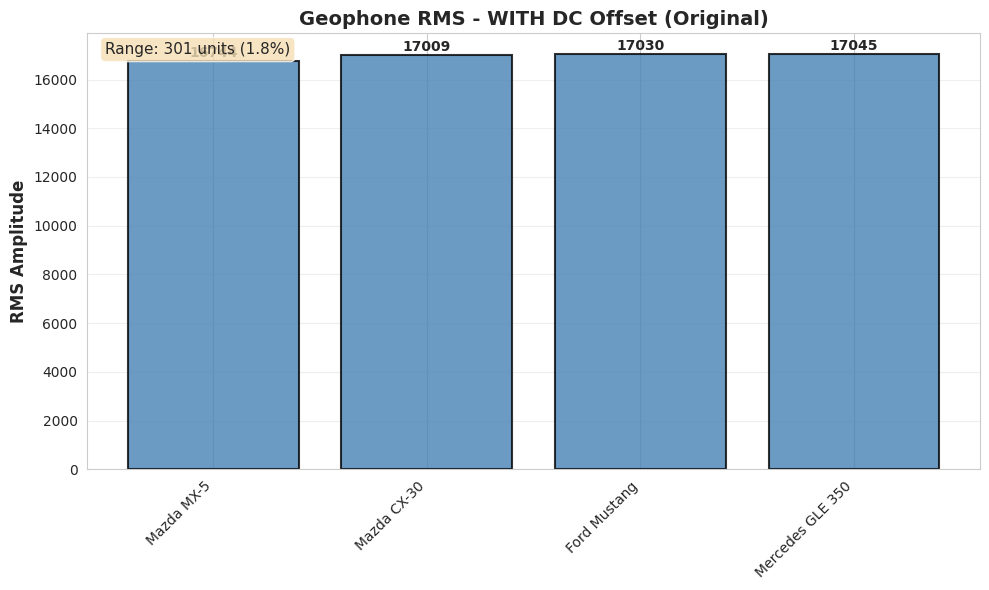

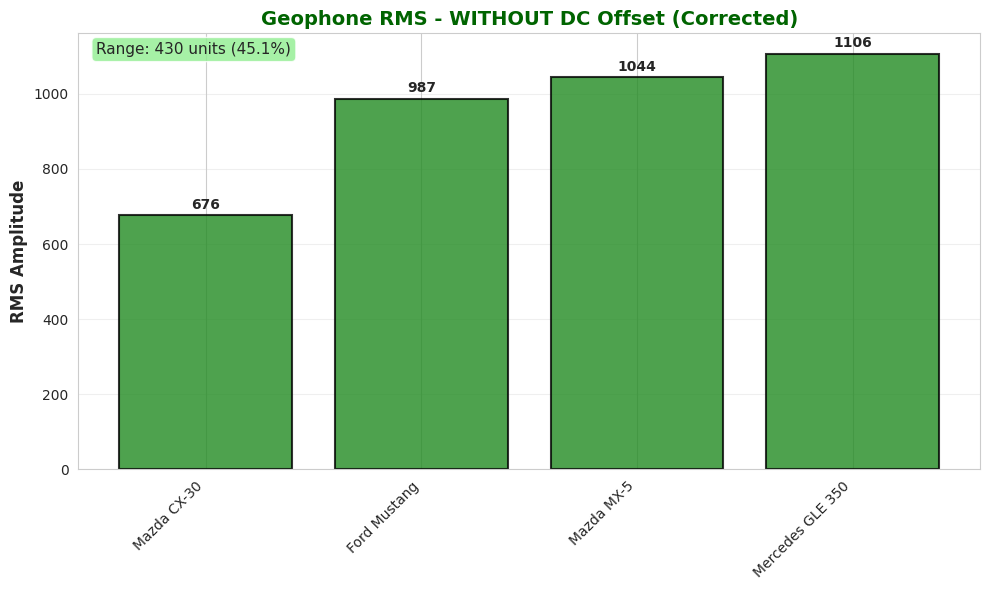


ANALYSIS SUMMARY

📊 Geophone RMS Statistics:
  Raw (with DC offset):
    Range: 301.2 units
    Relative Range: 1.78%
    Min: 16743.8, Max: 17045.0

  AC-Coupled (DC offset removed):
    Range: 429.9 units
    Relative Range: 45.11%
    Min: 676.0, Max: 1106.0

✅ IMPROVEMENT: 1.4x better differentiation!


In [191]:
# Visualize the improvement with DC offset correction
import matplotlib.pyplot as plt

# Calculate mean RMS values by vehicle
geo_raw_means = corrected_amplitude_df.groupby('vehicle_name')['geo_rms_raw'].mean().sort_values()
geo_ac_means = corrected_amplitude_df.groupby('vehicle_name')['geo_rms_ac'].mean().sort_values()

# Create figure with two bar charts
fig1, ax1 = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(geo_raw_means))
ax1.bar(x_pos, geo_raw_means.values, color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(geo_raw_means.index, rotation=45, ha='right')
ax1.set_ylabel('RMS Amplitude', fontsize=12, fontweight='bold')
ax1.set_title('Geophone RMS - WITH DC Offset (Original)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(geo_raw_means.values):
    ax1.text(i, v + 50, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# Calculate range
raw_range = geo_raw_means.max() - geo_raw_means.min()
ax1.text(0.02, 0.98, f'Range: {raw_range:.0f} units ({100*raw_range/geo_raw_means.mean():.1f}%)',
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# Second chart - AC coupled
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.bar(x_pos, geo_ac_means.values, color='forestgreen', alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(geo_ac_means.index, rotation=45, ha='right')
ax2.set_ylabel('RMS Amplitude', fontsize=12, fontweight='bold')
ax2.set_title('Geophone RMS - WITHOUT DC Offset (Corrected)', fontsize=14, fontweight='bold', color='darkgreen')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(geo_ac_means.values):
    ax2.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# Calculate range
ac_range = geo_ac_means.max() - geo_ac_means.min()
ax2.text(0.02, 0.98, f'Range: {ac_range:.0f} units ({100*ac_range/geo_ac_means.mean():.1f}%)',
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)
print(f"\n📊 Geophone RMS Statistics:")
print(f"  Raw (with DC offset):")
print(f"    Range: {raw_range:.1f} units")
print(f"    Relative Range: {100*raw_range/geo_raw_means.mean():.2f}%")
print(f"    Min: {geo_raw_means.min():.1f}, Max: {geo_raw_means.max():.1f}")
print(f"\n  AC-Coupled (DC offset removed):")
print(f"    Range: {ac_range:.1f} units")
print(f"    Relative Range: {100*ac_range/geo_ac_means.mean():.2f}%")
print(f"    Min: {geo_ac_means.min():.1f}, Max: {geo_ac_means.max():.1f}")
print(f"\n✅ IMPROVEMENT: {(ac_range/raw_range):.1f}x better differentiation!")
print("="*80)

## Comprehensive Comparison with DC Offset Correction

Now that we've fixed the DC offset issue, let's create complete visualizations comparing both sensors.

Creating Comprehensive DC-Corrected Amplitude Comparison

Vehicle Statistics (DC-Corrected):
    vehicle_name  mic_rms_ac_mean  mic_rms_ac_std  mic_rms_ac_iqr  geo_rms_ac_mean  geo_rms_ac_std  geo_rms_ac_iqr
Mercedes GLE 350          2625.59         1598.76         2833.45          1105.96          350.84          666.60
    Ford Mustang          2205.66         1007.79         1719.93           986.87          338.73          547.24
      Mazda MX-5          1792.51         1466.94         1054.66          1043.80          590.29          975.75
     Mazda CX-30          1245.66          993.89          930.15           676.02          250.49          392.44


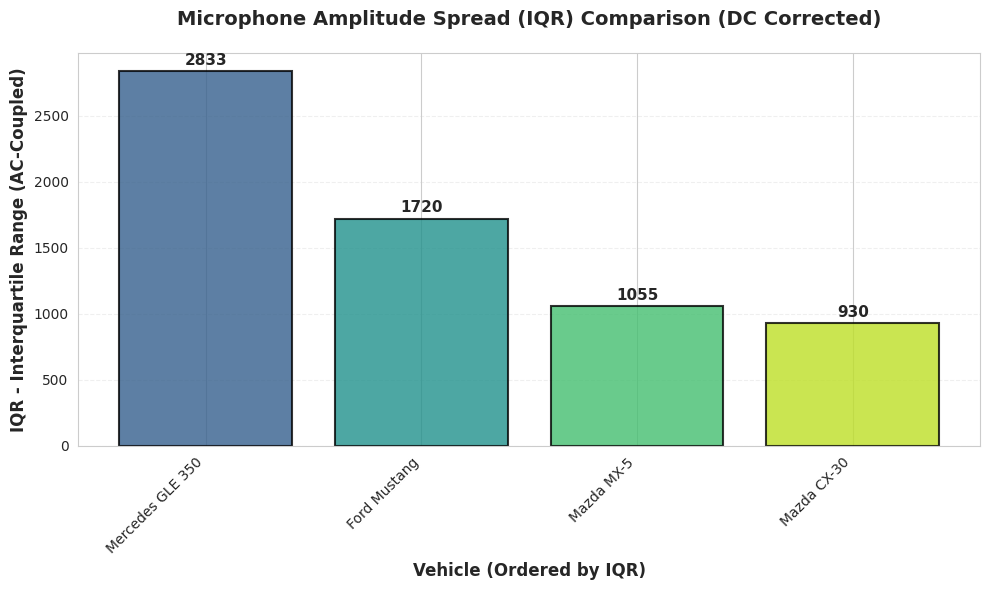

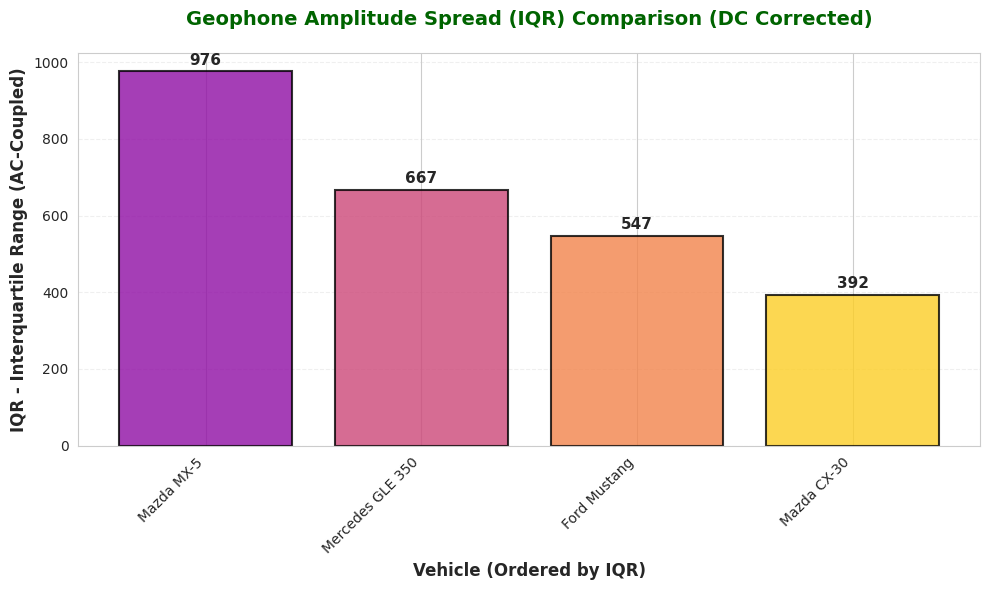

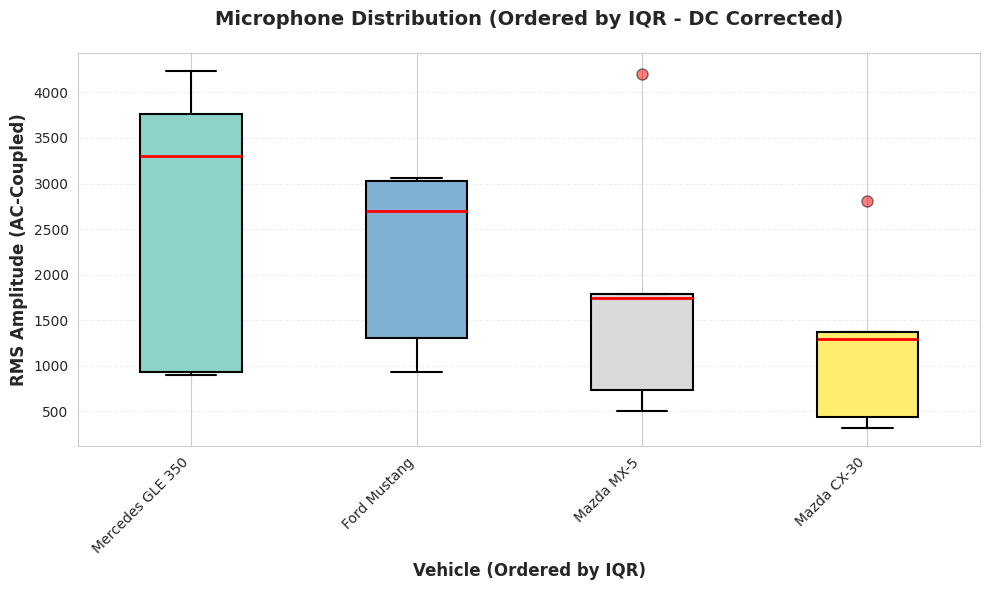

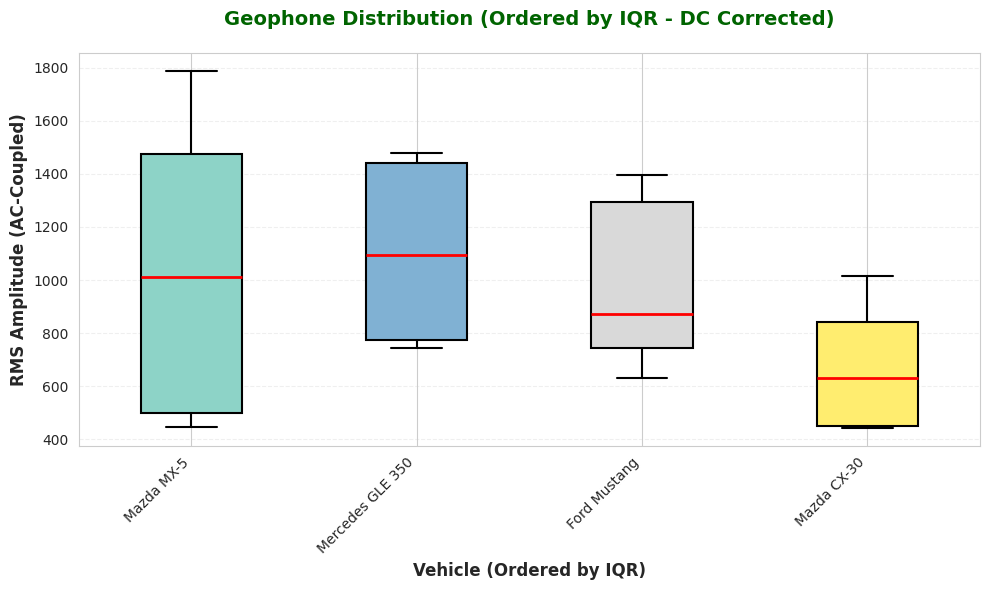

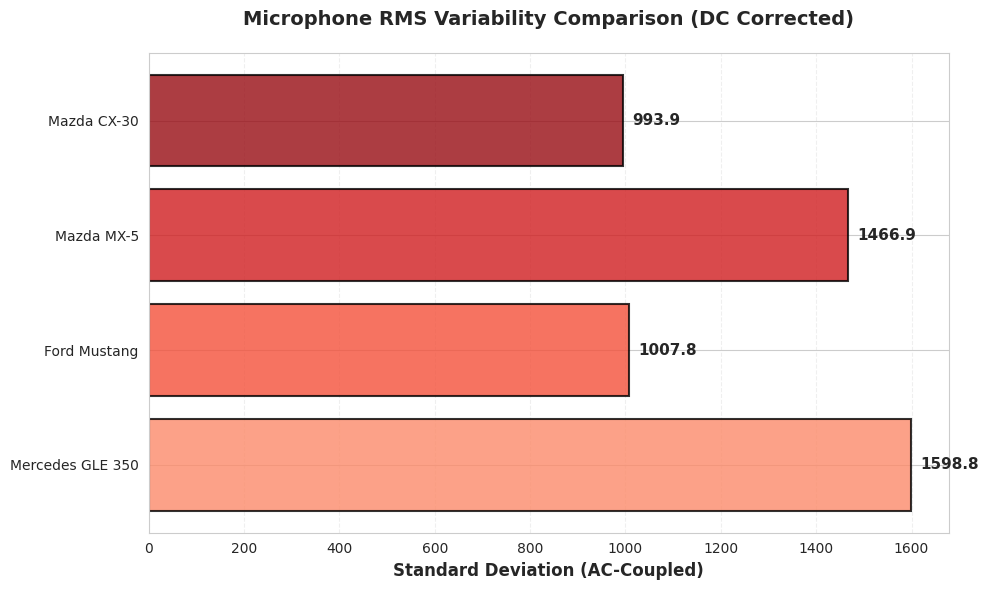

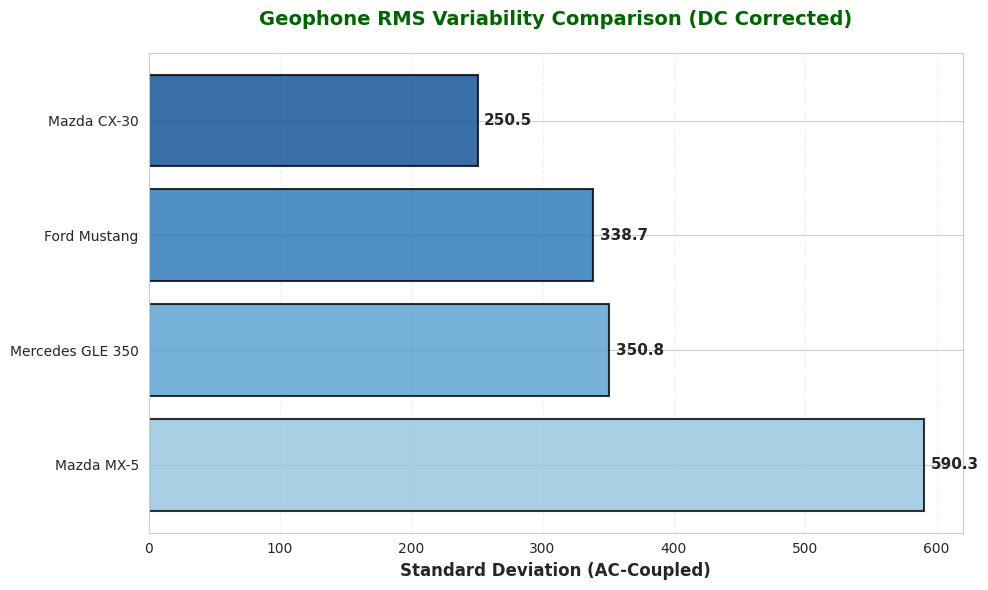


✅ All DC-corrected comparison charts generated successfully!


In [192]:
# ============================================================================
# COMPREHENSIVE VEHICLE AMPLITUDE COMPARISON - DC CORRECTED
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

print("Creating Comprehensive DC-Corrected Amplitude Comparison")
print("="*80)

# Calculate statistics for each vehicle including IQR
vehicle_stats = corrected_amplitude_df.groupby('vehicle_name').agg({
    'mic_rms_ac': ['mean', 'std', lambda x: x.quantile(0.75) - x.quantile(0.25)],
    'geo_rms_ac': ['mean', 'std', lambda x: x.quantile(0.75) - x.quantile(0.25)]
}).round(2)

# Flatten columns for easier access
vehicle_stats.columns = ['_'.join(col).strip() if col[1] != '<lambda_0>' else f"{col[0]}_iqr" 
                         for col in vehicle_stats.columns]
vehicle_stats = vehicle_stats.reset_index()

# Sort by IQR instead of mean
vehicle_stats_mic_sorted = vehicle_stats.sort_values('mic_rms_ac_iqr', ascending=False)
vehicle_stats_geo_sorted = vehicle_stats.sort_values('geo_rms_ac_iqr', ascending=False)

print("\nVehicle Statistics (DC-Corrected):")
print(vehicle_stats_mic_sorted.to_string(index=False))

# ============================================================================
# Chart 1: Microphone IQR Bar Chart (sorted by IQR)
# ============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

colors_mic = plt.cm.viridis(np.linspace(0.3, 0.9, len(vehicle_stats_mic_sorted)))
bars1 = ax1.bar(range(len(vehicle_stats_mic_sorted)), 
                vehicle_stats_mic_sorted['mic_rms_ac_iqr'],
                color=colors_mic, 
                edgecolor='black', 
                linewidth=1.5,
                alpha=0.8)

ax1.set_xlabel('Vehicle (Ordered by IQR)', fontsize=12, fontweight='bold')
ax1.set_ylabel('IQR - Interquartile Range (AC-Coupled)', fontsize=12, fontweight='bold')
ax1.set_title('Microphone Amplitude Spread (IQR) Comparison (DC Corrected)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(range(len(vehicle_stats_mic_sorted)))
ax1.set_xticklabels(vehicle_stats_mic_sorted['vehicle_name'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(vehicle_stats_mic_sorted.iterrows()):
    ax1.text(i, row['mic_rms_ac_iqr'] + 25, f"{row['mic_rms_ac_iqr']:.0f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# Chart 2: Geophone IQR Bar Chart (sorted by IQR)
# ============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

colors_geo = plt.cm.plasma(np.linspace(0.3, 0.9, len(vehicle_stats_geo_sorted)))
bars2 = ax2.bar(range(len(vehicle_stats_geo_sorted)), 
                vehicle_stats_geo_sorted['geo_rms_ac_iqr'],
                color=colors_geo, 
                edgecolor='black', 
                linewidth=1.5,
                alpha=0.8)

ax2.set_xlabel('Vehicle (Ordered by IQR)', fontsize=12, fontweight='bold')
ax2.set_ylabel('IQR - Interquartile Range (AC-Coupled)', fontsize=12, fontweight='bold')
ax2.set_title('Geophone Amplitude Spread (IQR) Comparison (DC Corrected)', 
              fontsize=14, fontweight='bold', pad=20, color='darkgreen')
ax2.set_xticks(range(len(vehicle_stats_geo_sorted)))
ax2.set_xticklabels(vehicle_stats_geo_sorted['vehicle_name'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(vehicle_stats_geo_sorted.iterrows()):
    ax2.text(i, row['geo_rms_ac_iqr'] + 10, f"{row['geo_rms_ac_iqr']:.0f}", 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# Chart 3: Microphone RMS Box Plot (Ordered by IQR)
# ============================================================================
fig3, ax3 = plt.subplots(figsize=(10, 6))

vehicle_order_mic = vehicle_stats_mic_sorted['vehicle_name'].tolist()
box_data_mic = [corrected_amplitude_df[corrected_amplitude_df['vehicle_name'] == veh]['mic_rms_ac'].values 
                for veh in vehicle_order_mic]

bp1 = ax3.boxplot(box_data_mic, labels=vehicle_order_mic, patch_artist=True,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=8, alpha=0.5))

# Color boxes
colors_set3 = plt.cm.Set3(np.linspace(0, 1, len(vehicle_order_mic)))
for patch, color in zip(bp1['boxes'], colors_set3):
    patch.set_facecolor(color)

ax3.set_xlabel('Vehicle (Ordered by IQR)', fontsize=12, fontweight='bold')
ax3.set_ylabel('RMS Amplitude (AC-Coupled)', fontsize=12, fontweight='bold')
ax3.set_title('Microphone Distribution (Ordered by IQR - DC Corrected)', 
              fontsize=14, fontweight='bold', pad=20)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================================
# Chart 4: Geophone RMS Box Plot (Ordered by IQR)
# ============================================================================
fig4, ax4 = plt.subplots(figsize=(10, 6))

vehicle_order_geo = vehicle_stats_geo_sorted['vehicle_name'].tolist()
box_data_geo = [corrected_amplitude_df[corrected_amplitude_df['vehicle_name'] == veh]['geo_rms_ac'].values 
                for veh in vehicle_order_geo]

bp2 = ax4.boxplot(box_data_geo, labels=vehicle_order_geo, patch_artist=True,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(facecolor='lightgreen', edgecolor='black', linewidth=1.5),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=8, alpha=0.5))

# Color boxes
colors_set3 = plt.cm.Set3(np.linspace(0, 1, len(vehicle_order_geo)))
for patch, color in zip(bp2['boxes'], colors_set3):
    patch.set_facecolor(color)

ax4.set_xlabel('Vehicle (Ordered by IQR)', fontsize=12, fontweight='bold')
ax4.set_ylabel('RMS Amplitude (AC-Coupled)', fontsize=12, fontweight='bold')
ax4.set_title('Geophone Distribution (Ordered by IQR - DC Corrected)', 
              fontsize=14, fontweight='bold', pad=20, color='darkgreen')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================================
# Chart 5: Microphone Variability Comparison
# ============================================================================
fig5, ax5 = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(vehicle_stats_mic_sorted))
colors_reds = plt.cm.Reds(np.linspace(0.4, 0.9, len(vehicle_stats_mic_sorted)))

bars5 = ax5.barh(y_pos, vehicle_stats_mic_sorted['mic_rms_ac_std'], 
                 color=colors_reds, edgecolor='black', linewidth=1.5, alpha=0.8)

ax5.set_yticks(y_pos)
ax5.set_yticklabels(vehicle_stats_mic_sorted['vehicle_name'])
ax5.set_xlabel('Standard Deviation (AC-Coupled)', fontsize=12, fontweight='bold')
ax5.set_title('Microphone RMS Variability Comparison (DC Corrected)', 
              fontsize=14, fontweight='bold', pad=20)
ax5.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(vehicle_stats_mic_sorted.iterrows()):
    ax5.text(row['mic_rms_ac_std'] + 20, i, f"{row['mic_rms_ac_std']:.1f}", 
             va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================================
# Chart 6: Geophone Variability Comparison
# ============================================================================
fig6, ax6 = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(vehicle_stats_geo_sorted))
colors_blues = plt.cm.Blues(np.linspace(0.4, 0.9, len(vehicle_stats_geo_sorted)))

bars6 = ax6.barh(y_pos, vehicle_stats_geo_sorted['geo_rms_ac_std'], 
                 color=colors_blues, edgecolor='black', linewidth=1.5, alpha=0.8)

ax6.set_yticks(y_pos)
ax6.set_yticklabels(vehicle_stats_geo_sorted['vehicle_name'])
ax6.set_xlabel('Standard Deviation (AC-Coupled)', fontsize=12, fontweight='bold')
ax6.set_title('Geophone RMS Variability Comparison (DC Corrected)', 
              fontsize=14, fontweight='bold', pad=20, color='darkgreen')
ax6.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (idx, row) in enumerate(vehicle_stats_geo_sorted.iterrows()):
    ax6.text(row['geo_rms_ac_std'] + 5, i, f"{row['geo_rms_ac_std']:.1f}", 
             va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ All DC-corrected comparison charts generated successfully!")
print("="*80)

Creating AC-Coupled Signal Distribution Box Plots

  Processing Mazda CX-30...
    ✓ Found data: a06/Run6/Node1
    ✓ Found data: a06/Run7/Node1
  Processing Mercedes GLE 350...
    ✓ Found data: a06/Run2/Node1
    ✓ Found data: a06/Run3/Node1
  Processing Ford Mustang...
    ✓ Found data: a06/Run4/Node1
    ✓ Found data: a06/Run5/Node1
  Processing Mazda MX-5...
    ✓ Found data: a06/Run0/Node2
    ✓ Found data: a06/Run1/Node2

✅ Signal collection complete!

Applying AC coupling to combined data...
✅ AC coupling applied - all distributions now centered at zero!


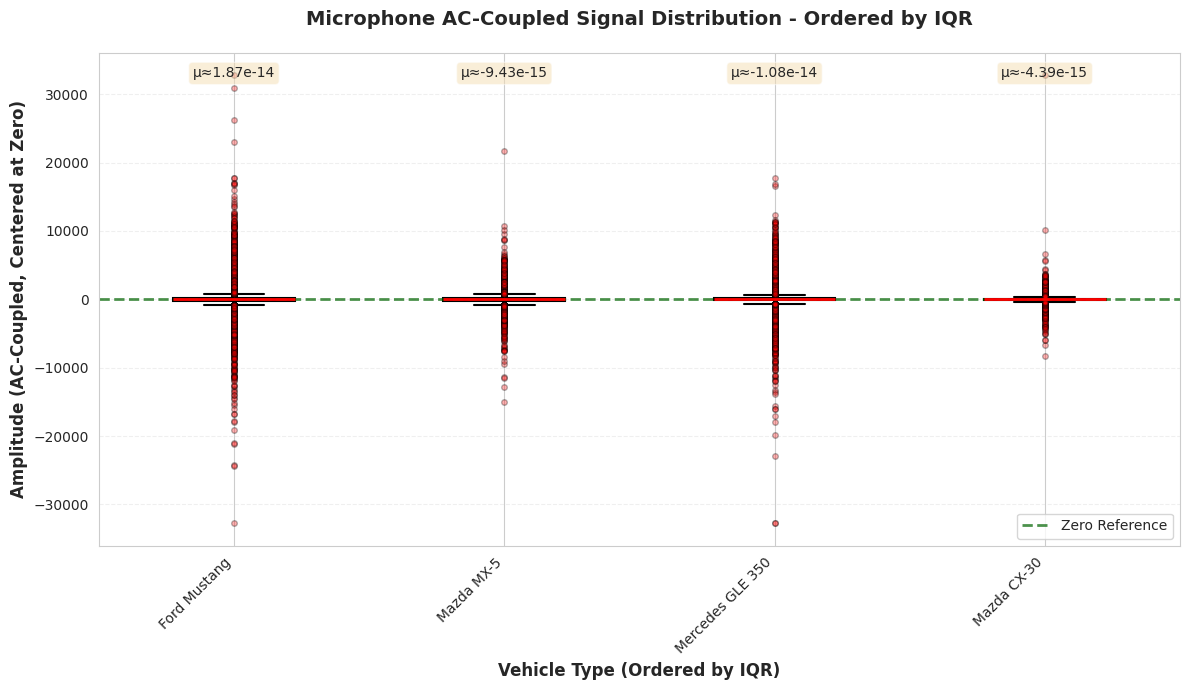

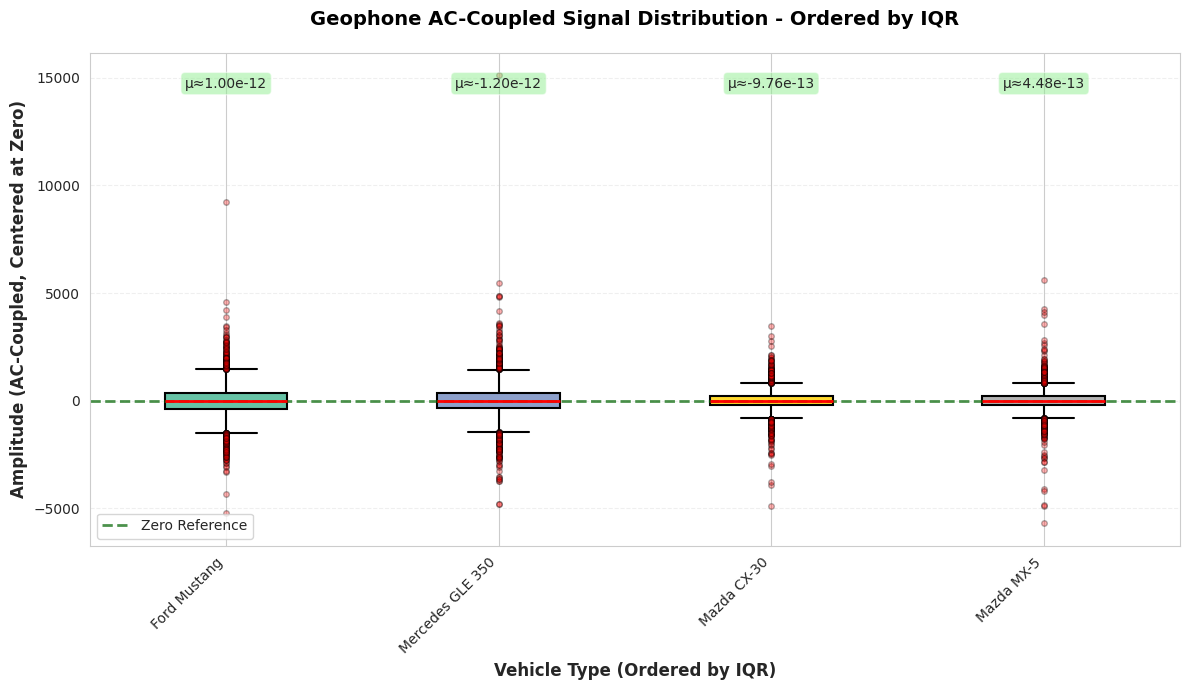


📊 AC-Coupled Signal Distribution Statistics (Ordered by IQR)

Microphone (Ordered by IQR):
  Ford Mustang        : mean=  1.87e-14, median=  3.61e-01, std=  1.23e+03, IQR=    399.00, range=[ -3.28e+04,   3.28e+04], n=39,712
  Mazda MX-5          : mean= -9.43e-15, median=  8.03e-01, std=  5.75e+02, IQR=    394.00, range=[ -1.51e+04,   2.17e+04], n=39,344
  Mercedes GLE 350    : mean= -1.08e-14, median=  3.43e+00, std=  9.37e+02, IQR=    320.00, range=[ -3.28e+04,   1.77e+04], n=39,008
  Mazda CX-30         : mean= -4.39e-15, median=  1.21e+00, std=  3.43e+02, IQR=    198.00, range=[ -8.33e+03,   3.28e+04], n=39,760

Geophone (Ordered by IQR):
  Ford Mustang        : mean=  1.00e-12, median=     -4.07, std=    720.69, IQR=    738.50, range=[  -5211.07,    9237.93], n=4,940
  Mercedes GLE 350    : mean= -1.20e-12, median=      2.80, std=    772.52, IQR=    724.00, range=[  -4785.20,   15109.80], n=4,858
  Mazda CX-30         : mean= -9.76e-13, median=      2.91, std=    437.54, IQR=    

In [193]:
print("Creating AC-Coupled Signal Distribution Box Plots")
print("="*80)

# Define variables for this analysis (excluding background)
scenes = SCENES
vehicle_labels = {k: v for k, v in VEHICLE_LABELS.items() if k != 'background'}
target_vehicles = list(vehicle_labels.keys())

# Collect AC-coupled signal samples for each vehicle
vehicle_signal_distributions_final = {v: {'mic': [], 'geo': []} for v in target_vehicles}

print("\nCollecting signal samples with empty file detection...")
for vehicle in target_vehicles:
    print(f"  Processing {vehicle_labels[vehicle]}...")
    samples_collected = 0
    
    for scene in scenes:
        if samples_collected >= 2:  # Limit to 2 samples per vehicle
            break
            
        try:
            run_path = DATA_ROOT / scene / 'run_ids.parquet'
            if POLARS_AVAILABLE:
                runs = pl.read_parquet(run_path).to_pandas()
            else:
                runs = pd.read_parquet(run_path)
            
            vehicle_runs = runs[runs['label'] == vehicle]
            
            if len(vehicle_runs) == 0:
                continue
            
            for idx, run_row in vehicle_runs.iterrows():
                if samples_collected >= 2:
                    break
                    
                run_id = run_row['run_id']
                data_found = False
                
                for node in range(1, 9):
                    mic_signal = None
                    geo_signal = None
                    
                    # Try to load microphone data
                    try:
                        mic_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_mic.parquet'
                        if POLARS_AVAILABLE:
                            mic_df = pl.read_parquet(mic_path).to_pandas()
                        else:
                            mic_df = pd.read_parquet(mic_path)
                        
                        if len(mic_df) > 0:  # Check file is not empty
                            mic_signal = mic_df['samples'].values if 'samples' in mic_df.columns else mic_df.iloc[:, -1].values
                            if len(mic_signal) == 0:  # Double-check signal array
                                mic_signal = None
                    except:
                        pass
                    
                    # Try to load geophone data
                    try:
                        geo_path = DATA_ROOT / scene / f'run{run_id}_rs{node}_geo.parquet'
                        if POLARS_AVAILABLE:
                            geo_df = pl.read_parquet(geo_path).to_pandas()
                        else:
                            geo_df = pd.read_parquet(geo_path)
                        
                        if len(geo_df) > 0:  # Check file is not empty
                            geo_signal = geo_df['samples'].values if 'samples' in geo_df.columns else geo_df.iloc[:, -1].values
                            if len(geo_signal) == 0:  # Double-check signal array
                                geo_signal = None
                    except:
                        pass
                    
                    # Only add data if BOTH sensors loaded successfully AND have data
                    if mic_signal is not None and geo_signal is not None:
                        # Downsample first (every 100th point to reduce data volume)
                        # AC coupling will be applied to the combined data after collection
                        vehicle_signal_distributions_final[vehicle]['mic'].extend(mic_signal[::100])
                        vehicle_signal_distributions_final[vehicle]['geo'].extend(geo_signal[::100])
                        
                        if not data_found:
                            print(f"    ✓ Found data: {scene}/Run{run_id}/Node{node}")
                            samples_collected += 1
                            data_found = True
                        break
        except:
            continue
    
    if samples_collected == 0:
        print(f"    ⚠️  WARNING: No data found for {vehicle_labels[vehicle]}")

print(f"\n✅ Signal collection complete!")
print("="*80)

# Apply AC coupling to the combined downsampled data
print("\nApplying AC coupling to combined data...")
for vehicle in target_vehicles:
    if len(vehicle_signal_distributions_final[vehicle]['mic']) > 0:
        mic_array = np.array(vehicle_signal_distributions_final[vehicle]['mic'])
        mic_ac = mic_array - np.nanmean(mic_array)
        vehicle_signal_distributions_final[vehicle]['mic'] = mic_ac.tolist()
    
    if len(vehicle_signal_distributions_final[vehicle]['geo']) > 0:
        geo_array = np.array(vehicle_signal_distributions_final[vehicle]['geo'])
        geo_ac = geo_array - np.nanmean(geo_array)
        vehicle_signal_distributions_final[vehicle]['geo'] = geo_ac.tolist()

print("✅ AC coupling applied - all distributions now centered at zero!")
print("="*80)

# Calculate IQR for each vehicle to determine ordering
vehicle_iqrs_mic = {}
vehicle_iqrs_geo = {}

for vehicle in target_vehicles:
    if len(vehicle_signal_distributions_final[vehicle]['mic']) > 0:
        mic_data = np.array(vehicle_signal_distributions_final[vehicle]['mic'])
        mic_iqr = np.nanpercentile(mic_data, 75) - np.nanpercentile(mic_data, 25)
        vehicle_iqrs_mic[vehicle] = mic_iqr
    
    if len(vehicle_signal_distributions_final[vehicle]['geo']) > 0:
        geo_data = np.array(vehicle_signal_distributions_final[vehicle]['geo'])
        geo_iqr = np.nanpercentile(geo_data, 75) - np.nanpercentile(geo_data, 25)
        vehicle_iqrs_geo[vehicle] = geo_iqr

# Sort vehicles by IQR (descending) for each modality
vehicles_sorted_by_mic_iqr = sorted(vehicle_iqrs_mic.keys(), key=lambda v: vehicle_iqrs_mic[v], reverse=True)
vehicles_sorted_by_geo_iqr = sorted(vehicle_iqrs_geo.keys(), key=lambda v: vehicle_iqrs_geo[v], reverse=True)

# Create box plots for microphone signals (ORDERED BY IQR)
fig1, ax1 = plt.subplots(figsize=(12, 7))

mic_data_final = [vehicle_signal_distributions_final[v]['mic'] for v in vehicles_sorted_by_mic_iqr]
vehicle_names_mic = [vehicle_labels[v] for v in vehicles_sorted_by_mic_iqr]

bp1 = ax1.boxplot(mic_data_final, labels=vehicle_names_mic, patch_artist=True,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.3))

# Color boxes
colors_mic = plt.cm.Set3(np.linspace(0, 1, len(vehicle_names_mic)))
for patch, color in zip(bp1['boxes'], colors_mic):
    patch.set_facecolor(color)

ax1.axhline(y=0, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='Zero Reference')
ax1.set_xlabel('Vehicle Type (Ordered by IQR)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Amplitude (AC-Coupled, Centered at Zero)', fontsize=12, fontweight='bold')
ax1.set_title('Microphone AC-Coupled Signal Distribution - Ordered by IQR', 
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.legend()
plt.xticks(rotation=45, ha='right')

# Add statistics text
for i, vehicle in enumerate(vehicles_sorted_by_mic_iqr):
    data = mic_data_final[i]
    if len(data) > 0:
        mean_val = np.mean(data)
        ax1.text(i+1, ax1.get_ylim()[1]*0.9, f'μ≈{mean_val:.2e}', 
                 ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Create box plots for geophone signals (ORDERED BY IQR)
fig2, ax2 = plt.subplots(figsize=(12, 7))

geo_data_final = [vehicle_signal_distributions_final[v]['geo'] for v in vehicles_sorted_by_geo_iqr]
vehicle_names_geo = [vehicle_labels[v] for v in vehicles_sorted_by_geo_iqr]

bp2 = ax2.boxplot(geo_data_final, labels=vehicle_names_geo, patch_artist=True,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(facecolor='lightgreen', edgecolor='black', linewidth=1.5),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.3))

# Color boxes
colors_geo = plt.cm.Set2(np.linspace(0, 1, len(vehicle_names_geo)))
for patch, color in zip(bp2['boxes'], colors_geo):
    patch.set_facecolor(color)

ax2.axhline(y=0, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7, label='Zero Reference')
ax2.set_xlabel('Vehicle Type (Ordered by IQR)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Amplitude (AC-Coupled, Centered at Zero)', fontsize=12, fontweight='bold')
ax2.set_title('Geophone AC-Coupled Signal Distribution - Ordered by IQR', 
              fontsize=14, fontweight='bold', pad=20, color='black')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend()
plt.xticks(rotation=45, ha='right')

# Add statistics text
for i, vehicle in enumerate(vehicles_sorted_by_geo_iqr):
    data = geo_data_final[i]
    if len(data) > 0:
        mean_val = np.mean(data)
        ax2.text(i+1, ax2.get_ylim()[1]*0.9, f'μ≈{mean_val:.2e}', 
                 ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary statistics (ORDERED BY IQR)
print("\n📊 AC-Coupled Signal Distribution Statistics (Ordered by IQR)")
print("="*80)
print("\nMicrophone (Ordered by IQR):")
for vehicle in vehicles_sorted_by_mic_iqr:
    data = vehicle_signal_distributions_final[vehicle]['mic']
    if len(data) > 0:
        print(f"  {vehicle_labels[vehicle]:<20}: "
              f"mean={np.mean(data):>10.2e}, "
              f"median={np.median(data):>10.2e}, "
              f"std={np.std(data):>10.2e}, "
              f"IQR={vehicle_iqrs_mic[vehicle]:>10.2f}, "
              f"range=[{np.min(data):>10.2e}, {np.max(data):>10.2e}], "
              f"n={len(data):,}")
    else:
        print(f"  {vehicle_labels[vehicle]:<20}: No data collected")

print("\nGeophone (Ordered by IQR):")
for vehicle in vehicles_sorted_by_geo_iqr:
    data = vehicle_signal_distributions_final[vehicle]['geo']
    if len(data) > 0:
        print(f"  {vehicle_labels[vehicle]:<20}: "
              f"mean={np.mean(data):>10.2e}, "
              f"median={np.median(data):>10.2f}, "
              f"std={np.std(data):>10.2f}, "
              f"IQR={vehicle_iqrs_geo[vehicle]:>10.2f}, "
              f"range=[{np.min(data):>10.2f}, {np.max(data):>10.2f}], "
              f"n={len(data):,}")
    else:
        print(f"  {vehicle_labels[vehicle]:<20}: No data collected")

print("\n" + "="*80)
print("✅ KEY OBSERVATIONS:")
print("  • All distributions are centered at zero (mean ≈ 0)")
print("  • Vehicles ordered by IQR (Interquartile Range) - largest spread first")
print("  • Box widths show signal variability (vibration amplitude)")
print("  • Different vehicles have different spread patterns")
print("  • Heavier vehicles typically show larger amplitude ranges")
print("="*80)

## 9. Key Findings and Summary

In [194]:
print("="*80)
print("M3N-VC DATASET: COMPREHENSIVE EXPLORATION SUMMARY")
print("="*80)

print("\n📊 DATASET SCALE:")
print(f"  • Total Recordings: {len(all_runs_df)} runs across {all_runs_df['scene'].nunique()} scenes")
print(f"  • Total Duration: {all_runs_df['duration_minutes'].sum()/60:.2f} hours")
print(f"  • Vehicles: {all_runs_df['label'].nunique()} types ({', '.join([VEHICLE_LABELS.get(v, v) for v in sorted(all_runs_df['label'].unique())])})")
print(f"  • Train/Test: {(all_runs_df['set'] == 'train').sum()}/{(all_runs_df['set'] == 'test').sum()} runs")

print("\n🌍 ENVIRONMENTAL DIVERSITY:")
print(f"  • Terrain Types: {summary_df['terrain'].nunique()} ({', '.join(summary_df['terrain'].unique())})")
print(f"  • Weather Conditions: {summary_df['weather'].nunique()} ({', '.join(summary_df['weather'].unique())})")
print(f"  • Total Sensor Nodes: {summary_df['nodes'].sum()}")

print("\n🚗 VEHICLE COVERAGE:")
for vehicle in sorted([v for v in all_runs_df['label'].unique() if v != 'background']):
    count = (all_runs_df['label'] == vehicle).sum()
    print(f"  • {VEHICLE_LABELS.get(vehicle, vehicle)}: {count} runs")

print("\n📡 SENSOR MODALITIES:")
print("  • Microphone: 16 kHz (acoustic signals)")
print("  • Geophone: 200 Hz (ground vibrations)")
print("  • GPS: 1 Hz (vehicle trajectories)")

print("\n✅ DATA QUALITY:")
print(f"  • Missing Metadata: {all_runs_df.isnull().sum().sum()} fields")
print(f"  • Duplicate Runs: {all_runs_df.duplicated(subset=['scene', 'run_id']).sum()}")
# Calculate vehicle balance (coefficient of variation)
vehicle_balance = all_runs_df['label'].value_counts()
print(f"  • Dataset Balance: CV = {vehicle_balance[vehicle_balance.index != 'background'].std()/vehicle_balance[vehicle_balance.index != 'background'].mean()*100:.1f}%")

print("\n🎯 KEY FINDINGS:")
print("  1. Balanced multi-vehicle dataset with 4 vehicle types + background")
print("  2. Diverse environmental conditions (6 scenes, 3 terrains, 3 weather types)")
print("  3. Multi-node sensor network enables spatial analysis")
print("  4. Pre-defined train/test splits for reproducible experiments")
print("  5. Multi-modal recordings (audio, seismic, GPS) for sensor fusion")

print("\n" + "="*80)
print("✓ Comprehensive exploration complete!")
print("="*80)

M3N-VC DATASET: COMPREHENSIVE EXPLORATION SUMMARY

📊 DATASET SCALE:
  • Total Recordings: 48 runs across 6 scenes
  • Total Duration: 18.85 hours
  • Vehicles: 5 types (Background, Mazda CX-30, Mercedes GLE 350, Mazda MX-5, Ford Mustang)
  • Train/Test: 24/24 runs

🌍 ENVIRONMENTAL DIVERSITY:
  • Terrain Types: 4 (Asphalt, Asphalt & gravel, Concrete, Dirt & gravel)
  • Weather Conditions: 3 (Sunny, Rainy, Windy)
  • Total Sensor Nodes: 40

🚗 VEHICLE COVERAGE:
  • Mazda CX-30: 14 runs
  • Mercedes GLE 350: 10 runs
  • Mazda MX-5: 12 runs
  • Ford Mustang: 10 runs

📡 SENSOR MODALITIES:
  • Microphone: 16 kHz (acoustic signals)
  • Geophone: 200 Hz (ground vibrations)
  • GPS: 1 Hz (vehicle trajectories)

✅ DATA QUALITY:
  • Missing Metadata: 0 fields
  • Duplicate Runs: 0
  • Dataset Balance: CV = 16.7%

🎯 KEY FINDINGS:
  1. Balanced multi-vehicle dataset with 4 vehicle types + background
  2. Diverse environmental conditions (6 scenes, 3 terrains, 3 weather types)
  3. Multi-node sensor 

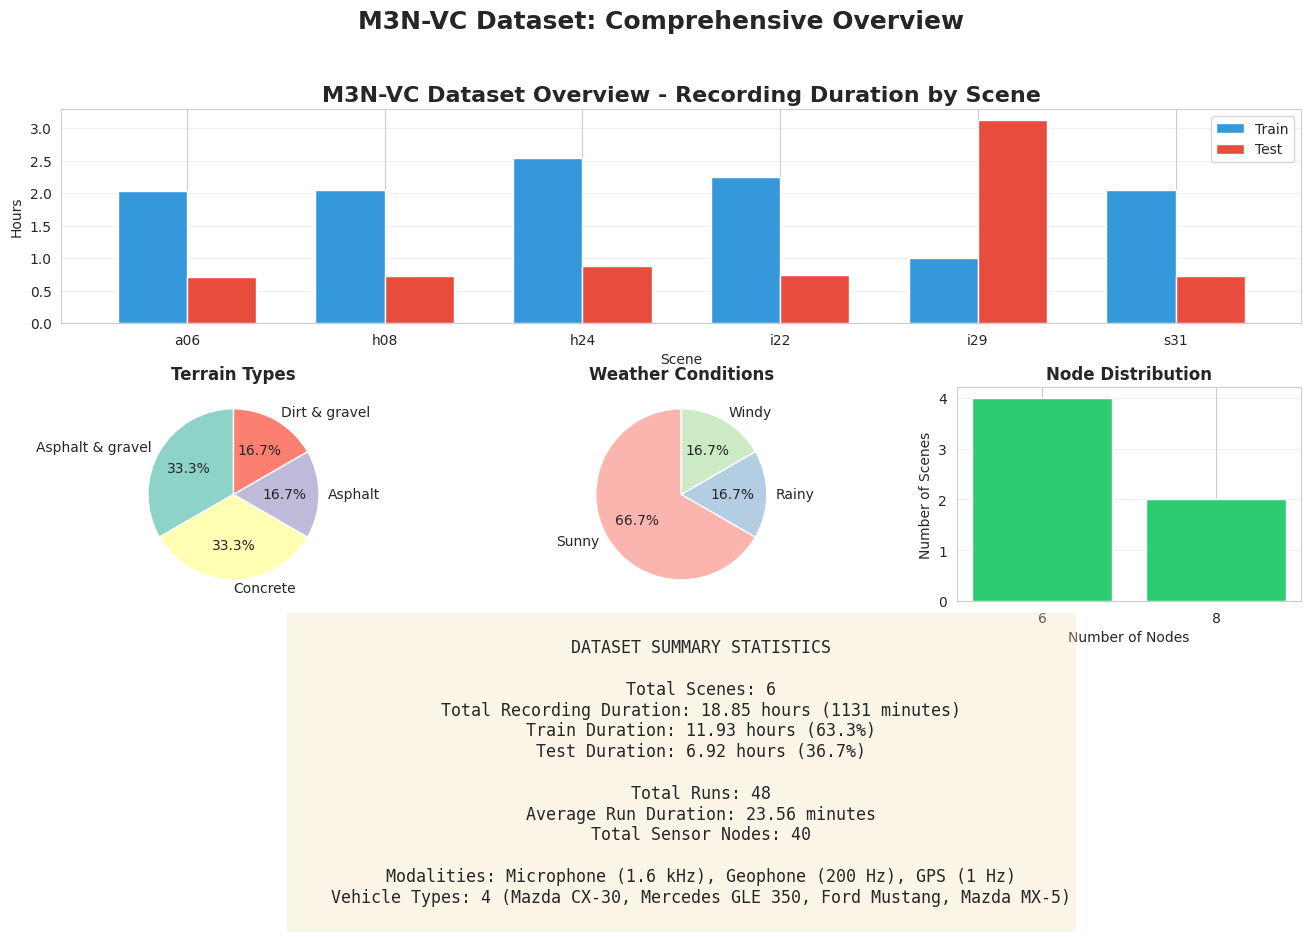


Data Exploration Complete!


In [195]:
# Create a comprehensive summary visualization
if 'summary_df' in locals():
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Scene overview
    ax1 = fig.add_subplot(gs[0, :])
    x = np.arange(len(summary_df))
    width = 0.35
    ax1.bar(x - width/2, summary_df['train_hours'], width, label='Train', color='#3498db')
    ax1.bar(x + width/2, summary_df['test_hours'], width, label='Test', color='#e74c3c')
    ax1.set_xlabel('Scene')
    ax1.set_ylabel('Hours')
    ax1.set_title('M3N-VC Dataset Overview - Recording Duration by Scene', fontsize=16, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(summary_df['scene'])
    ax1.legend()
    ax1.grid(alpha=0.3, axis='y')
    
    # Terrain types
    ax2 = fig.add_subplot(gs[1, 0])
    terrain_counts = summary_df['terrain'].value_counts()
    colors = plt.cm.Set3(range(len(terrain_counts)))
    ax2.pie(terrain_counts.values, labels=terrain_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
    ax2.set_title('Terrain Types', fontweight='bold')
    
    # Weather conditions
    ax3 = fig.add_subplot(gs[1, 1])
    weather_counts = summary_df['weather'].value_counts()
    colors = plt.cm.Pastel1(range(len(weather_counts)))
    ax3.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax3.set_title('Weather Conditions', fontweight='bold')
    
    # Node distribution
    ax4 = fig.add_subplot(gs[1, 2])
    node_counts = summary_df['nodes'].value_counts().sort_index()
    ax4.bar(node_counts.index.astype(str), node_counts.values, color='#2ecc71')
    ax4.set_xlabel('Number of Nodes')
    ax4.set_ylabel('Number of Scenes')
    ax4.set_title('Node Distribution', fontweight='bold')
    ax4.grid(alpha=0.3, axis='y')
    
    # Summary statistics
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    total_hours = summary_df['total_hours'].sum()
    train_hours = summary_df['train_hours'].sum()
    test_hours = summary_df['test_hours'].sum()
    total_runs = summary_df['runs'].sum()
    avg_run_duration = (total_hours * 60) / total_runs if total_runs > 0 else 0
    
    summary_text = f"""
    DATASET SUMMARY STATISTICS
    
    Total Scenes: {len(summary_df)}
    Total Recording Duration: {total_hours:.2f} hours ({total_hours*60:.0f} minutes)
    Train Duration: {train_hours:.2f} hours ({(train_hours/total_hours)*100:.1f}%)
    Test Duration: {test_hours:.2f} hours ({(test_hours/total_hours)*100:.1f}%)
    
    Total Runs: {total_runs}
    Average Run Duration: {avg_run_duration:.2f} minutes
    Total Sensor Nodes: {summary_df['nodes'].sum()}
    
    Modalities: Microphone (1.6 kHz), Geophone (200 Hz), GPS (1 Hz)
    Vehicle Types: 4 (Mazda CX-30, Mercedes GLE 350, Ford Mustang, Mazda MX-5)
    """
    
    ax5.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=12,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
             family='monospace')
    
    plt.suptitle('M3N-VC Dataset: Comprehensive Overview', fontsize=18, fontweight='bold', y=0.98)
    plt.show()

print("\n" + "="*80)
print("Data Exploration Complete!")
print("="*80)

### Dataset Characteristics

**M3N-VC Dataset Summary:**

#### 1. **Multi-Scene Coverage**
- 6 unique outdoor environments with varying terrain types
- Diverse weather conditions: Sunny, Rainy, and Windy
- Different road surfaces: Asphalt, Concrete, Dirt & Gravel

#### 2. **Multi-Modal Sensing**
- **Microphone**: 16 kHz sampling rate for acoustic signals
- **Geophone**: 200 Hz sampling rate for ground vibrations
- **GPS**: 1 Hz for vehicle trajectory tracking
- Multiple spatially distributed sensor nodes (6-8 per scene)

#### 3. **Vehicle Classification**
- 4 different vehicle types:
  - Mazda CX-30 (cx30)
  - Mercedes-Benz GLE 350 (gle350)
  - Ford Mustang (mustang)
  - Mazda MX-5 (miata)

#### 4. **Data Organization**
- Total duration: ~18 hours of synchronized recordings
- Train/Test split provided for each scene
- Time-synchronized sensor nodes using GPS
- Parquet format for efficient storage and access

#### 5. **Applications**
- Vehicle classification in distributed sensor networks
- Multi-modal signal fusion
- Domain adaptation across different environments
- IoT foundation model training
- Test-time adaptation research

---

### Next Steps

This exploration provides a foundation for:
1. **Feature Engineering**: Extract relevant features from time-series data
2. **Model Development**: Build classification models using multi-modal inputs
3. **Cross-Scene Analysis**: Study domain shift across different environments
4. **Signal Processing**: Apply advanced techniques (spectrograms, wavelets, etc.)
5. **Multi-Node Fusion**: Combine information from multiple sensor nodes